# Imports

In [33]:
from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.timeseries import TimeSeries 
from sunpy.timeseries import GenericTimeSeries
from sunpy.time import parse_time
from sunpy.data import cache
from sunpy.coordinates import spice, frames
from sunpy.coordinates import get_horizons_coord, get_body_heliographic_stonyhurst

from astropy import units as u
from astropy.time import Time

import matplotlib.pyplot as plt
import numpy as np 

import os
import urllib.request

import pandas as pd
import datetime as dt

from scipy.stats import norm
import seaborn as sns

import polars as pl

from kneed import KneeLocator, DataGenerator
from kneed import find_shape
from scipy import stats

# uncomment line below to see what datasets are available to query from the CDAWeb
# a.cdaweb.Dataset('OMNI_HRO2_1MIN')#wi_k0_swe # WI_K0_SWE https://cdaweb.gsfc.nasa.gov/misc/NotesW.html#WI_K0_SWE

In [34]:
import warnings
warnings.filterwarnings("ignore")

In [35]:
DataDirectory = "Data/windData/"
dataName = "wind_min_b"
PlotDirectory = "Plots/WindYearlyPlots/"

# Functions

In [36]:
#Find DateRanges for each file needed found
def ReadDates(startDate, endDate): #ReadDatesForFileFinding
    DateRange = pd.date_range(startDate, endDate, freq='MS').strftime("%Y%m%d").tolist()
    return DateRange

# Get to date portion of the file names
def myFunc(e):
  return e.split("b")[1]

# Get the pre-downloaded data from folder
def FindData(directory, dataName, startDate, endDate): #FindDataMakeTimeSeries
    files = []
    for file in os.listdir(directory):
        filename = os.fsdecode(file)
        DateRange = ReadDates(startDate, endDate)
        for j in range(len(DateRange)):
            if filename.startswith(dataName + str(DateRange[j])[0:6]):
                files.append(directory+filename)
                continue
    filesSorted = sorted(files, key=myFunc) # sort files
    df_list = [] #pd.DataFrame([])
    # Columns from https://omniweb.gsfc.nasa.gov/html/HROdocum.html
    colnames = ["Year", "DOY", "Hour", "Minute", "IMF_PTS", "PercentInterp", "CP/MVFlag", "Timeshift", "PFN_XGSE", "PFN_YGSE","PFN_ZGSE", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE", "ByGSM", "BzGSM", "RMSTimeshift", "RMS_PFN", "RMSScalarB", "RMSFieldVector", "Plasma_PTS", "FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE", "ProtonDensity", "Temp", "X_s_c_GSE", "Y_s_c_GSE", "Z_s_c_GSE", "X_targ_GSE", "Y_targ_GSE", "Z_targ_GSE", "RMS_targ", "DBOT1", "DBOT2"]
    for j in range(len(filesSorted)):
        df_list.append( pd.read_csv(filesSorted[j], header=None, sep = "\s+", names = colnames) )
    dataTimeSeries = pd.concat(df_list, ignore_index=True)

    # replace with nans
    WindFillerVals = [999, 9.9, 999999, 99.99, 9999.99, 99999.9, 999.99, 9999999] #https://omniweb.gsfc.nasa.gov/html/HROdocum.html#4b
    dataTimeSeriesFillersToNans = dataTimeSeries.replace(WindFillerVals, np.nan)

    return dataTimeSeriesFillersToNans

def dfToSeries(DataFrame):
    DataFrame.insert(0, "DateTime", pd.to_datetime(DataFrame['Year'] * 10000000 + DataFrame['DOY']*10000 + DataFrame['Hour']*100 + DataFrame['Minute'], format='%Y%j%H%M'))
    DataFrameDateTimeIndex = DataFrame.set_index('DateTime') 

    # colnames = ["Year", "DOY", "Hour", "Minute", "IMF_PTS", "PercentInterp", "CP/MVFlag", "Timeshift", "PFN_XGSE", "PFN_YGSE","PFN_ZGSE", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE", "ByGSM", "BzGSM", "RMSTimeshift", "RMS_PFN", "RMSScalarB", "RMSFieldVector", "Plasma_PTS", "FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE", "ProtonDensity", "Temp", "X_s_c_GSE", "Y_s_c_GSE", "Z_s_c_GSE", "X_targ_GSE", "Y_targ_GSE", "Z_targ_GSE", "RMS_targ", "DBOT1", "DBOT2"]
    SunpyTimeSeries =  GenericTimeSeries(DataFrameDateTimeIndex)
    # print(SunpyTimeSeries)
    return SunpyTimeSeries

# # Get the pre-downloaded data from folder - Started to try and make the code easy to switch between wind/omni but later code will face issues as colnames are different so left for now
# def FindData(DataName, startDate, endDate): #FindDataMakeTimeSeries
#     if DataName == "Wind":
#         directory = "Data/windData/"
#         dataName = "wind_min_b" # b = shifted to bow shock nose (by technique 4)
#         files = []
#         for file in os.listdir(directory):
#             filename = os.fsdecode(file)
#             DateRange = ReadDates(startDate, endDate)
#             for j in range(len(DateRange)):
#                 if filename.startswith(dataName + str(DateRange[j])[0:6]):
#                     files.append(directory+filename)
#                     continue
#         filesSorted = sorted(files, key=myFunc) # sort files
#         df_list = [] #pd.DataFrame([])
#         # Columns from https://omniweb.gsfc.nasa.gov/html/HROdocum.html
#         colnames = ["Year", "DOY", "Hour", "Minute", "IMF_PTS", "PercentInterp", "CP/MVFlag", "Timeshift", "PFN_XGSE", "PFN_YGSE","PFN_ZGSE", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE", "ByGSM", "BzGSM", "RMSTimeshift", "RMS_PFN", "RMSScalarB", "RMSFieldVector", "Plasma_PTS", "FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE", "ProtonDensity", "Temp", "X_s_c_GSE", "Y_s_c_GSE", "Z_s_c_GSE", "X_targ_GSE", "Y_targ_GSE", "Z_targ_GSE", "RMS_targ", "DBOT1", "DBOT2"]
#         for j in range(len(filesSorted)):
#             df_list.append( pd.read_csv(filesSorted[j], header=None, sep = "\s+", names = colnames) )
#         dataTimeSeries = pd.concat(df_list, ignore_index=True)

#         # replace with nans
#         WindFillerVals = [999, 9.9, 999999, 99.99, 9999.99, 99999.9, 999.99, 9999999] #https://omniweb.gsfc.nasa.gov/html/HROdocum.html#4b
#         dataTimeSeriesFillersToNans = dataTimeSeries.replace(WindFillerVals, np.nan)
#     elif DataName == "Omni":
#         directory = "./Data/omniData/"
#         dataName = "omni_hro2_1min_"
#         files = []
#         for file in os.listdir(directory):
#             filename = os.fsdecode(file)
#             DateRange = ReadDates(startDate, endDate)
#             for j in range(len(DateRange)):
#                 if filename.startswith(dataName + str(DateRange[j])):
#                     files.append(directory+filename)
#                     continue
#         filesSorted = sorted(files, key=myFunc) # sort files
#         dataTimeSeries = TimeSeries(filesSorted, concatenate=True)

#         # replace with nans
#         OmniFillerVals = [99, 999, 999999, 99.99, 9999.99, 99999.9, 999.99, 999.9, 99999, 9.999, 99.9, 99999.99] #https://omniweb.gsfc.nasa.gov/html/HROdocum.html#4b
#         dataTimeSeriesFillersToNans = dataTimeSeries.replace(OmniFillerVals, np.nan)
#     else: 
#         print("Named data not available.")

#     return dataTimeSeriesFillersToNans

# Calculate Total Vsw
def AddTotVsw(dataTimeSeries):
    TotVsw = np.sqrt(dataTimeSeries._data["Vx_GSE"]**2 + 
                     dataTimeSeries._data["Vy_GSE"]**2 + 
                     dataTimeSeries._data["Vz_GSE"]**2)
    dataTimeSeries = dataTimeSeries.add_column("TotVsw", TotVsw)
    return dataTimeSeries

#Plot Vsw
def PlotVsw(dataTimeSeries):
    # dataTimeSeries[cols] = dataTimeSeries[dataTimeSeries[cols] > filter][cols]
    fig, ax = plt.subplots()
    dataTimeSeries.plot(columns=["TotVsw", "Vx_GSE", "Vy_GSE", "Vz_GSE"], alpha = 0.5)
    plt.legend(loc="upper right")
    # plt.ylim(-450,900)
    # print(dataTSFirstDates._data[""].unique())

# Combine the components of magnetic field from data to get magnitude of magnetic field, BMag
def AddBMag(dataTimeSeries):
    BMag = np.sqrt(dataTimeSeries._data["Bx_GSEGSM"]**2 + 
                   dataTimeSeries._data["ByGSE"]**2 + 
                   dataTimeSeries._data["BzGSE"]**2)
    dataTimeSeries = dataTimeSeries.add_column("BMag", BMag)
    return dataTimeSeries

# Combine the components of magnetic field from data to get magnitude of magnetic field, BMag
def AddLogBMag(dataTimeSeries):
    LogB = np.log(dataTimeSeries._data["BMag"])
    dataTimeSeries = dataTimeSeries.add_column("LogB", LogB)
    return dataTimeSeries

# Combine the components of magnetic field from data to get magnitude of magnetic field, BMag
def AddLogBX(dataTimeSeries):
    LogBX = np.log(dataTimeSeries._data["Bx_GSEGSM"])
    dataTimeSeries = dataTimeSeries.add_column("LogBX", LogBX)
    return dataTimeSeries

#Plot B
def PlotB(dataTimeSeries):
    fig, ax = plt.subplots()
    dataTimeSeries.plot(columns=["BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"], alpha = 0.5)
    plt.legend(loc="upper right")
    # plt.ylim(-40,90)
    # print(dataTSFirstDates._data[""].unique())

# Dotted plots
def PlotVswDotted(dataTimeSeries):
    fig, ax  = plt.subplots(4, sharex=True, figsize=(10, 10))
    # total Wind speed
    dataTimeSeries._data["TotVsw"].plot(ax=ax[0], marker='.', ls='', ms=1)
    ax[0].set_ylabel("Tot V$_{SW}$ (km/s)")
    # # flow speed
    # dataTimeSeries._data["FlowSpeed"].plot(ax=ax[1], marker='.', ls='', ms=1)
    # ax[1].set_ylabel("Flow speed (km/s)")
    # components of Wind speed, Vx
    dataTimeSeries._data["Vx_GSE"].plot(ax=ax[1], marker='.', ls='', ms=1) # this is getting negative results, which makes sense if V_GSM_0 is the X GSM axis (towards the Sun) since the SW will be flowing in the opposite direction.
    ax[1].set_ylabel("Vx V$_{SW}$ (km/s)")
    # components of Wind speed, Vy
    dataTimeSeries._data["Vy_GSE"].plot(ax=ax[2], marker='.', ls='', ms=1) # this is likely Y then (essentially along the west->east line of the (center of the) Earth).
    ax[2].set_ylabel("Vy V$_{SW}$ (km/s)")
    # components of Wind speed, Vz
    dataTimeSeries._data["Vz_GSE"].plot(ax=ax[3], marker='.', ls='', ms=1) # and this is likely Z then (essentially along the south->north line of the (center of the) Earth).  I guess you'd expect these components to be lower than the radial one as the solar OMNI is mostly radial/along the Parker spiral
    ax[3].set_ylabel("Vz V$_{SW}$ (km/s)")

    for aa in ax:
        aa.legend(loc="upper left")
        # aa.axvline("2022-01-29 00:00", color='k')
        # aa.axvline("2022-01-30 02:00", color='k', ls="dashed")
        # aa.set_ylim(-400,400)

    # ax[4].set_xlabel("Time")
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.02)

# Plot histograms all together
def PlotHistTogether(dataTimeSerieses, VarsToPlot):
    for i in range(len(VarsToPlot)):
        maxY = 0
        for j in range(len(dataTimeSerieses)):
            plt.hist(dataTimeSerieses[j]._data[VarsToPlot[i]], bins = Bin, label = "Wind " + str(StartAndEnd[j][0] + " - " + str(StartAndEnd[j][1])), alpha = Alpha, density = True)

            y, x, _ = plt.hist(dataTimeSerieses[j]._data[VarsToPlot[i]], bins = Bin, label = "Wind " + str(StartAndEnd[j][0][0:10] + " - " + str(StartAndEnd[j][1][0:10])), alpha = Alpha, density = True)
            maxVarY = y.max()
            if maxVarY > maxY:
                maxY = maxVarY
            # print(maxVarY, maxY)

        plt.title("Solar Wind " + VarsToPlot[i])
        plt.xlabel(VarsToPlot[i] + r", GSE, $km/s$")
        plt.ylabel("Normalised frequency")
        plt.legend(fontsize=Legend)
        # plt.ylim(0, maxY)
        plt.ylim(0, maxY+ 0.1*maxY)
        plt.show()

#Plot histograms separately
def PlotHistSeparate(dataTimeSerieses, VarsToPlot, XAxisScale, YAxisScale, FigSize):
    for i in range(len(VarsToPlot)): # For each variable
        # LowerBounds = [] # set lower bounds array to 0
        # UpperBounds = [] # set upper bounds array to 0
        fig, axs = plt.subplots(len(dataTimeSerieses),1, figsize=FigSize, sharex=True)
        fig.subplots_adjust(hspace=0)
        plt.suptitle("Solar Wind "+ VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=0.89)
        fig.supxlabel(VarsToPlot[i] + ", " + Units[i], y=0.099)

        maxY = 0
        for j in range(len(dataTimeSerieses)): # For each daterange
            # axs[j].hist(dataTimeSerieses[j]._data[VarsToPlot[i]], bins = Bin, label = "Wind " + str(StartAndEnd[j][0]) + " - " + str(StartAndEnd[j][1]), color=Colours[j], alpha = Alpha, density = True)

            y, x, _ = axs[j].hist(dataTimeSerieses[j]._data[VarsToPlot[i]], bins = Bin, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True)
            maxVarY = y.max()
            if maxVarY > maxY:
                maxY = maxVarY
            # print(maxVarY, maxY)


            #Mean
            axs[j].axvline(dataTimeSerieses[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "grey", label="mean = " + str(dataTimeSerieses[j]._data[VarsToPlot[i]].mean()))
            #Median
            axs[j].axvline(dataTimeSerieses[j]._data[VarsToPlot[i]].median(), linestyle = '--', color = "black", label="median = " + str(dataTimeSerieses[j]._data[VarsToPlot[i]].median()))
            #Standard deviation
            axs[j].axvline(dataTimeSerieses[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(dataTimeSerieses[j]._data[VarsToPlot[i]].std()), alpha = 0)

            axs[j].legend(loc = LegLoc, fontsize = Legend)
                # axs[1].legend(loc = LegLoc, fontsize = Legend)
                # axs[2].legend(loc = LegLoc, fontsize = Legend)
                # axs[3].legend(loc = LegLoc, fontsize = Legend)
            
            # LowerBounds.append(min(dataTimeSerieses[j]._data[VarsToPlot[i]].values))
            # UpperBounds.append(max(dataTimeSerieses[j]._data[VarsToPlot[i]].values))
            # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
            # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
            # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
            # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
            # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
            # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
            axs[j].set_ylabel("Normalised frequency")
        

        # plt.xlim(min(LowerBounds) - SpaceLR[i], max(UpperBounds) + SpaceLR[i])
        # plt.xlim(np.nanmin(LowerBounds) - SpaceLR[i], np.nanmax(UpperBounds) + SpaceLR[i])

        plt.xscale(XAxisScale[i])
        

        # for m in range(len(dataTimeSerieses)):
        #     if maxY == np.nan or maxY == np.inf:
        #             print("Max is nan or inf.")
            # else:
        for m in range(len(dataTimeSerieses)):
            # axs[m].set_ylim(0, maxY)
            axs[m].set_ylim(0, maxY+ 0.1*maxY)
        # plt.tight_layout()
        plt.yscale(YAxisScale[i])
        
        plt.savefig(PlotDirectory + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + "_Wind.png")
        # plt.show()

# Plot CDF
def PlotCDF(dataTimeSerieses, VarsToPlot):
    # fig, axs = plt.subplots()#4,1, figsize=FigSize, sharex=True)
    # fig.subplots_adjust(hspace=0)
    for i in range(len(VarsToPlot)):
        for j in range(len(dataTimeSerieses)):
            sns.ecdfplot(dataTimeSerieses[j]._data[VarsToPlot[i]], label="Wind " + str(StartAndEnd[j][0]) + " - " + str(StartAndEnd[j][1]), color=Colours[j])
        plt.xlabel(VarsToPlot[i] + ", " + Units[i])
        plt.ylabel('Cumulative probability')
        plt.ylim(yLim)
        plt.legend(fontsize=Legend)
        plt.grid(True)
        plt.savefig(PlotDirectory + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + "_CDF_Wind.png") #  + dataTimeSerieses[0] + " - " + dataTimeSerieses[-1] 
        plt.show()

## Plot DQQs
# Calculate quantiles
def get_quantiles(
    x: pl.Series,
    y: pl.Series,
    size: int = 500, # 500 data points to calculate (default)
    p_range: Tuple[float, float] = (0.0001, 0.9999),) -> Tuple[NDArray, NDArray]: # p_range default set to values used in Tindale and Chapman 2017 to recreate their plots

    x_sorted = np.sort(x.drop_nulls().drop_nans().to_numpy()) # Sort data
    y_sorted = np.sort(y.drop_nulls().drop_nans().to_numpy()) # Sort data

    probabilities = np.linspace(*p_range, size) # make linspace of probabilities in range

    x_quantiles = np.quantile(x_sorted, probabilities) # calculate the quantiles
    y_quantiles = np.quantile(y_sorted, probabilities) # calculate the quantiles

    return x_quantiles, y_quantiles

## Simple FindKnee function without breakpoint finding
# def FindKnee(x, y):
#     direction, curve = find_shape(x, y)
#     kl = KneeLocator(x, y, curve=curve, direction=direction)
#     xOfKnee = kl.knee
#     yOfKnee = kl.knee_y
#     return xOfKnee, yOfKnee

# FindKnee function with breakpoint finding
def FindQuantOfKnee(x, y):
    direction, curve = find_shape(x, y)
    xlen = len(x)
    ylen = len(y)
    print(xlen, ylen)
    # kl = KneeLocator(x[int(xlen/2):-1], y[int(ylen/2):-1], curve=curve, direction=direction)
    kl = KneeLocator(x, y, curve=curve, direction=direction)
    xOfKnee = kl.knee
    yOfKnee = kl.knee_y
    print(xOfKnee, yOfKnee)
    
    XRes = stats.ecdf(x)#(xOfKnee)
    YRes = stats.ecdf(y)
    # print(Strawb.cdf.quantiles[4000])
    FindXidx = np.where(XRes.cdf.quantiles == xOfKnee)
    FindYidx = np.where(YRes.cdf.quantiles == yOfKnee)
    print(FindXidx, FindYidx)

    FindXidx = FindXidx[0][0]
    FindYidx = FindYidx[0][0]

    if FindXidx == FindYidx:
        ProbValue = XRes.cdf.probabilities[FindXidx]
        print(XRes.cdf.probabilities[FindXidx])
        print(YRes.cdf.probabilities[FindYidx])

    else:
        print("Indexes don't match")
        print(FindXidx, FindYidx)
        print(XRes.cdf.quantiles[FindXidx])
        print(YRes.cdf.quantiles[FindYidx])
        print("XRes -1")
        print(XRes.cdf.quantiles[FindXidx-1])
        print("YRes -1")
        print(YRes.cdf.quantiles[FindYidx-1])
        # ProbValue = XRes.cdf.probabilities[FindXidx]
        # ProbValue = YRes.cdf.probabilities[FindYidx]
        ProbValue = np.nan

    quantOfKnee = ProbValue
    return xOfKnee, yOfKnee, quantOfKnee

#Plot DQQ graphs with qs
def PlotDQQ(dataTimeSeriesToCompare, VarsToPlot, QuantilesSpecific):
    for i in range(len(VarsToPlot)): # do each parameter
        fig, ax  = plt.subplots(figsize=(5, 5))
        for j in range(len(dataTimeSeriesToCompare)): # do each comparison
            dataTimeSeriesPS1 = pl.Series(dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]])
            dataTimeSeriesPS2 = pl.Series(dataTimeSeriesToCompare[j][1]._data[VarsToPlot[i]])
            xQuant, yQuant = get_quantiles(dataTimeSeriesPS1, dataTimeSeriesPS2, size = 5000, p_range=(0.0001, 0.9999))
            plt.scatter(xQuant, yQuant, color=Color[j], s=2, label = PlotLabels[j])

            xOfKnee, yOfKnee, quantOfKnee = FindQuantOfKnee(xQuant, yQuant)

            if np.isnan(quantOfKnee):
                print("---------------------------")
                print("Error finding breakpoints q")
                print("---------------------------")
            else:
                plt.plot(xOfKnee, yOfKnee, "o", color="black", label = "q = " + str(quantOfKnee))
            # plt.plot(xOfKnee, yOfKnee, "o", color="black")
        
        x = np.linspace(-100, 900, 2)
        y = x
        plt.plot(x, y, color="grey")
        plt.title("T&C 2017 Fig 4aiii)")
        plt.legend(loc="lower right", fontsize = Legend)
        plt.xlabel(VarsToPlot[i] + r", $km/s$, solar min.")
        plt.ylabel(VarsToPlot[i] + r", $km/s$, solar max.")
        plt.xlim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2) , max(xQuantC23)+np.absolute(max(xQuantC23)/2))
        plt.ylim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2), max(xQuantC23)+np.absolute(max(xQuantC23)/2))
        plt.savefig(PlotDirectory + "DQQ_Wind.png")

        plt.show()

# Wind data

## Date ranges

In [37]:
# Start  = "1995-01-01 00:00" # from T&C
Start  = "1996-01-01 00:00" # from SIDC
End  = "2026-12-31 23:59"  # download rest of 2014

def Yearly(startDate, endDate): #ReadDatesForFileFinding
    YearlyRange = pd.date_range(startDate, endDate, freq='YS').strftime("%Y%m%d").tolist()
    return YearlyRange

YearlyRange = Yearly(Start, End)
print(YearlyRange)


['19960101', '19970101', '19980101', '19990101', '20000101', '20010101', '20020101', '20030101', '20040101', '20050101', '20060101', '20070101', '20080101', '20090101', '20100101', '20110101', '20120101', '20130101', '20140101', '20150101', '20160101', '20170101', '20180101', '20190101', '20200101', '20210101', '20220101', '20230101', '20240101', '20250101', '20260101']


## Find data in files

In [38]:
dataTimeSerieses = []
StartAndEnd = []
for i in range(len(YearlyRange)-1):
    StartDate = YearlyRange[i]
    EndDate = YearlyRange[i][0:4] + "1231"
    # print(StartDate, EndDate)
    DateRange = ReadDates(StartDate, EndDate) # get date range
    dataFound = FindData(DataDirectory, dataName, StartDate, EndDate) # find data
    dataTS = dfToSeries(dataFound)
    dataTS = AddTotVsw(dataTS) # add totvsw
    dataTS = AddBMag(dataTS) # add bmag
    dataTS = AddLogBMag(dataTS) 
    dataTS = AddLogBX(dataTS)
    dataTimeSerieses.append(dataTS)
    StartAndEnd.append([StartDate, EndDate])

# print(dataTimeSerieses)
# print(StartAndEnd)

In [39]:
# print(dataTimeSerieses[0:13]) #1995.01.01-2007.12.31

# print(dataTimeSerieses[13:25]) #2008.01.01-2019.12.31
# print(dataTimeSerieses[25:]) #2020.01.01-2025.12.31

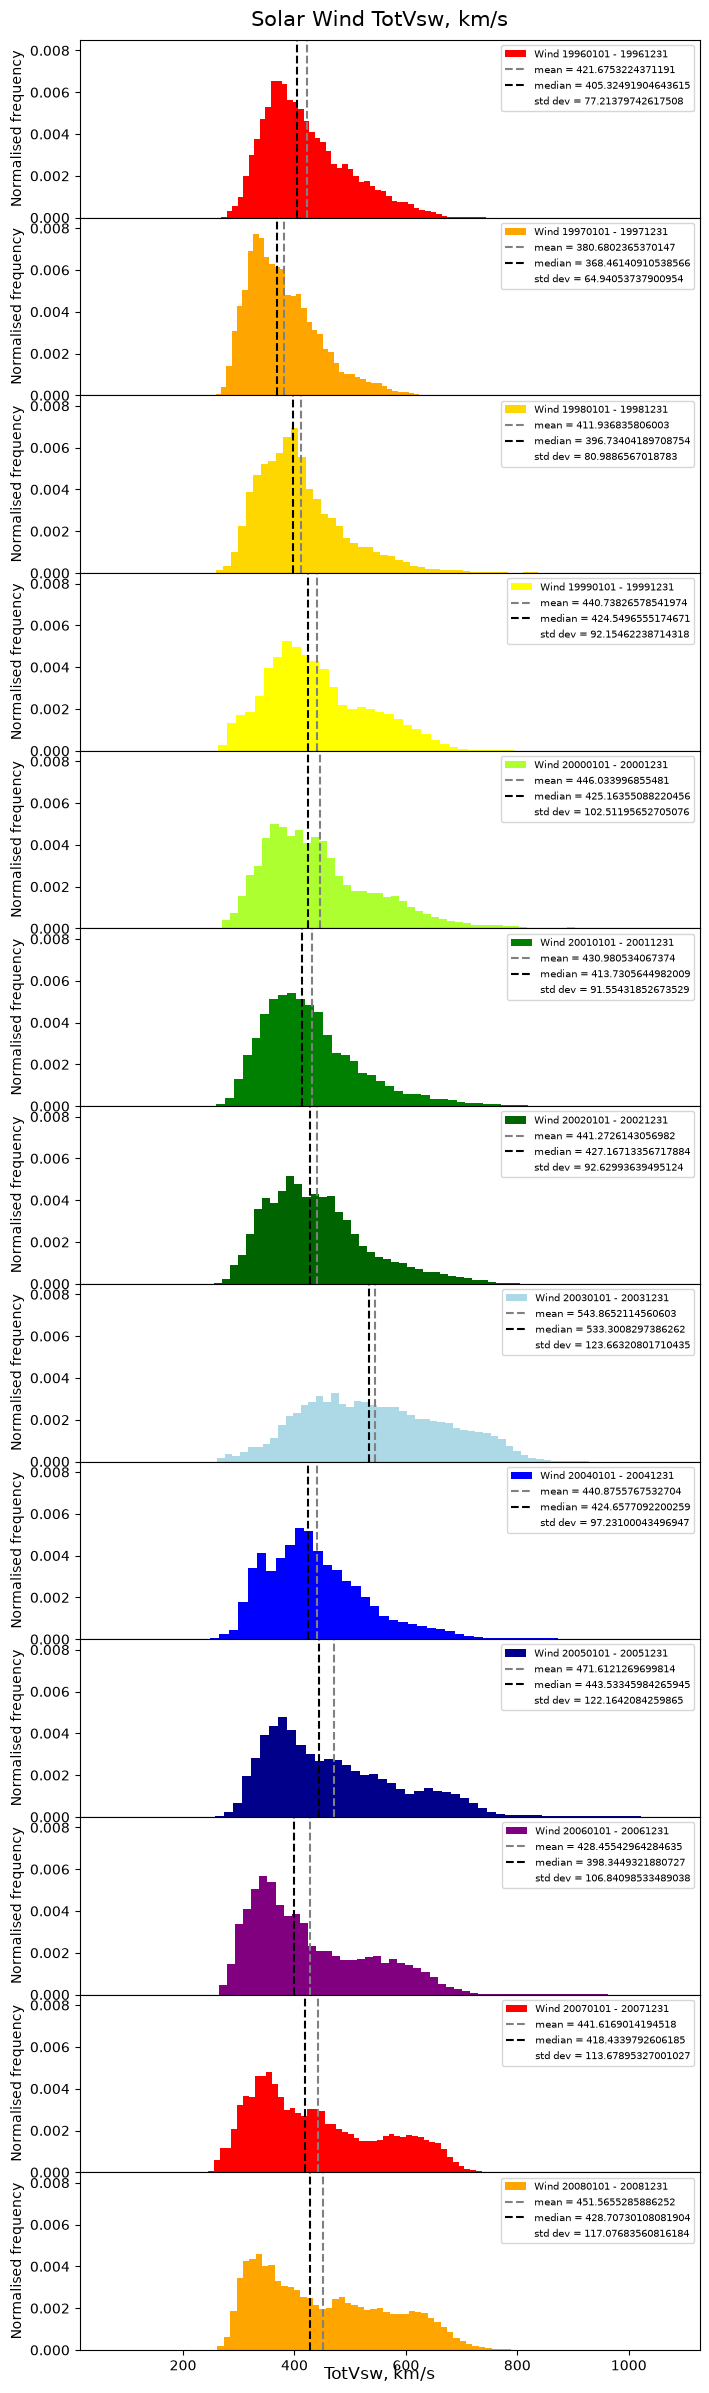

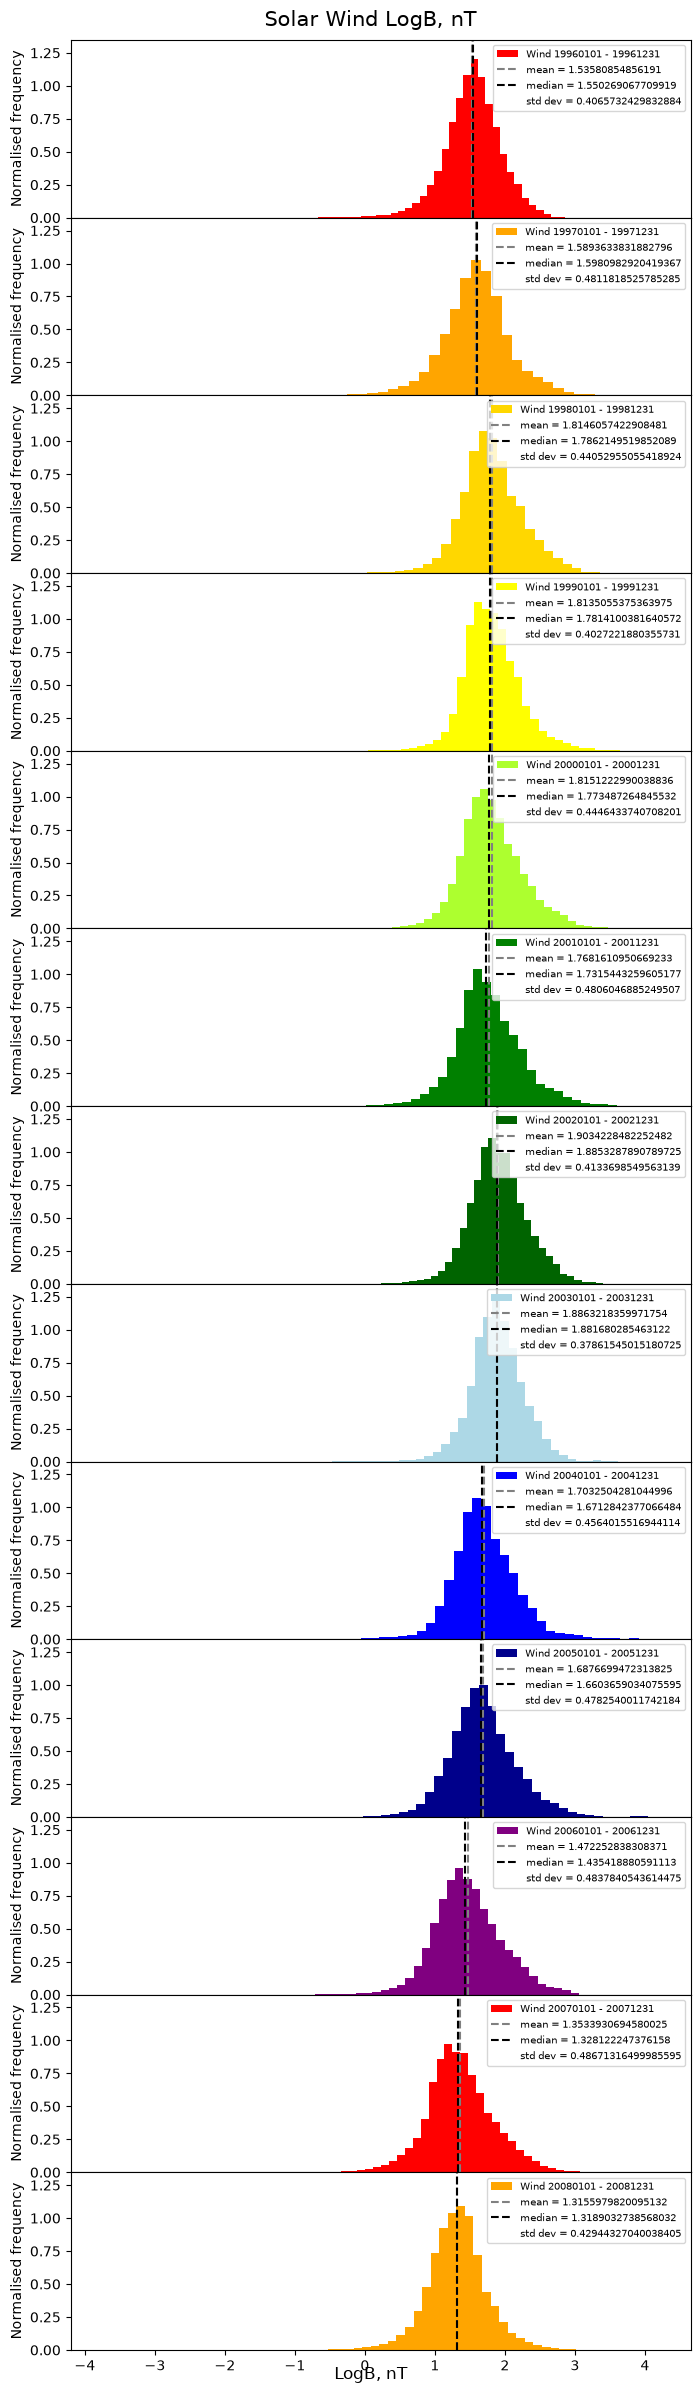

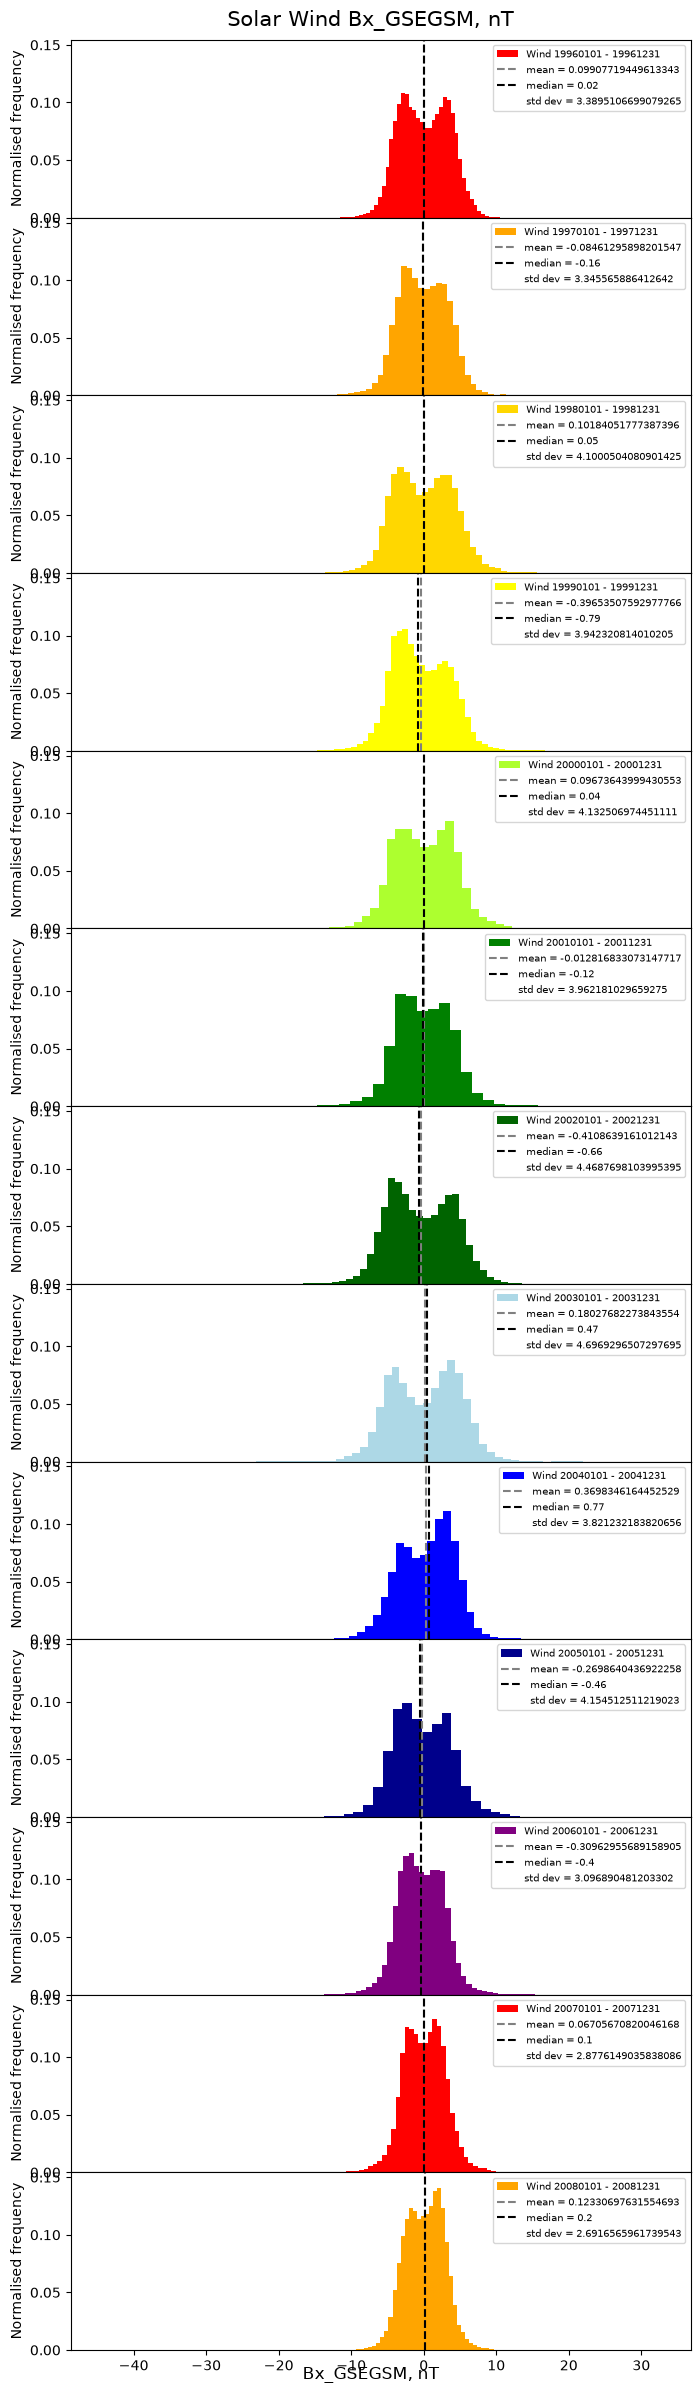

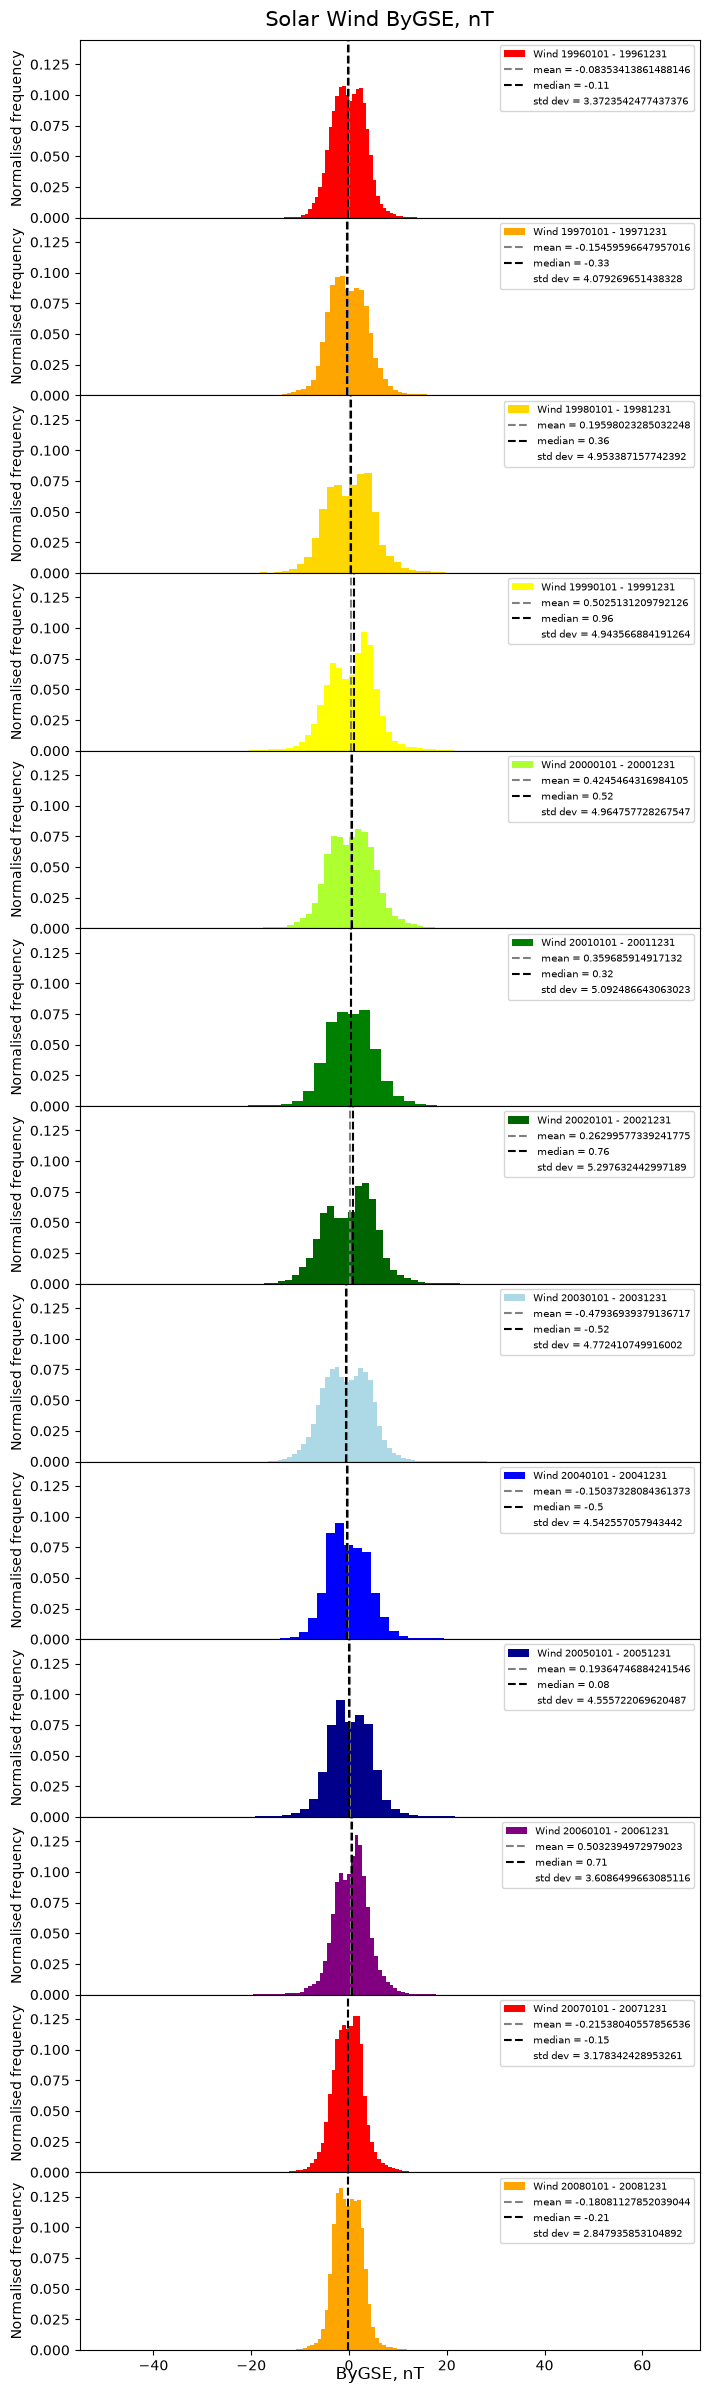

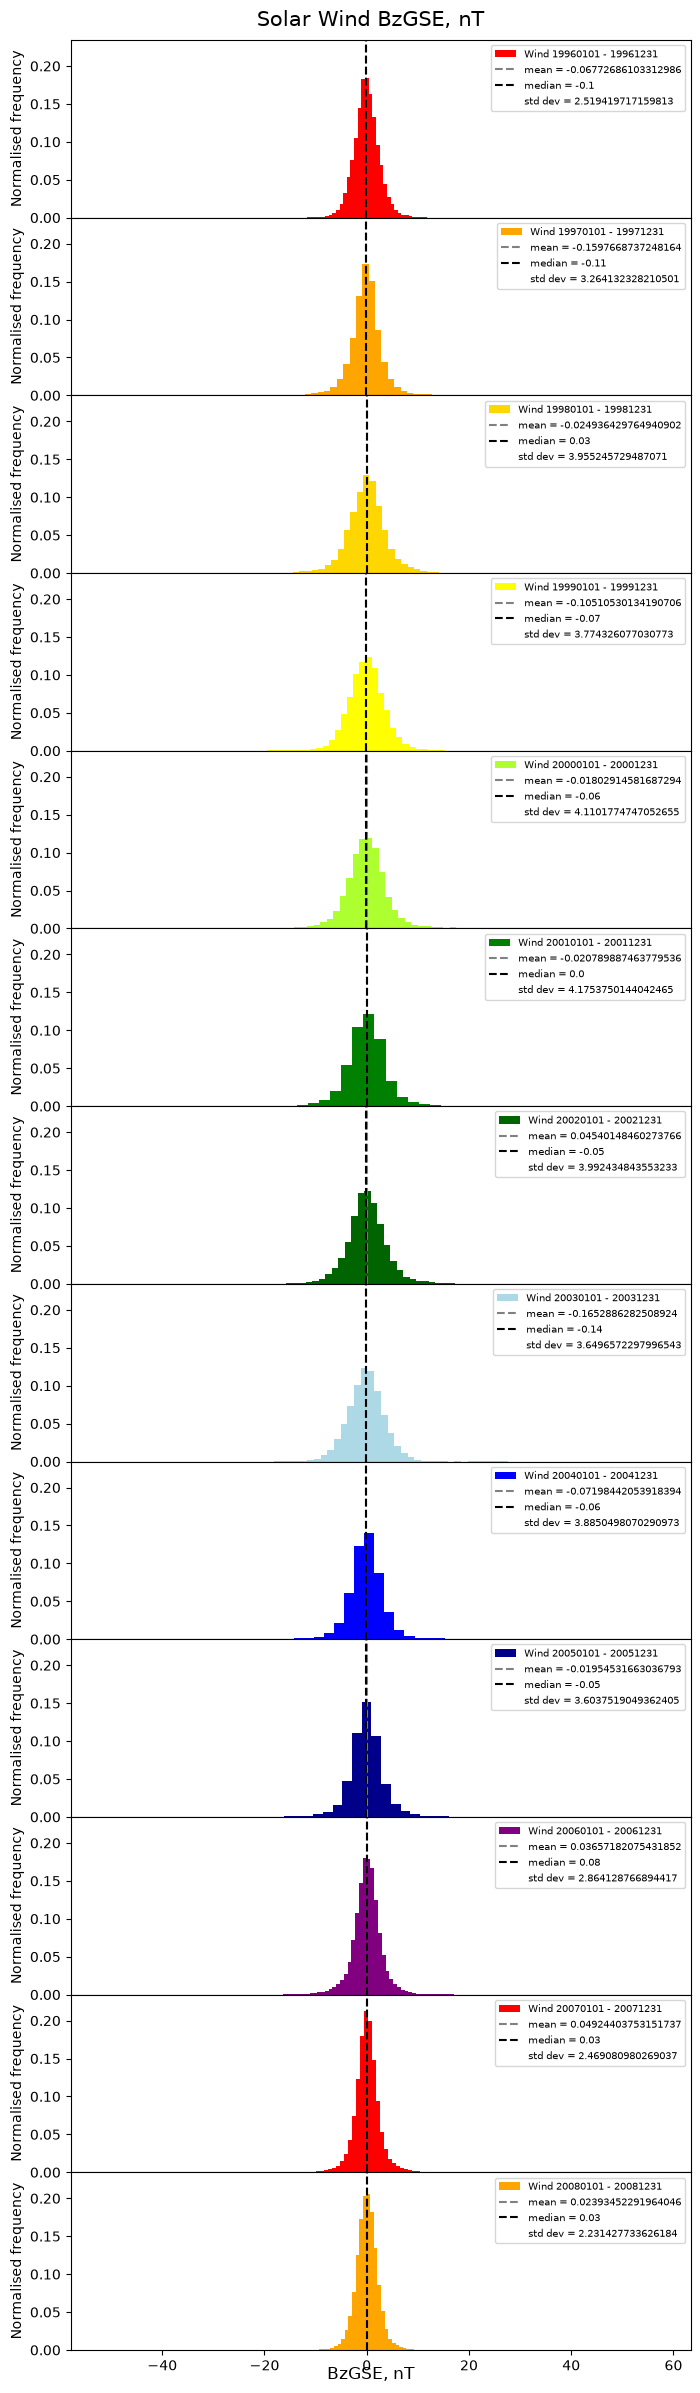

In [40]:
# Histogram formatting - Separate

Bin = 50
Alpha = 1
SupTitle = 15
Legend = 7.5
figSize = (8,30)
LegLoc = 'upper right'
SpaceLR = [100, 5, 5, 5, 5]
# Colours = ["red", "orange", "green", "blue"]
# Colours = ['pink','brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet','gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink']
Colours = ["red", "orange", "gold", "yellow", "greenyellow", "green", "darkgreen", "lightblue", "blue", "darkblue", "purple", "red", "orange", "gold", "yellow", "greenyellow", "green", "darkgreen", "lightblue", "blue", "darkblue", "purple", "red", "orange", "gold", "yellow", "greenyellow", "green", "darkgreen", "lightblue", "blue", "darkblue", "purple"]

    # "Bx_GSEGSM", "ByGSE", "BzGSE"
# dataTimeSerieses = [dataTSFirstDatesC23Min, dataTSFirstDatesC23Max, dataTSFirstDatesC24Min, dataTSFirstDatesC24Max]
# Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
XAxisScale = ["linear", "linear", "linear", "linear", "linear"]#, "nT"]
YAxisScale = ["linear", "linear", "linear", "linear", "linear"]#, "nT"]
# YAxisScale = ["linear", "log", "log", "log", "log"]
# YAxisScale = ["linear", "linear", "linear", "linear", "linear"]
# XAxisScale = ["linear", "log", "log", "log", "log"]#, "nT"]
Plotting = ["TotVsw", "LogB", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
# Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
# StartAndEnd = [[startDateC23Min, endDateC23Min], [startDateC23Max, endDateC23Max], [startDateC24Min, endDateC24Min], [startDateC23Max, endDateC23Max]]


# PlotHistSeparate(dataTimeSerieses, Plotting)

PlotHistSeparate(dataTimeSerieses[0:13], Plotting, XAxisScale, YAxisScale, figSize)
# PlotHistSeparate(dataTimeSerieses[13:25], Plotting)
# PlotHistSeparate(dataTimeSerieses[25:], Plotting)


# #Find DateRanges for each file needed found
# def ReadDates(startDate, endDate): #ReadDatesForFileFinding
#     DateRange = pd.date_range(startDate, endDate, freq='MS').strftime("%Y%m%d").tolist()
#     return DateRange

# Years overlapping


In [41]:
Cycle23 = dataTimeSerieses[0:11]
Cycle24 = dataTimeSerieses[11:22]
Cycle25 = dataTimeSerieses[22:30]

# print(Cycle23)
# print(dataTimeSerieses)
# PlotHistSeparate(dataTimeSerieses[13:25], Plotting)
# PlotHistSeparate(dataTimeSerieses[25:], Plotting)


In [42]:
#Plot histograms separately
def YearOverlap(dataTS1, dataTS2, dataTS3, VarsToPlot, NoOfYears, FigSize, TitleLoc, startYear): #, startSplit, endSplit):
    
    for i in range(len(VarsToPlot)):
        fig, axs = plt.subplots(NoOfYears,1, figsize=FigSize, sharex=True)
        fig.subplots_adjust(hspace=0)
        # plt.suptitle("Solar Wind "+ VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=0.89)
        fig.supxlabel("Wind Data" + VarsToPlot[i] + ", " + Units[i], y=TitleLoc)
        # subplotLabels = []

        maxYInDf1 = 0
        maxYInDf2 = 0
        maxYInDf3 = 0
        for j in range(len(dataTS1)):
        # for j in range(startSplit, endSplit):

            # axs[j].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'orange', label = "Cycle 23", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

            y, x, _ = axs[j].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'orange', label = "Cycle 23", density = True)
            maxInYear = y.max()
            if maxInYear > maxYInDf1:
                maxYInDf1 = maxInYear

            # C23
            #Mean
            axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "orange", label="mean = " + str(round(dataTS1[j]._data[VarsToPlot[i]].mean(), 2)))
            #Median
            axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "orange", label="median = " + str(round(dataTS1[j]._data[VarsToPlot[i]].median(),2)))
            #Standard deviation
            axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS1[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)


            if j < len(dataTS2):
                axs[j].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'green', label = "Cycle 24", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

                y, x, _ = axs[j].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'green', label = "Cycle 24", density = True)
                maxInYear = y.max()
                if maxInYear > maxYInDf2:
                    maxYInDf2 = maxInYear

                # C24
                #Mean
                axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "green", label="mean = " + str(round(dataTS2[j]._data[VarsToPlot[i]].mean(), 2)))
                #Median
                axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "green", label="median = " + str(round(dataTS2[j]._data[VarsToPlot[i]].median(), 2)))
                #Standard deviation
                axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS2[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)


            if j < len(dataTS3):
                axs[j].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'blue', label = "Cycle 25", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

                y, x, _ = axs[j].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'blue', label = "Cycle 25", density = True)
                maxInYear = y.max()
                if maxInYear > maxYInDf3:
                    maxYInDf3 = maxInYear

                # C25
                #Mean
                axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "blue", label="mean = " + str(round(dataTS3[j]._data[VarsToPlot[i]].mean(), 2)))
                #Median
                axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "blue", label="median = " + str(round(dataTS3[j]._data[VarsToPlot[i]].median(), 2)))
                #Standard deviation
                axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS3[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

        # for j in range(len(NoOfYears)):
        #     if j < len(dataTS):
            axs[j].legend(loc = LegLoc, fontsize = Legend)
            axs[j].set_ylabel("Normalised frequency")

            # subplotLabels.append("Year" + str(j))
            axs[j].annotate("Year " + str(startYear + j), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))


            # fig, axs = plt.subplot_mosaic([['a)', 'c)'], ['b)', 'c)'], ['d)', 'd)']], layout='constrained')
            # for label, ax in axs.items():
            #     ax.annotate(label, xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))

        # maxYInDf1 = 0
        # for k in range(len(dataTS1)): # For each daterange
        #     maxInYear = max(dataTS1[k]._data[VarsToPlot[i]])

        #     if maxInYear > maxYInDf1:
        #         maxYInDf1 = maxInYear

        # maxYInDf2 = 0
        # for l in range(len(dataTS2)): # For each daterange
        #     maxInYear = max(dataTS2[l]._data[VarsToPlot[i]])
            
        #     if maxInYear > maxYInDf2:
        #         maxYInDf2 = maxInYear

        # maxYInDf3 = 0
        # for m in range(len(dataTS3)): # For each daterange
        #     maxInYear = max(dataTS3[m]._data[VarsToPlot[i]])
            
        #     if maxInYear > maxYInDf3:
        #         maxYInDf3 = maxInYear
            
        maxYsInDfs = [maxYInDf1, maxYInDf2, maxYInDf3]
        maxYOverall = max(maxYsInDfs)
        for j in range(len(dataTS1)):
            axs[j].set_ylim(0, maxYOverall)

            
            #     # axs[1].legend(loc = LegLoc, fontsize = Legend)
            #     # axs[2].legend(loc = LegLoc, fontsize = Legend)
            #     # axs[3].legend(loc = LegLoc, fontsize = Legend)
            
            # # LowerBounds.append(min(dataTimeSerieses[j]._data[VarsToPlot[i]].values))
            # # UpperBounds.append(max(dataTimeSerieses[j]._data[VarsToPlot[i]].values))
            # # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
            # # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
            # # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
            # # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
            # # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
            # # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
            # axs[j].set_ylabel("Normalised frequency")
        

        # # plt.xlim(min(LowerBounds) - SpaceLR[i], max(UpperBounds) + SpaceLR[i])
        # # plt.xlim(np.nanmin(LowerBounds) - SpaceLR[i], np.nanmax(UpperBounds) + SpaceLR[i])

        # plt.xscale(XAxisScale[i])
        

        # # for m in range(len(dataTimeSerieses)):
        # #     if maxY == np.nan or maxY == np.inf:
        # #             print("Max is nan or inf.")
        #     # else:
        # for m in range(len(dataTimeSerieses)):
        #     # axs[m].set_ylim(0, maxY)
        #     axs[m].set_ylim(0, maxY+ 0.1*maxY)
        # # plt.tight_layout()
        # plt.yscale(YAxisScale[i])
        
        # plt.savefig("Plots/Wind/" + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + "_Wind.png")
        plt.show()

In [43]:
# Bin = 50
# Alpha = 1
# SupTitle = 15
# Legend = 7.5
# # figSize = (10, 35) # for 11 plots
# figSize6 = (10, 35 *(6/11)) # for 6 plots
# figSize5 = (10, 35 *(5/11)) # for 5 plots

# LegLoc = 'upper right'
# titleLoc = 0.9
# SpaceLR = [100, 5, 5, 5, 5]
# # Colours = ["red", "orange", "green", "blue"]
# Colours = ['pink','brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet','gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink']

#     # "Bx_GSEGSM", "ByGSE", "BzGSE"
# # dataTimeSerieses = [dataTSFirstDatesC23Min, dataTSFirstDatesC23Max, dataTSFirstDatesC24Min, dataTSFirstDatesC24Max]
# Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
# Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
# XAxisScale = ["linear", "linear", "linear", "linear", "linear"]#, "nT"]
# YAxisScale = ["linear", "linear", "linear", "linear", "linear"]#, "nT"]
# # YAxisScale = ["linear", "log", "log", "log", "log"]
# # YAxisScale = ["linear", "linear", "linear", "linear", "linear"]
# # XAxisScale = ["linear", "log", "log", "log", "log"]#, "nT"]
# # Plotting = ["TotVsw", "LogB", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
# # Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
# # StartAndEnd = [[startDateC23Min, endDateC23Min], [startDateC23Max, endDateC23Max], [startDateC24Min, endDateC24Min], [startDateC23Max, endDateC23Max]]
# noOfYears = 11

# # Cycle23 = dfToSeries(Cycle23)
# # Cycle24 = dfToSeries(Cycle24)
# # Cycle25 = dfToSeries(Cycle25)

# # YearOverlap(Cycle23, Cycle24, Cycle25, Plotting, noOfYears, figSize, titleLoc, 1)
# YearOverlap(Cycle23[0:6], Cycle24[0:6], Cycle25[0:6], Plotting, 6, figSize6, titleLoc, 1) #, 0, 6)
# YearOverlap(Cycle23[6:11], Cycle24[6:11], Cycle25[6:8], Plotting, 5, figSize5, titleLoc, 7) #, 6, 11)

In [44]:
# #SAFE COPY
# #Plot histograms with a split - sharing y axis that checks across all years
# def YearOverlapGlobalYAxis(dataTS1, dataTS2, dataTS3, VarsToPlot, FigSize, TitleLoc, startSplit1, endSplit1, startSplit2, endSplit2, XAxisScale, Bins):

#     maxYOverall = []
#     yScaleLim = []
    
#     for i in range(len(VarsToPlot)):

#         fig, axs = plt.subplots( (endSplit1-startSplit1) , 1, figsize=(FigSize[0], FigSize[1]*(endSplit1-startSplit1)/11), sharex=True)
#         fig.subplots_adjust(hspace=0)
#         plt.suptitle("Wind Data, " + VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=TitleLoc)
#         fig.supxlabel(VarsToPlot[i] + ", " + Units[i], y=0.085)
#         plt.xscale(XAxisScale[i])
#         # subplotLabels = []

#         maxYInDf11 = 0
#         maxYInDf21 = 0
#         maxYInDf31 = 0
#         maxYInDf12 = 0
#         maxYInDf22 = 0
#         maxYInDf32 = 0
#         # for j in range(len(dataTS1)):
#         for j in range(startSplit1, endSplit1):

#             # axs[j].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'orange', label = "Cycle 23", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

#             y, x, _ = axs[j].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'orange', label = "Cycle 23", density = True)
#             maxInYear = y.max()
#             if maxInYear > maxYInDf11:
#                 maxYInDf11 = maxInYear

#             # C23
#             #Mean
#             axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "orange", label="mean = " + str(round(dataTS1[j]._data[VarsToPlot[i]].mean(), 2)))
#             #Median
#             axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "orange", label="median = " + str(round(dataTS1[j]._data[VarsToPlot[i]].median(),2)))
#             #Standard deviation
#             axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS1[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)


#             if j < len(dataTS2):
#                 # axs[j].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'green', label = "Cycle 24", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

#                 y, x, _ = axs[j].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'green', label = "Cycle 24", density = True)
#                 maxInYear = y.max()
#                 if maxInYear > maxYInDf21:
#                     maxYInDf21 = maxInYear

#                 # C24
#                 #Mean
#                 axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "green", label="mean = " + str(round(dataTS2[j]._data[VarsToPlot[i]].mean(), 2)))
#                 #Median
#                 axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "green", label="median = " + str(round(dataTS2[j]._data[VarsToPlot[i]].median(), 2)))
#                 #Standard deviation
#                 axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS2[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)


#             if j < len(dataTS3):
#                 # axs[j].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'blue', label = "Cycle 25", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

#                 y, x, _ = axs[j].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'blue', label = "Cycle 25", density = True)
#                 maxInYear = y.max()
#                 if maxInYear > maxYInDf31:
#                     maxYInDf31 = maxInYear

#                 # C25
#                 #Mean
#                 axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "blue", label="mean = " + str(round(dataTS3[j]._data[VarsToPlot[i]].mean(), 2)))
#                 #Median
#                 axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "blue", label="median = " + str(round(dataTS3[j]._data[VarsToPlot[i]].median(), 2)))
#                 #Standard deviation
#                 axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS3[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

#         # for j in range(len(NoOfYears)):
#         #     if j < len(dataTS):
#             axs[j].legend(loc = LegLoc, fontsize = Legend)
#             axs[j].set_ylabel("Normalised frequency")

#             # subplotLabels.append("Year" + str(j))
#             axs[j].annotate("Year " + str(j + 1), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))
#             # axs[j].annotate(str(StartAndEnd[j][0][0:4]), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))

#             # fig, axs = plt.subplot_mosaic([['a)', 'c)'], ['b)', 'c)'], ['d)', 'd)']], layout='constrained')
#             # for label, ax in axs.items():
#             #     ax.annotate(label, xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))

#         # maxYInDf1 = 0
#         # for k in range(len(dataTS1)): # For each daterange
#         #     maxInYear = max(dataTS1[k]._data[VarsToPlot[i]])

#         #     if maxInYear > maxYInDf1:
#         #         maxYInDf1 = maxInYear

#         # maxYInDf2 = 0
#         # for l in range(len(dataTS2)): # For each daterange
#         #     maxInYear = max(dataTS2[l]._data[VarsToPlot[i]])
            
#         #     if maxInYear > maxYInDf2:
#         #         maxYInDf2 = maxInYear

#         # maxYInDf3 = 0
#         # for m in range(len(dataTS3)): # For each daterange
#         #     maxInYear = max(dataTS3[m]._data[VarsToPlot[i]])
            
#         #     if maxInYear > maxYInDf3:
#         #         maxYInDf3 = maxInYear
            
        
#         fig2, axs2 = plt.subplots( (endSplit2-startSplit2) , 1, figsize=(FigSize[0], FigSize[1]*(endSplit2-startSplit2)/11), sharex=True)
#         fig2.subplots_adjust(hspace=0)
#         plt.suptitle("Wind Data, " + VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=0.9)
#         fig2.supxlabel(VarsToPlot[i] + ", " + Units[i], y=0.085)
#         plt.xscale(XAxisScale[i])
#         # subplotLabels = []

#         for j in range(startSplit2, endSplit2):

#             # fig, axs = plt.subplots( (endSplit2-startSplit2) , 1, figsize=FigSize, sharex=True)
#             # fig.subplots_adjust(hspace=0)
#             # # plt.suptitle("Solar Wind "+ VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=0.89)
#             # fig.supxlabel("Wind Data" + VarsToPlot[i] + ", " + Units[i], y=TitleLoc)
#             # # subplotLabels = []

#             axNo = j-startSplit2

#             # axs[j].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'orange', label = "Cycle 23", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

#             y, x, _ = axs2[axNo].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'orange', label = "Cycle 23", density = True)
#             maxInYear = y.max()
#             if maxInYear > maxYInDf12:
#                 maxYInDf12 = maxInYear

#             # C23
#             #Mean
#             axs2[axNo].axvline(dataTS1[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "orange", label="mean = " + str(round(dataTS1[j]._data[VarsToPlot[i]].mean(), 2)))
#             #Median
#             axs2[axNo].axvline(dataTS1[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "orange", label="median = " + str(round(dataTS1[j]._data[VarsToPlot[i]].median(),2)))
#             #Standard deviation
#             axs2[axNo].axvline(dataTS1[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS1[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

#             if j < len(dataTS2):
#                 # axs[axNo].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'green', label = "Cycle 24", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

#                 y, x, _ = axs2[axNo].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'green', label = "Cycle 24", density = True)
#                 maxInYear = y.max()
#                 if maxInYear > maxYInDf22:
#                     maxYInDf22 = maxInYear

#                 # C24
#                 #Mean
#                 axs2[axNo].axvline(dataTS2[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "green", label="mean = " + str(round(dataTS2[j]._data[VarsToPlot[i]].mean(), 2)))
#                 #Median
#                 axs2[axNo].axvline(dataTS2[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "green", label="median = " + str(round(dataTS2[j]._data[VarsToPlot[i]].median(), 2)))
#                 #Standard deviation
#                 axs2[axNo].axvline(dataTS2[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS2[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)


#             if j < len(dataTS3):
#                 # axs[axNo].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'blue', label = "Cycle 25", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

#                 y, x, _ = axs2[axNo].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'blue', label = "Cycle 25", density = True)
#                 maxInYear = y.max()
#                 if maxInYear > maxYInDf32:
#                     maxYInDf32 = maxInYear

#                 # C25
#                 #Mean
#                 axs2[axNo].axvline(dataTS3[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "blue", label="mean = " + str(round(dataTS3[j]._data[VarsToPlot[i]].mean(), 2)))
#                 #Median
#                 axs2[axNo].axvline(dataTS3[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "blue", label="median = " + str(round(dataTS3[j]._data[VarsToPlot[i]].median(), 2)))
#                 #Standard deviation
#                 axs2[axNo].axvline(dataTS3[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS3[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

#         # for j in range(len(NoOfYears)):
#         #     if j < len(dataTS):
#             axs2[axNo].legend(loc = LegLoc, fontsize = Legend)
#             axs2[axNo].set_ylabel("Normalised frequency")

#             # subplotLabels.append("Year" + str(j))
#             axs2[axNo].annotate("Year " + str(j+1), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))
#             # axs2[axNo].annotate(str(StartAndEnd[j][0][0:4]), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))

#         maxYsInDfs = [maxYInDf11, maxYInDf21, maxYInDf31, maxYInDf12, maxYInDf22, maxYInDf32]
#         maxYOverall = max(maxYsInDfs)
#         yScaleLim.append(maxYOverall)

#         for j in range(startSplit1, endSplit1):
#             # axs[j].set_ylim(0, maxYOverall)
#             axs[j].set_ylim(0, maxYOverall*1.1) # adding 10% to y axis lim


#         for j in range(startSplit2, endSplit2):
#             axNo = j-startSplit2
#             # axs2[axNo].set_ylim(0, maxYOverall)
#             axs2[axNo].set_ylim(0, maxYOverall*1.1) # adding 10% to y axis lim
        

#         # # plt.xlim(min(LowerBounds) - SpaceLR[i], max(UpperBounds) + SpaceLR[i])
#         # # plt.xlim(np.nanmin(LowerBounds) - SpaceLR[i], np.nanmax(UpperBounds) + SpaceLR[i])

        
        

#         # # for m in range(len(dataTimeSerieses)):
#         # #     if maxY == np.nan or maxY == np.inf:
#         # #             print("Max is nan or inf.")
#         #     # else:
#         # for m in range(len(dataTimeSerieses)):
#         #     # axs[m].set_ylim(0, maxY)
#         #     axs[m].set_ylim(0, maxY+ 0.1*maxY)
#         # # plt.tight_layout()
#         # plt.yscale(YAxisScale[i])
#         # fig.xscale(XAxisScale[i])
#         # fig2.xscale(XAxisScale[i])
        
#         fig.savefig(PlotDirectory + StartAndEnd[startSplit1][0][0:10] + "->" + StartAndEnd[endSplit1][1][0:10] + VarsToPlot[i] + "FirstHalf_Wind.png")
#         fig2.savefig(PlotDirectory + StartAndEnd[startSplit2][0][0:10] + "->" + StartAndEnd[endSplit2][1][0:10] + VarsToPlot[i] + "SecondHalf_Wind.png")

#         plt.show()
#     return yScaleLim

In [45]:
#Plot histograms with a split - sharing y axis that checks across all years
def YearOverlapGlobalYAxis(dataTS1, dataTS2, dataTS3, VarsToPlot, FigSize, TitleLoc, startSplit1, endSplit1, startSplit2, endSplit2, XAxisScale, Bins):

    maxYOverall = []
    yScaleLim = []
    XScaleMaxLim = []
    XScaleMinLim = []

    meansTS1 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))
    mediansTS1 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))
    stdDevsTS1 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))

    meansTS2 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))
    mediansTS2 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))
    stdDevsTS2 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))

    meansTS3 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))
    mediansTS3 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))
    stdDevsTS3 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))

    meansTS1[:] = np.nan
    mediansTS1[:] = np.nan
    stdDevsTS1[:] = np.nan
    meansTS2[:] = np.nan
    mediansTS2[:] = np.nan
    stdDevsTS2[:] = np.nan
    meansTS3[:] = np.nan
    mediansTS3[:] = np.nan
    stdDevsTS3[:] = np.nan
    
    for i in range(len(VarsToPlot)):

        fig, axs = plt.subplots( (endSplit1-startSplit1) , 1, figsize=(FigSize[0], FigSize[1]*(endSplit1-startSplit1)/11), sharex=True)
        fig.subplots_adjust(hspace=0)
        plt.suptitle("Wind Data, " + VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=TitleLoc)
        fig.supxlabel(VarsToPlot[i] + ", " + Units[i], y=0.085)
        plt.xscale(XAxisScale[i])
        # subplotLabels = []

        maxYInDf11 = 0
        maxYInDf21 = 0
        maxYInDf31 = 0
        maxYInDf12 = 0
        maxYInDf22 = 0
        maxYInDf32 = 0

        maxXInDf11 = 0
        maxXInDf21 = 0
        maxXInDf31 = 0
        maxXInDf12 = 0
        maxXInDf22 = 0
        maxXInDf32 = 0

        minXInDf11 = 0
        minXInDf21 = 0
        minXInDf31 = 0
        minXInDf12 = 0
        minXInDf22 = 0
        minXInDf32 = 0

        # for j in range(len(dataTS1)):
        for j in range(startSplit1, endSplit1):

            # axs[j].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'orange', label = "Cycle 23", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

            y, x, _ = axs[j].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'orange', label = "Cycle 23", density = True)
            maxInYear = y.max()
            if maxInYear > maxYInDf11:
                maxYInDf11 = maxInYear

            maxXInYear = x.max()
            if maxXInYear > maxXInDf11:
                maxXInDf11 = maxXInYear

            minXInYear = x.min()
            if minXInYear < minXInDf11:
                minXInDf11 = minXInYear

            # C23
            #Mean
            axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "orange", label="mean = " + str(round(dataTS1[j]._data[VarsToPlot[i]].mean(), 2)))
            #Median
            axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "orange", label="median = " + str(round(dataTS1[j]._data[VarsToPlot[i]].median(),2)))
            #Standard deviation
            axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS1[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

            meansTS1[i][j] = dataTS1[j]._data[VarsToPlot[i]].mean()
            mediansTS1[i][j] = dataTS1[j]._data[VarsToPlot[i]].median()
            stdDevsTS1[i][j] = dataTS1[j]._data[VarsToPlot[i]].std()

            if j < len(dataTS2):
                # axs[j].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'green', label = "Cycle 24", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

                y, x, _ = axs[j].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'green', label = "Cycle 24", density = True)
                maxInYear = y.max()
                if maxInYear > maxYInDf21:
                    maxYInDf21 = maxInYear

                maxXInYear = x.max()
                if maxXInYear > maxXInDf21:
                    maxXInDf21 = maxXInYear

                minXInYear = x.min()
                if minXInYear < minXInDf21:
                    minXInDf21 = minXInYear

                # C24
                #Mean
                axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "green", label="mean = " + str(round(dataTS2[j]._data[VarsToPlot[i]].mean(), 2)))
                #Median
                axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "green", label="median = " + str(round(dataTS2[j]._data[VarsToPlot[i]].median(), 2)))
                #Standard deviation
                axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS2[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

                meansTS2[i][j] = dataTS2[j]._data[VarsToPlot[i]].mean()
                mediansTS2[i][j] = dataTS2[j]._data[VarsToPlot[i]].median()
                stdDevsTS2[i][j] = dataTS2[j]._data[VarsToPlot[i]].std()

            if j < len(dataTS3):
                # axs[j].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'blue', label = "Cycle 25", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

                y, x, _ = axs[j].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'blue', label = "Cycle 25", density = True)
                maxInYear = y.max()
                if maxInYear > maxYInDf31:
                    maxYInDf31 = maxInYear

                maxXInYear = x.max()
                if maxXInYear > maxXInDf31:
                    maxXInDf31 = maxXInYear

                minXInYear = x.min()
                if minXInYear < minXInDf31:
                    minXInDf31 = minXInYear

                # C25
                #Mean
                axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "blue", label="mean = " + str(round(dataTS3[j]._data[VarsToPlot[i]].mean(), 2)))
                #Median
                axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "blue", label="median = " + str(round(dataTS3[j]._data[VarsToPlot[i]].median(), 2)))
                #Standard deviation
                axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS3[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

                meansTS3[i][j] = dataTS3[j]._data[VarsToPlot[i]].mean()
                mediansTS3[i][j] = dataTS3[j]._data[VarsToPlot[i]].median()
                stdDevsTS3[i][j] = dataTS3[j]._data[VarsToPlot[i]].std()

        # for j in range(len(NoOfYears)):
        #     if j < len(dataTS):
            axs[j].legend(loc = LegLoc, fontsize = Legend)
            axs[j].set_ylabel("Normalised frequency")

            # subplotLabels.append("Year" + str(j))
            axs[j].annotate("Year " + str(j + 1), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))
            # axs[j].annotate(str(StartAndEnd[j][0][0:4]), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))

            # fig, axs = plt.subplot_mosaic([['a)', 'c)'], ['b)', 'c)'], ['d)', 'd)']], layout='constrained')
            # for label, ax in axs.items():
            #     ax.annotate(label, xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))

        # maxYInDf1 = 0
        # for k in range(len(dataTS1)): # For each daterange
        #     maxInYear = max(dataTS1[k]._data[VarsToPlot[i]])

        #     if maxInYear > maxYInDf1:
        #         maxYInDf1 = maxInYear

        # maxYInDf2 = 0
        # for l in range(len(dataTS2)): # For each daterange
        #     maxInYear = max(dataTS2[l]._data[VarsToPlot[i]])
            
        #     if maxInYear > maxYInDf2:
        #         maxYInDf2 = maxInYear

        # maxYInDf3 = 0
        # for m in range(len(dataTS3)): # For each daterange
        #     maxInYear = max(dataTS3[m]._data[VarsToPlot[i]])
            
        #     if maxInYear > maxYInDf3:
        #         maxYInDf3 = maxInYear
            
        
        fig2, axs2 = plt.subplots( (endSplit2-startSplit2) , 1, figsize=(FigSize[0], FigSize[1]*(endSplit2-startSplit2)/11), sharex=True)
        fig2.subplots_adjust(hspace=0)
        plt.suptitle("Wind Data, " + VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=0.9)
        fig2.supxlabel(VarsToPlot[i] + ", " + Units[i], y=0.085)
        plt.xscale(XAxisScale[i])
        # subplotLabels = []

        for j in range(startSplit2, endSplit2):

            # fig, axs = plt.subplots( (endSplit2-startSplit2) , 1, figsize=FigSize, sharex=True)
            # fig.subplots_adjust(hspace=0)
            # # plt.suptitle("Solar Wind "+ VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=0.89)
            # fig.supxlabel("Wind Data" + VarsToPlot[i] + ", " + Units[i], y=TitleLoc)
            # # subplotLabels = []

            axNo = j-startSplit2

            # axs[j].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'orange', label = "Cycle 23", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

            y, x, _ = axs2[axNo].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'orange', label = "Cycle 23", density = True)
            maxInYear = y.max()
            if maxInYear > maxYInDf12:
                maxYInDf12 = maxInYear

            maxXInYear = x.max()
            if maxXInYear > maxXInDf12:
                maxXInDf12 = maxXInYear

            minXInYear = x.min()
            if minXInYear < minXInDf12:
                minXInDf12 = minXInYear

            # C23
            #Mean
            axs2[axNo].axvline(dataTS1[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "orange", label="mean = " + str(round(dataTS1[j]._data[VarsToPlot[i]].mean(), 2)))
            #Median
            axs2[axNo].axvline(dataTS1[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "orange", label="median = " + str(round(dataTS1[j]._data[VarsToPlot[i]].median(),2)))
            #Standard deviation
            axs2[axNo].axvline(dataTS1[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS1[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

            meansTS1[i][j] = dataTS1[j]._data[VarsToPlot[i]].mean()
            mediansTS1[i][j] = dataTS1[j]._data[VarsToPlot[i]].median()
            stdDevsTS1[i][j] = dataTS1[j]._data[VarsToPlot[i]].std()
            
            if j < len(dataTS2):
                # axs[axNo].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'green', label = "Cycle 24", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

                y, x, _ = axs2[axNo].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'green', label = "Cycle 24", density = True)
                maxInYear = y.max()
                if maxInYear > maxYInDf22:
                    maxYInDf22 = maxInYear

                maxXInYear = x.max()
                if maxXInYear > maxXInDf22:
                    maxXInDf22 = maxXInYear

                minXInYear = x.min()
                if minXInYear < minXInDf22:
                    minXInDf22 = minXInYear

                # C24
                #Mean
                axs2[axNo].axvline(dataTS2[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "green", label="mean = " + str(round(dataTS2[j]._data[VarsToPlot[i]].mean(), 2)))
                #Median
                axs2[axNo].axvline(dataTS2[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "green", label="median = " + str(round(dataTS2[j]._data[VarsToPlot[i]].median(), 2)))
                #Standard deviation
                axs2[axNo].axvline(dataTS2[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS2[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

                meansTS2[i][j] = dataTS2[j]._data[VarsToPlot[i]].mean()
                mediansTS2[i][j] = dataTS2[j]._data[VarsToPlot[i]].median()
                stdDevsTS2[i][j] = dataTS2[j]._data[VarsToPlot[i]].std()

            if j < len(dataTS3):
                # axs[axNo].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'blue', label = "Cycle 25", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

                y, x, _ = axs2[axNo].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'blue', label = "Cycle 25", density = True)
                maxInYear = y.max()
                if maxInYear > maxYInDf32:
                    maxYInDf32 = maxInYear

                maxXInYear = x.max()
                if maxXInYear > maxXInDf32:
                    maxXInDf32 = maxXInYear

                minXInYear = x.min()
                if minXInYear < minXInDf32:
                    minXInDf32 = minXInYear

                # C25
                #Mean
                axs2[axNo].axvline(dataTS3[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "blue", label="mean = " + str(round(dataTS3[j]._data[VarsToPlot[i]].mean(), 2)))
                #Median
                axs2[axNo].axvline(dataTS3[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "blue", label="median = " + str(round(dataTS3[j]._data[VarsToPlot[i]].median(), 2)))
                #Standard deviation
                axs2[axNo].axvline(dataTS3[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS3[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

                meansTS3[i][j] = dataTS3[j]._data[VarsToPlot[i]].mean()
                mediansTS3[i][j] = dataTS3[j]._data[VarsToPlot[i]].median()
                stdDevsTS3[i][j] = dataTS3[j]._data[VarsToPlot[i]].std()
                
        # for j in range(len(NoOfYears)):
        #     if j < len(dataTS):
            axs2[axNo].legend(loc = LegLoc, fontsize = Legend)
            axs2[axNo].set_ylabel("Normalised frequency")

            # subplotLabels.append("Year" + str(j))
            axs2[axNo].annotate("Year " + str(j+1), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))
            # axs2[axNo].annotate(str(StartAndEnd[j][0][0:4]), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))

        maxYsInDfs = [maxYInDf11, maxYInDf21, maxYInDf31, maxYInDf12, maxYInDf22, maxYInDf32]
        maxYOverall = max(maxYsInDfs)
        yScaleLim.append(maxYOverall)

        for j in range(startSplit1, endSplit1):
            # axs[j].set_ylim(0, maxYOverall)
            axs[j].set_ylim(0, maxYOverall*1.1) # adding 10% to y axis lim


        for j in range(startSplit2, endSplit2):
            axNo = j-startSplit2
            # axs2[axNo].set_ylim(0, maxYOverall)
            axs2[axNo].set_ylim(0, maxYOverall*1.1) # adding 10% to y axis lim




        maxXsInDfs = [maxXInDf11, maxXInDf21, maxXInDf31, maxXInDf12, maxXInDf22, maxXInDf32]
        maxXOverall = max(maxXsInDfs)
        XScaleMaxLim.append(maxXOverall)

        minXsInDfs = [minXInDf11, minXInDf21, minXInDf31, minXInDf12, minXInDf22, minXInDf32]
        minXOverall = min(minXsInDfs)
        XScaleMinLim.append(minXOverall)

        # # plt.xlim(min(LowerBounds) - SpaceLR[i], max(UpperBounds) + SpaceLR[i])
        # # plt.xlim(np.nanmin(LowerBounds) - SpaceLR[i], np.nanmax(UpperBounds) + SpaceLR[i])

        
        

        # # for m in range(len(dataTimeSerieses)):
        # #     if maxY == np.nan or maxY == np.inf:
        # #             print("Max is nan or inf.")
        #     # else:
        # for m in range(len(dataTimeSerieses)):
        #     # axs[m].set_ylim(0, maxY)
        #     axs[m].set_ylim(0, maxY+ 0.1*maxY)
        # # plt.tight_layout()
        # plt.yscale(YAxisScale[i])
        # fig.xscale(XAxisScale[i])
        # fig2.xscale(XAxisScale[i])
        
        fig.savefig(PlotDirectory + StartAndEnd[startSplit1][0][0:10] + "->" + StartAndEnd[endSplit1][1][0:10] + VarsToPlot[i] + "FirstHalf_Wind.png")
        fig2.savefig(PlotDirectory + StartAndEnd[startSplit2][0][0:10] + "->" + StartAndEnd[endSplit2][1][0:10] + VarsToPlot[i] + "SecondHalf_Wind.png")

        plt.show()
    return yScaleLim, XScaleMaxLim, XScaleMinLim, meansTS1, meansTS2, meansTS3, mediansTS1, mediansTS2, mediansTS3, stdDevsTS1, stdDevsTS2, stdDevsTS3

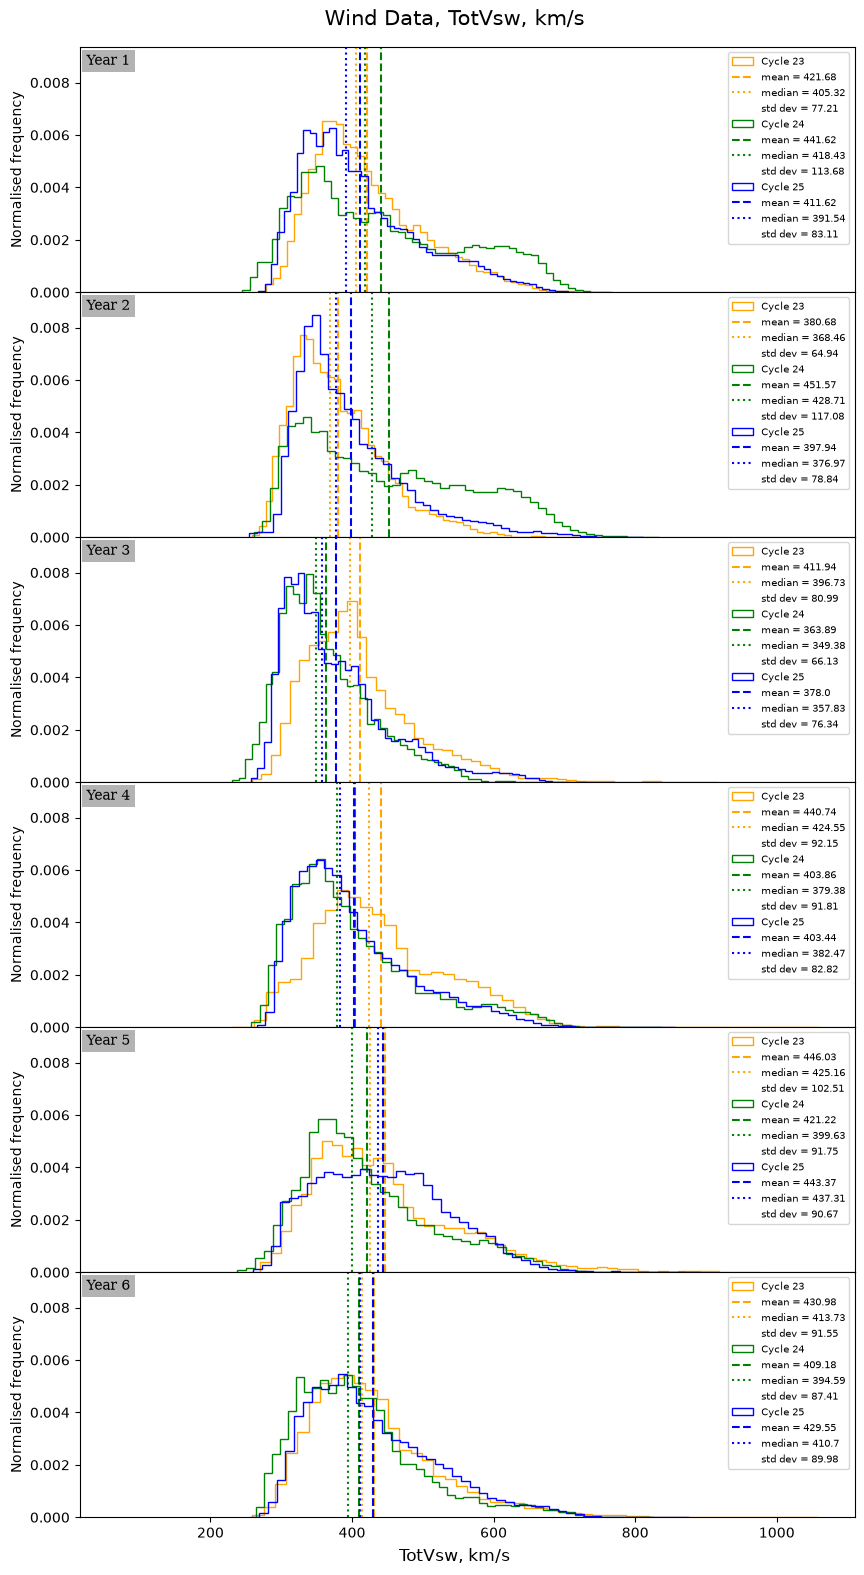

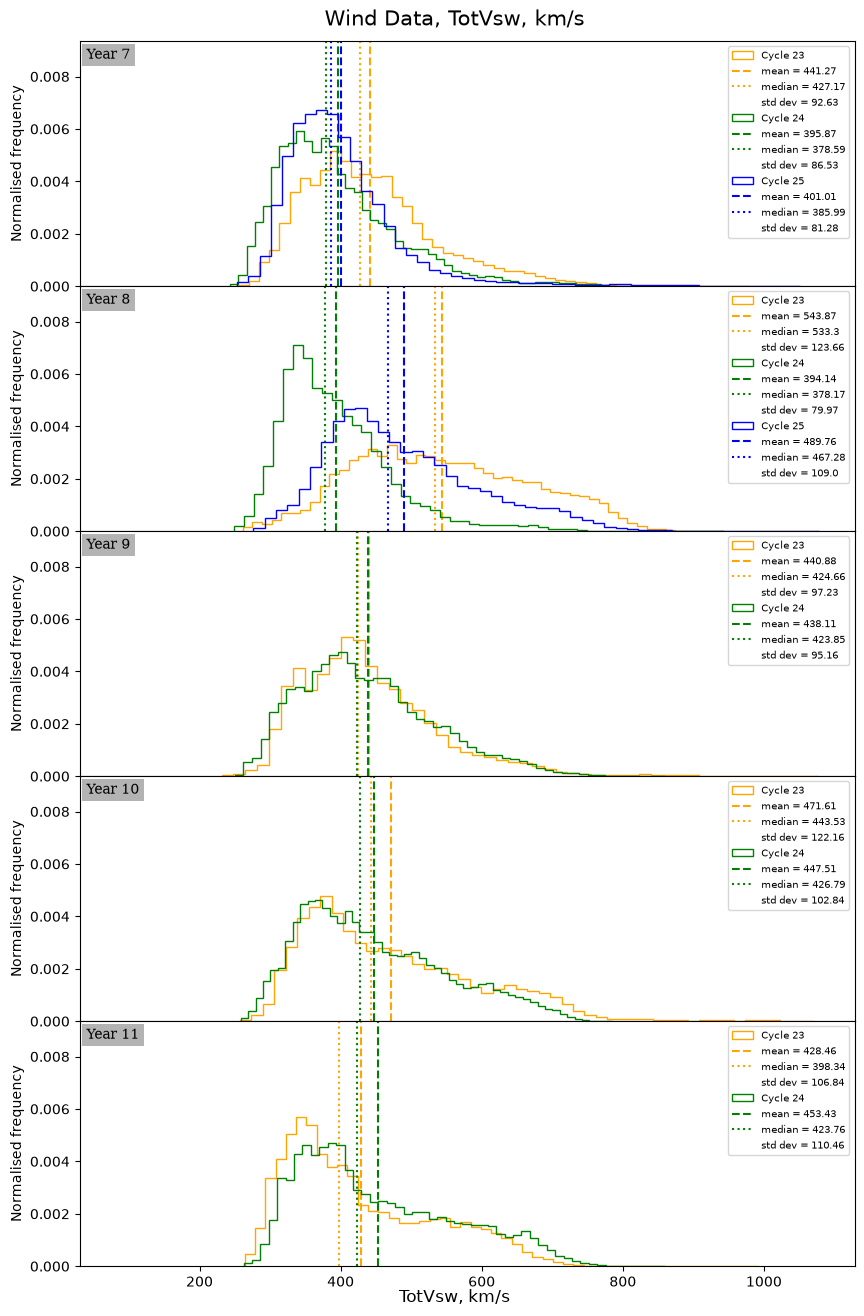

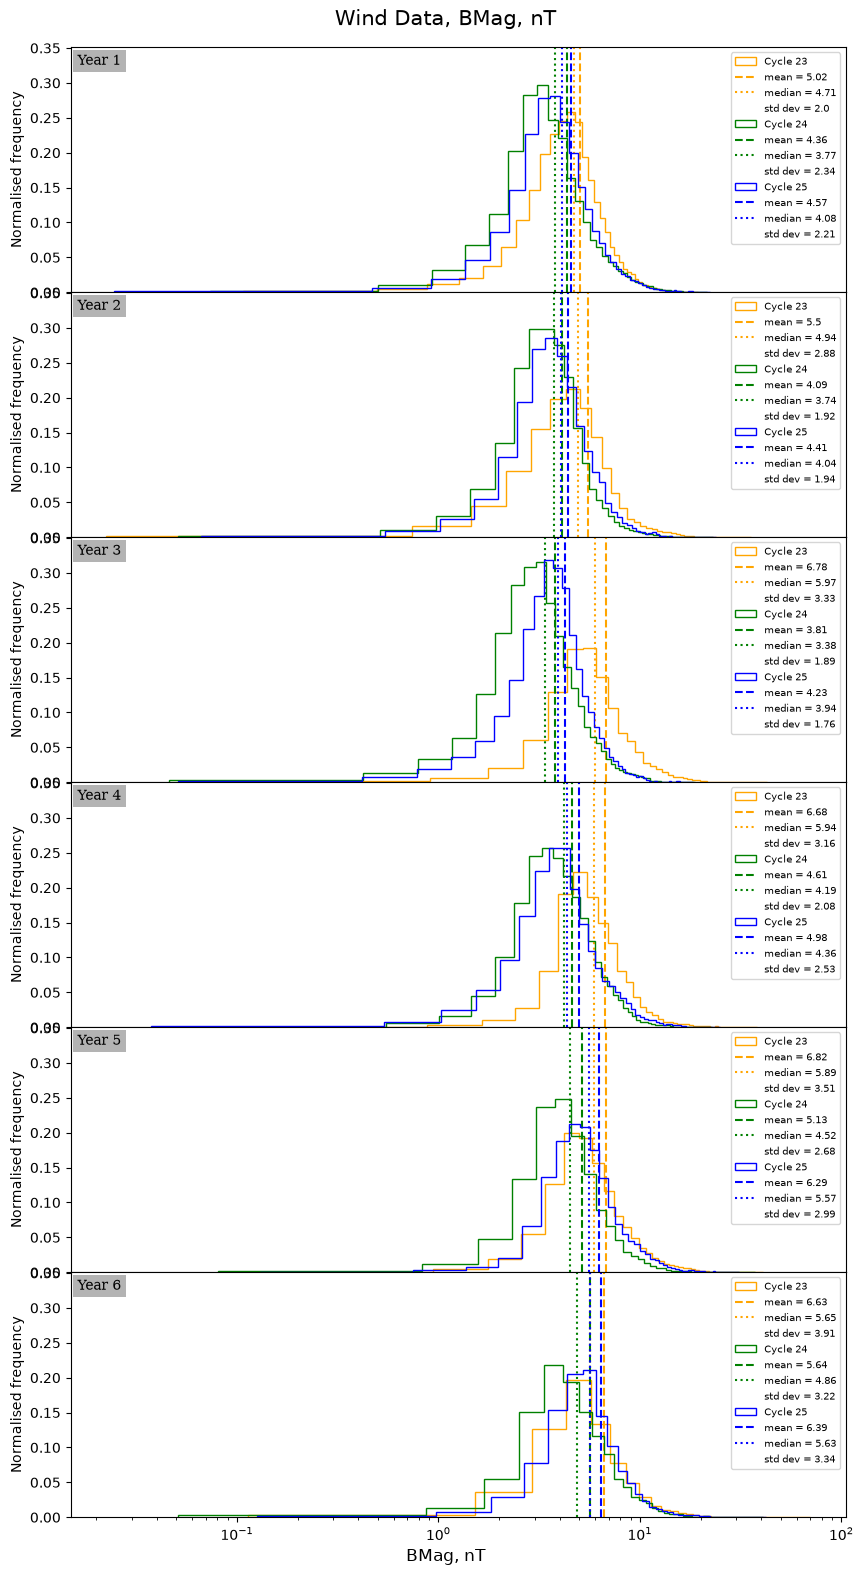

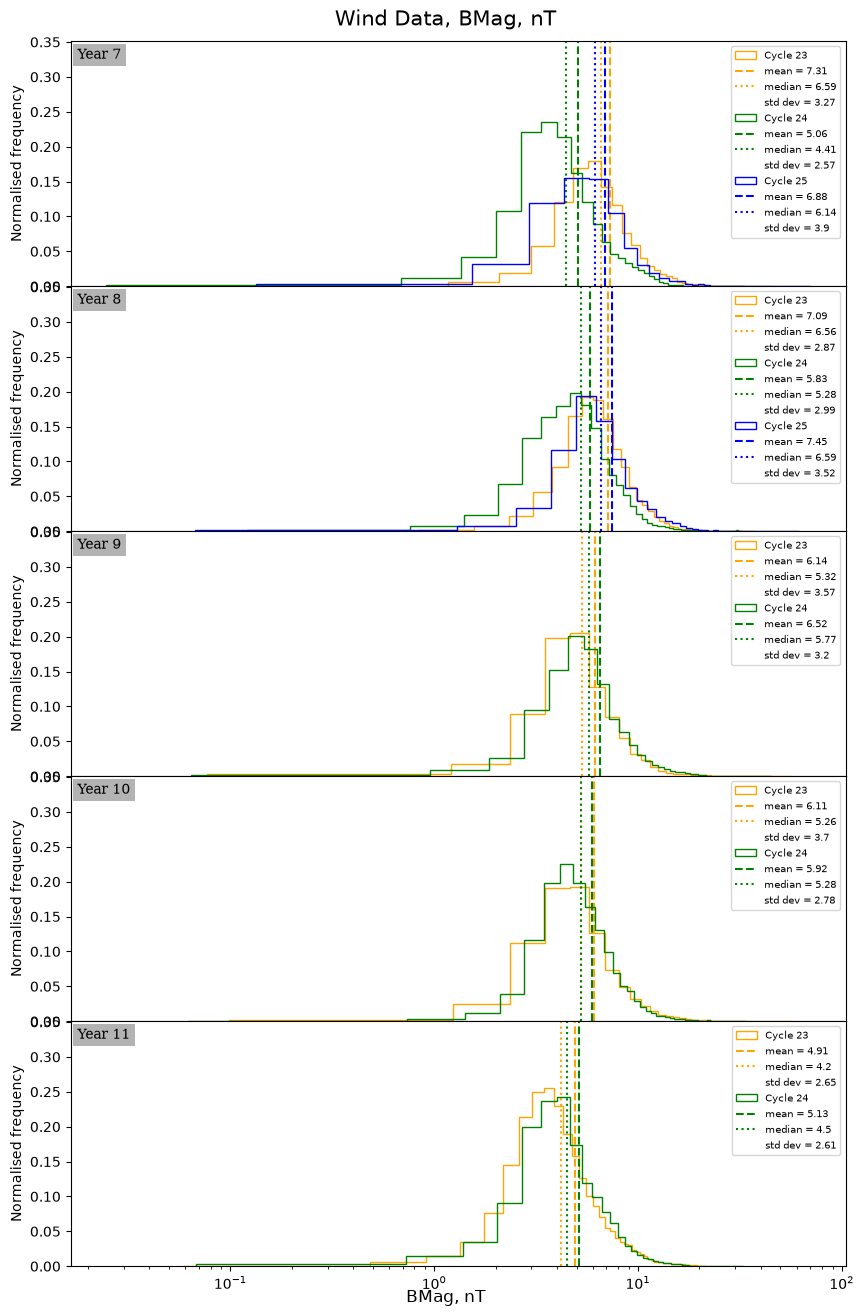

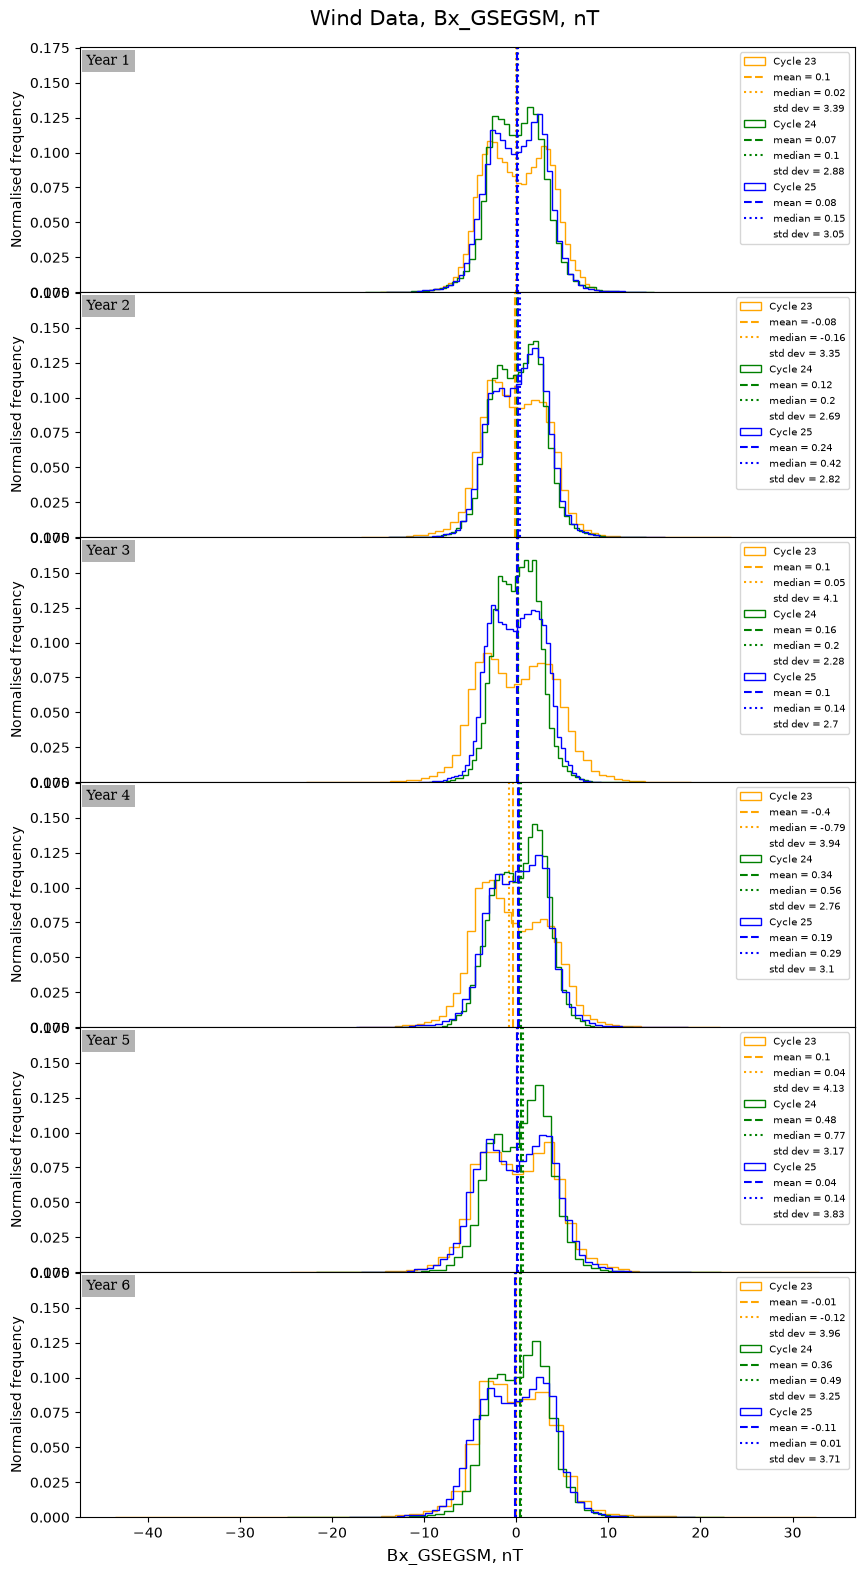

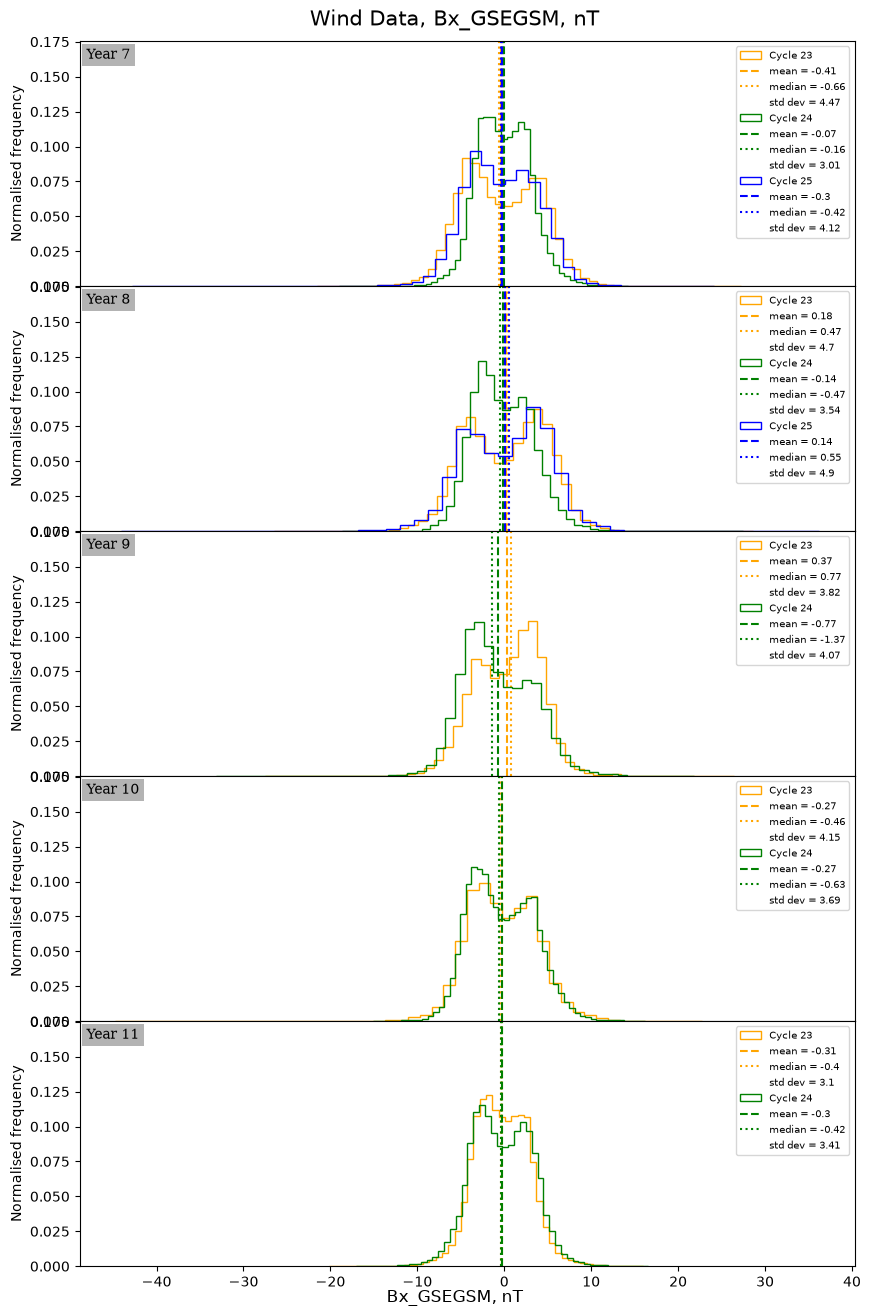

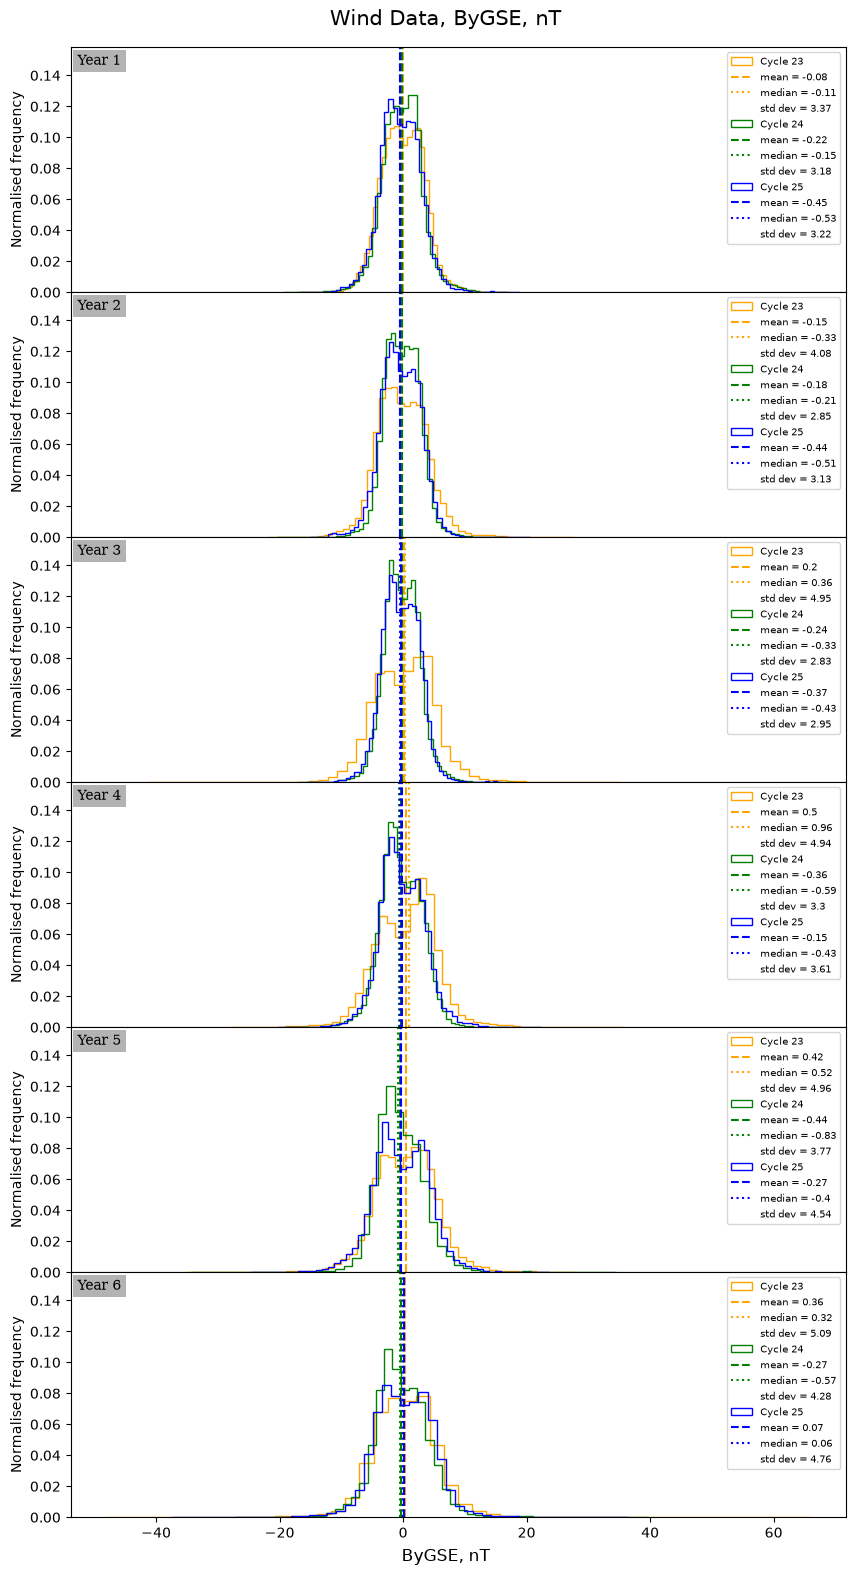

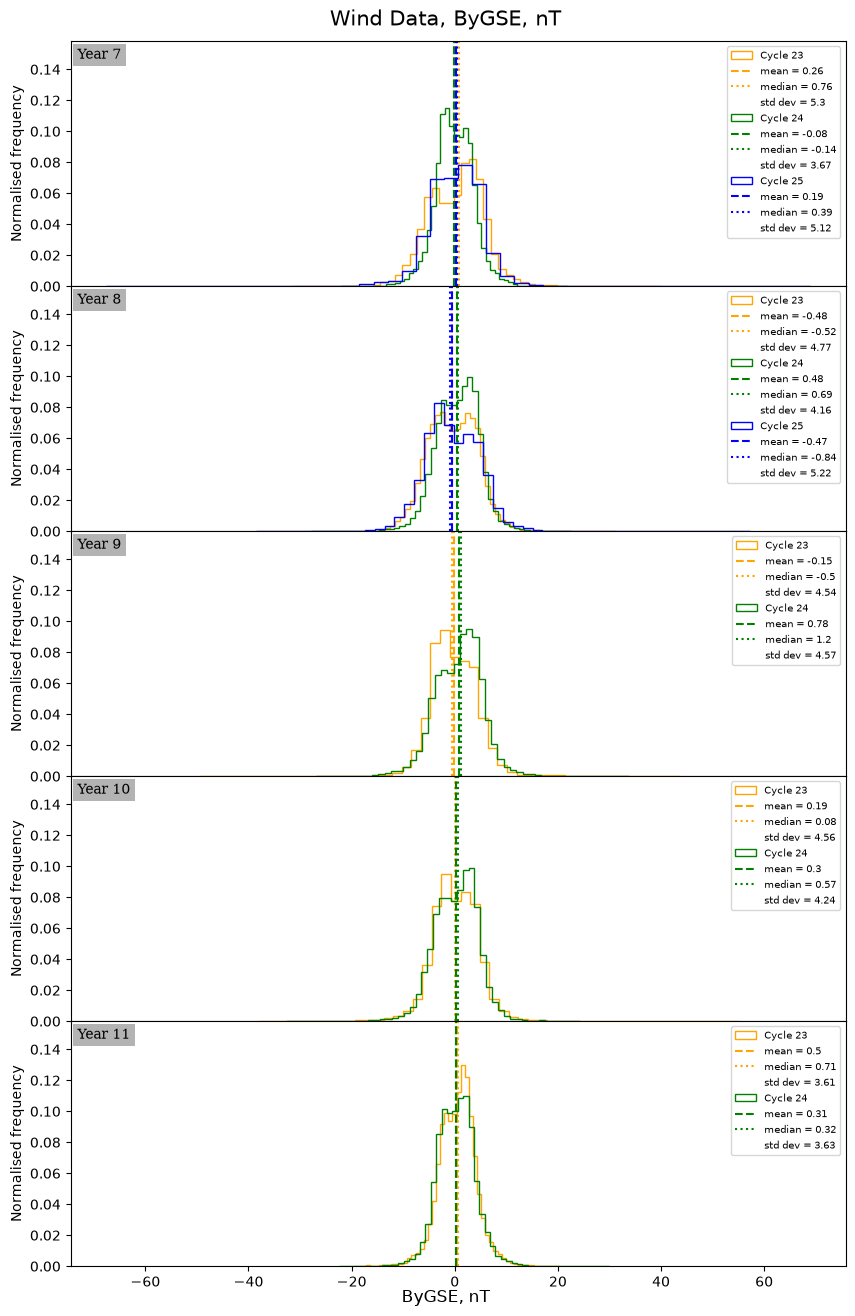

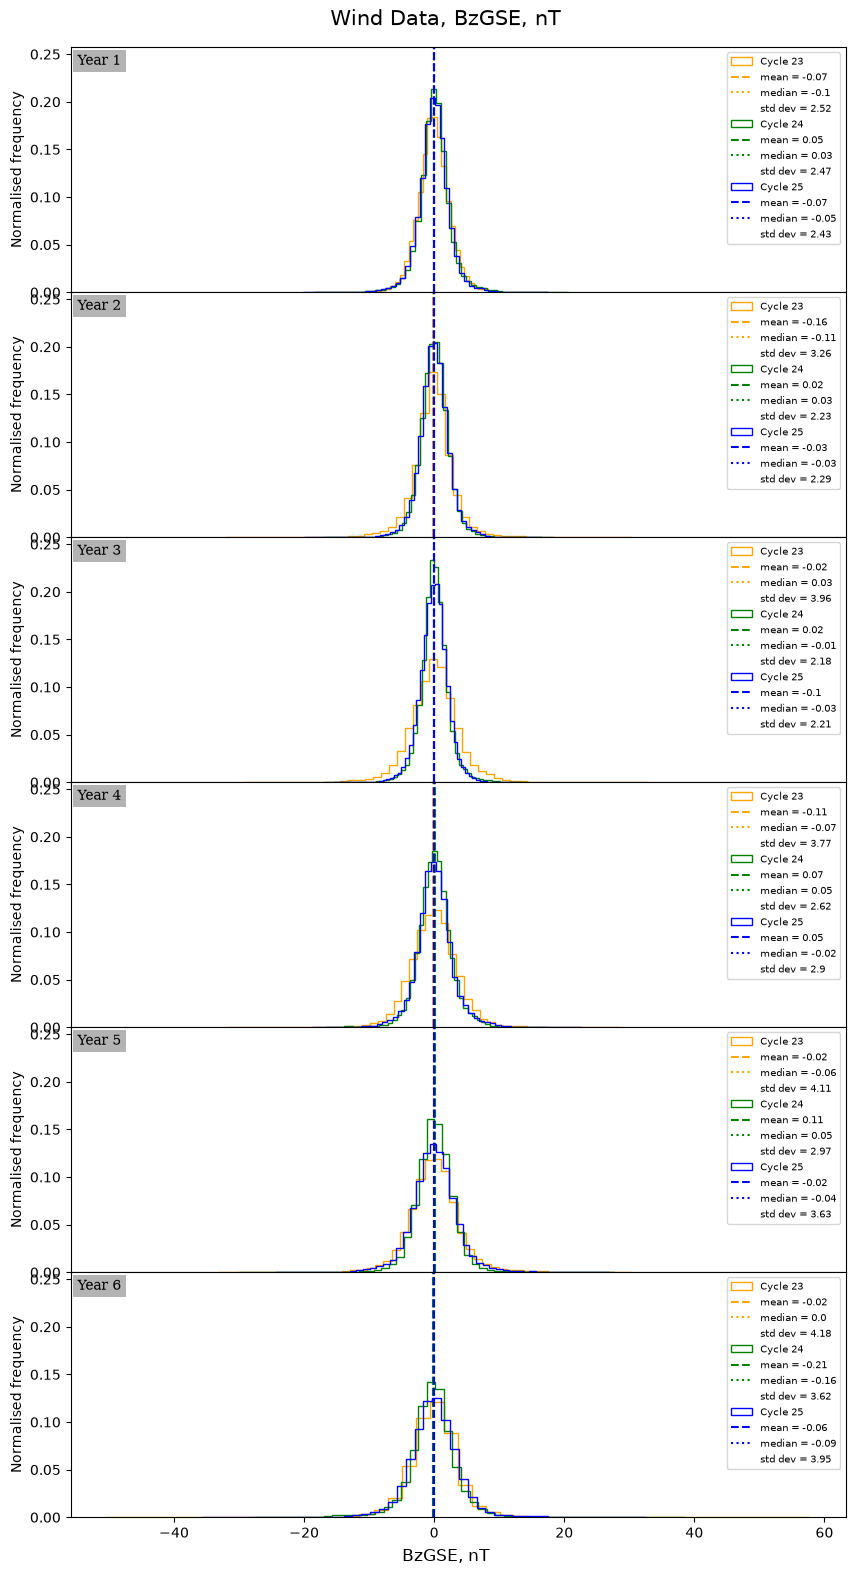

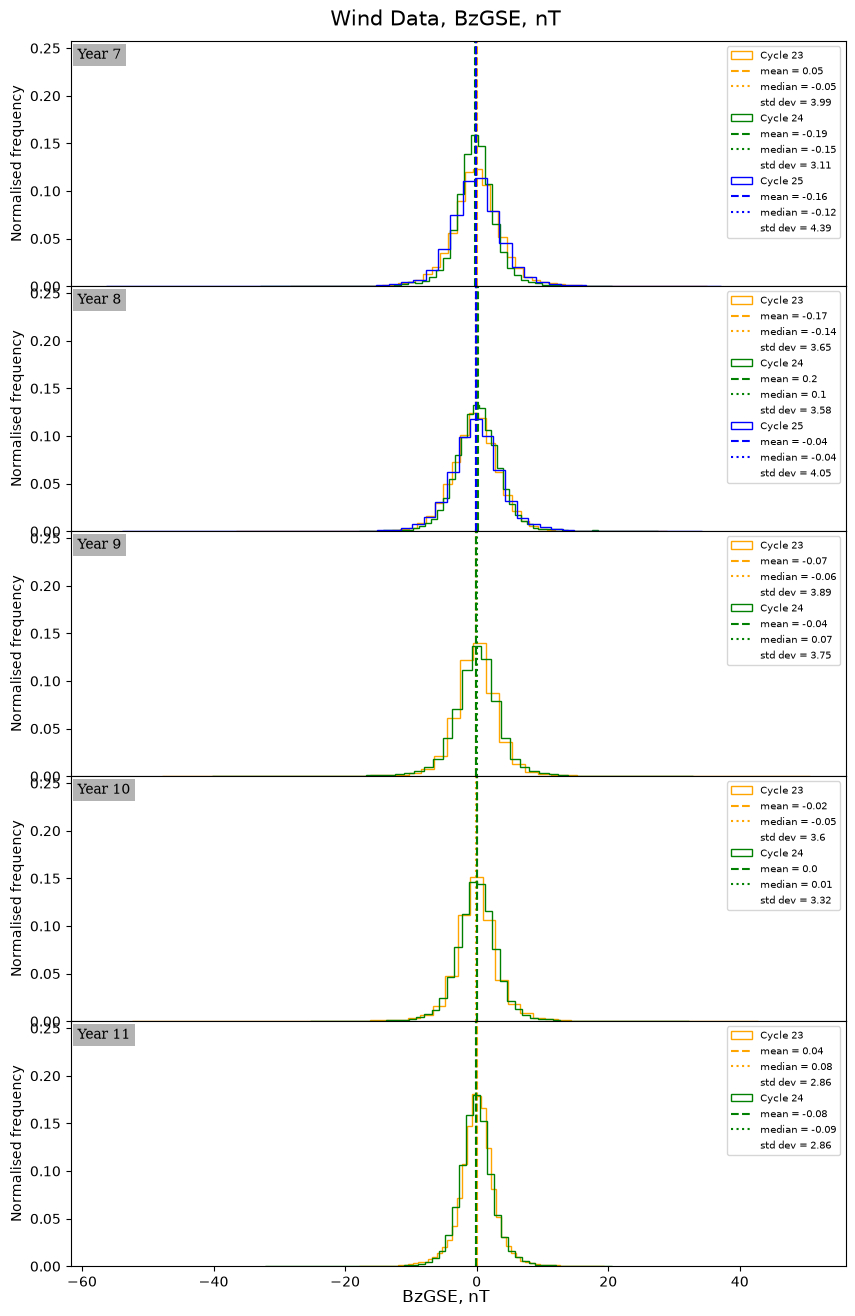

In [46]:
bins = [50, 50, 50, 50, 50]
# bins = [50, 50, 25, 25, 25]

Alpha = 1
SupTitle = 15
Legend = 7.5
figSize = (10, 35) # for 11 plots
# figSize6 = (10, 35 *(6/11)) # for 6 plots
# figSize5 = (10, 35 *(5/11)) # for 5 plots

LegLoc = 'upper right'
titleLoc = 0.9
SpaceLR = [100, 5, 5, 5, 5]
# Colours = ["red", "orange", "green", "blue"]
# Colours = ['pink','brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet','gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink']

    # "Bx_GSEGSM", "ByGSE", "BzGSE"
# dataTimeSerieses = [dataTSFirstDatesC23Min, dataTSFirstDatesC23Max, dataTSFirstDatesC24Min, dataTSFirstDatesC24Max]
Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
XAxisScale = ["linear", "log", "linear", "linear", "linear"]#, "nT"]
YAxisScale = ["linear", "linear", "linear", "linear", "linear"]#, "nT"]
# YAxisScale = ["linear", "log", "log", "log", "log"]
# YAxisScale = ["linear", "linear", "linear", "linear", "linear"]
# XAxisScale = ["linear", "log", "log", "log", "log"]#, "nT"]
# Plotting = ["TotVsw", "LogB", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
# Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
# StartAndEnd = [[startDateC23Min, endDateC23Min], [startDateC23Max, endDateC23Max], [startDateC24Min, endDateC24Min], [startDateC23Max, endDateC23Max]]
noOfYears = 11

# Cycle23 = dfToSeries(Cycle23)
# Cycle24 = dfToSeries(Cycle24)
# Cycle25 = dfToSeries(Cycle25)

yScaleLim, xScaleMaxLim, xScaleMinLim, MeansTS1, MeansTS2, MeansTS3, MediansTS1, MediansTS2, MediansTS3, StdDevsTS1, StdDevsTS2, StdDevsTS3 = YearOverlapGlobalYAxis(Cycle23, Cycle24, Cycle25, Plotting, figSize, titleLoc, 0, 6, 6, 11, XAxisScale, bins)

# YearOverlap(Cycle23[0:6], Cycle24[0:6], Cycle25[0:6], Plotting, 6, figSize6, titleLoc, 1) #, 0, 6)
# YearOverlap(Cycle23[6:11], Cycle24[6:11], Cycle25[6:8], Plotting, 5, figSize5, titleLoc, 7) #, 6, 11)

In [47]:
print(StartAndEnd[0][0][0:10], StartAndEnd[6][0][0:10], StartAndEnd[6][0][0:10], StartAndEnd[11][0][0:10])


19960101 20020101 20020101 20070101


# Yearly split

In [48]:
# #Plot histograms completely separately - sharing y axis that checks across all years
# def YearOverlapGlobalYAxisSplit(dataTS1, dataTS2, dataTS3, VarsToPlot, FigSize, TitleLoc, start, end, startSplit2, endSplit2, XAxisScale, Bins, yScaleLim, xScaleMaxLim, xScaleMinLim):
    
#     for i in range(len(VarsToPlot)):

#         # maxYInDf11 = 0
#         # maxYInDf21 = 0
#         # maxYInDf31 = 0
#         # maxYInDf12 = 0
#         # maxYInDf22 = 0
#         # maxYInDf32 = 0
#         # for j in range(len(dataTS1)):
#         for j in range(start, end):
#             fig, axs = plt.subplots( (end-start) , 1, figsize=(FigSize[0], FigSize[1]*(end-start)/11), sharex=True)
#             # fig.subplots_adjust(hspace=0)
#             # fig.supxlabel(VarsToPlot[i] + ", " + Units[i], y=0.08)
            


#             y, x, _ = plt.hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'orange', label = "Cycle 23", density = True)
#             # maxInYear = y.max()
#             # if maxInYear > maxYInDf11:
#             #     maxYInDf11 = maxInYear

#             # C23
#             #Mean
#             plt.axvline(dataTS1[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "orange", label="mean = " + str(round(dataTS1[j]._data[VarsToPlot[i]].mean(), 2)))
#             #Median
#             plt.axvline(dataTS1[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "orange", label="median = " + str(round(dataTS1[j]._data[VarsToPlot[i]].median(),2)))
#             #Standard deviation
#             plt.axvline(dataTS1[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS1[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

#             if j < len(dataTS2):
#                 # axs[j].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'green', label = "Cycle 24", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

#                 y, x, _ = plt.hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'green', label = "Cycle 24", density = True)
#                 # maxInYear = y.max()
#                 # if maxInYear > maxYInDf21:
#                 #     maxYInDf21 = maxInYear

#                 # C24
#                 #Mean
#                 plt.axvline(dataTS2[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "green", label="mean = " + str(round(dataTS2[j]._data[VarsToPlot[i]].mean(), 2)))
#                 #Median
#                 plt.axvline(dataTS2[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "green", label="median = " + str(round(dataTS2[j]._data[VarsToPlot[i]].median(), 2)))
#                 #Standard deviation
#                 plt.axvline(dataTS2[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS2[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

#             if j < len(dataTS3):
#                 # axs[j].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'blue', label = "Cycle 25", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

#                 y, x, _ = plt.hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'blue', label = "Cycle 25", density = True)
#                 # maxInYear = y.max()
#                 # if maxInYear > maxYInDf31:
#                 #     maxYInDf31 = maxInYear

#                 # C25
#                 #Mean
#                 plt.axvline(dataTS3[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "blue", label="mean = " + str(round(dataTS3[j]._data[VarsToPlot[i]].mean(), 2)))
#                 #Median
#                 plt.axvline(dataTS3[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "blue", label="median = " + str(round(dataTS3[j]._data[VarsToPlot[i]].median(), 2)))
#                 #Standard deviation
#                 plt.axvline(dataTS3[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS3[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

#             plt.legend(loc = LegLoc, fontsize = Legend)
#             plt.ylabel("Normalised frequency")
#             plt.annotate("Year " + str(j + 1), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))
            
        
#         # fig2, axs2 = plt.subplots( (endSplit2-startSplit2) , 1, figsize=(FigSize[0], FigSize[1]*(endSplit2-startSplit2)/11), sharex=True)
#         # fig2.subplots_adjust(hspace=0)
#         # plt.suptitle("Wind Data, " + VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=0.9)
#         # fig2.supxlabel(VarsToPlot[i] + ", " + Units[i], y=0.085)
#         # plt.xscale(XAxisScale[i])
#         # # subplotLabels = []

#         # for j in range(startSplit2, endSplit2):

#         #     axNo = j-startSplit2

#         #     y, x, _ = axs2[axNo].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'orange', label = "Cycle 23", density = True)
#         #     maxInYear = y.max()
#         #     if maxInYear > maxYInDf12:
#         #         maxYInDf12 = maxInYear

#         #     # C23
#         #     #Mean
#         #     axs2[axNo].axvline(dataTS1[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "orange", label="mean = " + str(round(dataTS1[j]._data[VarsToPlot[i]].mean(), 2)))
#         #     #Median
#         #     axs2[axNo].axvline(dataTS1[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "orange", label="median = " + str(round(dataTS1[j]._data[VarsToPlot[i]].median(),2)))
#         #     #Standard deviation
#         #     axs2[axNo].axvline(dataTS1[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS1[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)


#         #     if j < len(dataTS2):
#         #         y, x, _ = axs2[axNo].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'green', label = "Cycle 24", density = True)
#         #         maxInYear = y.max()
#         #         if maxInYear > maxYInDf22:
#         #             maxYInDf22 = maxInYear

#         #         # C24
#         #         #Mean
#         #         axs2[axNo].axvline(dataTS2[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "green", label="mean = " + str(round(dataTS2[j]._data[VarsToPlot[i]].mean(), 2)))
#         #         #Median
#         #         axs2[axNo].axvline(dataTS2[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "green", label="median = " + str(round(dataTS2[j]._data[VarsToPlot[i]].median(), 2)))
#         #         #Standard deviation
#         #         axs2[axNo].axvline(dataTS2[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS2[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)


#         #     if j < len(dataTS3):
#         #         y, x, _ = axs2[axNo].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'blue', label = "Cycle 25", density = True)
#         #         maxInYear = y.max()
#         #         if maxInYear > maxYInDf32:
#         #             maxYInDf32 = maxInYear

#         #         # C25
#         #         #Mean
#         #         axs2[axNo].axvline(dataTS3[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "blue", label="mean = " + str(round(dataTS3[j]._data[VarsToPlot[i]].mean(), 2)))
#         #         #Median
#         #         axs2[axNo].axvline(dataTS3[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "blue", label="median = " + str(round(dataTS3[j]._data[VarsToPlot[i]].median(), 2)))
#         #         #Standard deviation
#         #         axs2[axNo].axvline(dataTS3[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS3[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

#         # # for j in range(len(NoOfYears)):
#         #     axs2[axNo].legend(loc = LegLoc, fontsize = Legend)
#         #     axs2[axNo].set_ylabel("Normalised frequency")

#         #     axs2[axNo].annotate("Year " + str(j+1), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))

#         # maxYsInDfs = [maxYInDf11, maxYInDf21, maxYInDf31, maxYInDf12, maxYInDf22, maxYInDf32]
#         # maxYOverall = max(maxYsInDfs)
        
#         # for j in range(startSplit1, endSplit1):
#             plt.ylim(0, yScaleLim[i]*1.1) # adding 10% to y axis lim
#             plt.xlim(xScaleMinLim[i], xScaleMaxLim[i]) # x axis lim
#             # plt.suptitle("Wind Data, " + VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=TitleLoc)
#             plt.xscale(XAxisScale[i])
#         # for j in range(startSplit2, endSplit2):
#         #     axNo = j-startSplit2
#         #     axs2[axNo].set_ylim(0, maxYOverall*1.1) # adding 10% to y axis lim
        
#         # fig.savefig(PlotDirectory + StartAndEnd[startSplit1][0][0:10] + "->" + StartAndEnd[endSplit1][1][0:10] + VarsToPlot[i] + "FirstHalf_Wind.png")
#         # fig2.savefig(PlotDirectory + StartAndEnd[startSplit2][0][0:10] + "->" + StartAndEnd[endSplit2][1][0:10] + VarsToPlot[i] + "SecondHalf_Wind.png")

#         plt.show()

In [49]:
# print(xScaleMinLim)

In [50]:
# bins = [50, 50, 50, 50, 50]
# # bins = [50, 50, 25, 25, 25]

# Alpha = 1
# SupTitle = 15
# Legend = 7.5
# figSize = (10, 5) # for 11 plots
# figSize = (10, 35) # for 11 plots
# # figSize6 = (10, 35 *(6/11)) # for 6 plots
# # figSize5 = (10, 35 *(5/11)) # for 5 plots

# LegLoc = 'upper right'
# tLoc = 0.95
# SpaceLR = [100, 5, 5, 5, 5]

#     # "Bx_GSEGSM", "ByGSE", "BzGSE"
# # dataTimeSerieses = [dataTSFirstDatesC23Min, dataTSFirstDatesC23Max, dataTSFirstDatesC24Min, dataTSFirstDatesC24Max]
# Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
# Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
# XAxisScale = ["linear", "log", "linear", "linear", "linear"]#, "nT"]
# YAxisScale = ["linear", "linear", "linear", "linear", "linear"]#, "nT"]
# # YAxisScale = ["linear", "log", "log", "log", "log"]
# # YAxisScale = ["linear", "linear", "linear", "linear", "linear"]
# # XAxisScale = ["linear", "log", "log", "log", "log"]#, "nT"]
# # Plotting = ["TotVsw", "LogB", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
# # Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
# # StartAndEnd = [[startDateC23Min, endDateC23Min], [startDateC23Max, endDateC23Max], [startDateC24Min, endDateC24Min], [startDateC23Max, endDateC23Max]]
# noOfYears = 11

# # Cycle23 = dfToSeries(Cycle23)
# # Cycle24 = dfToSeries(Cycle24)
# # Cycle25 = dfToSeries(Cycle25)

# YearOverlapGlobalYAxisSplit(Cycle23, Cycle24, Cycle25, Plotting, figSize, tLoc, 0, 2, 2, 4, XAxisScale, bins, yScaleLim, xScaleMaxLim, xScaleMinLim)
# # YearOverlap(Cycle23[0:6], Cycle24[0:6], Cycle25[0:6], Plotting, 6, figSize6, titleLoc, 1) #, 0, 6)
# # YearOverlap(Cycle23[6:11], Cycle24[6:11], Cycle25[6:8], Plotting, 5, figSize5, titleLoc, 7) #, 6, 11)

In [51]:
print(MeansTS1, MeansTS2, MeansTS3)

[[ 4.21675322e+02  3.80680237e+02  4.11936836e+02  4.40738266e+02
   4.46033997e+02  4.30980534e+02  4.41272614e+02  5.43865211e+02
   4.40875577e+02  4.71612127e+02  4.28455430e+02]
 [ 5.02255024e+00  5.49710918e+00  6.77850384e+00  6.68247184e+00
   6.81598482e+00  6.62536884e+00  7.31478480e+00  7.08592350e+00
   6.14327932e+00  6.11468595e+00  4.91483129e+00]
 [ 9.90771945e-02 -8.46129590e-02  1.01840518e-01 -3.96535076e-01
   9.67364400e-02 -1.28168331e-02 -4.10863916e-01  1.80276823e-01
   3.69834616e-01 -2.69864044e-01 -3.09629557e-01]
 [-8.35341386e-02 -1.54595966e-01  1.95980233e-01  5.02513121e-01
   4.24546432e-01  3.59685915e-01  2.62995773e-01 -4.79369394e-01
  -1.50373281e-01  1.93647469e-01  5.03239497e-01]
 [-6.77268610e-02 -1.59766874e-01 -2.49364298e-02 -1.05105301e-01
  -1.80291458e-02 -2.07898875e-02  4.54014846e-02 -1.65288628e-01
  -7.19844205e-02 -1.95453166e-02  3.65718208e-02]] [[ 4.41616901e+02  4.51565529e+02  3.63888276e+02  4.03856898e+02
   4.21222717e+02 

# Statistical quantities over time

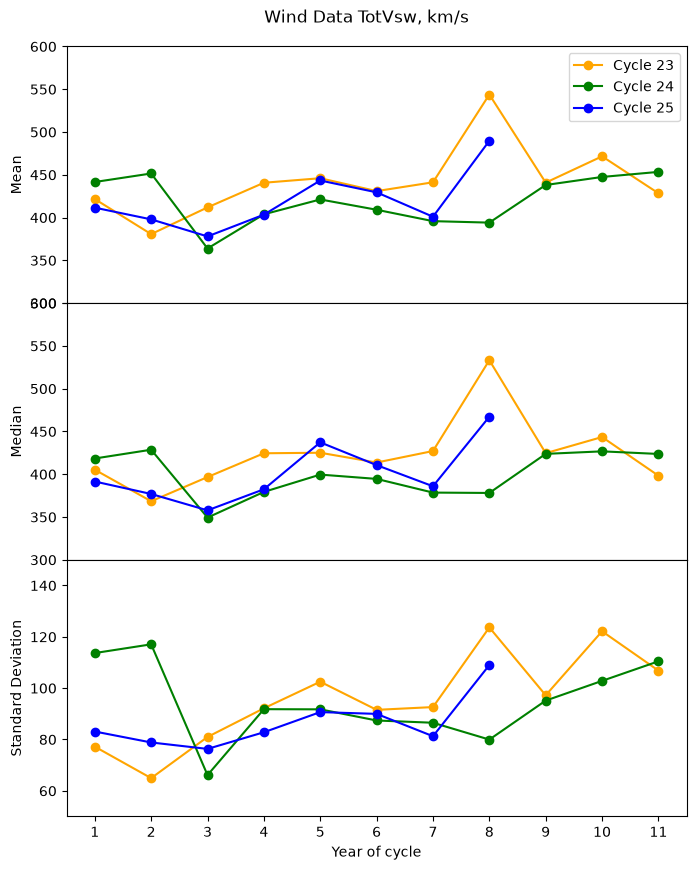

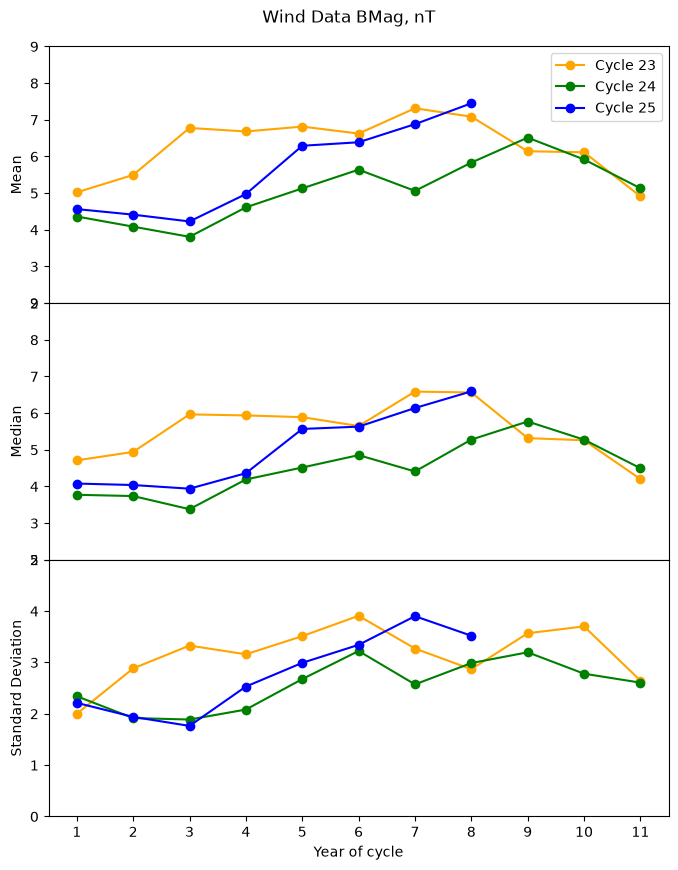

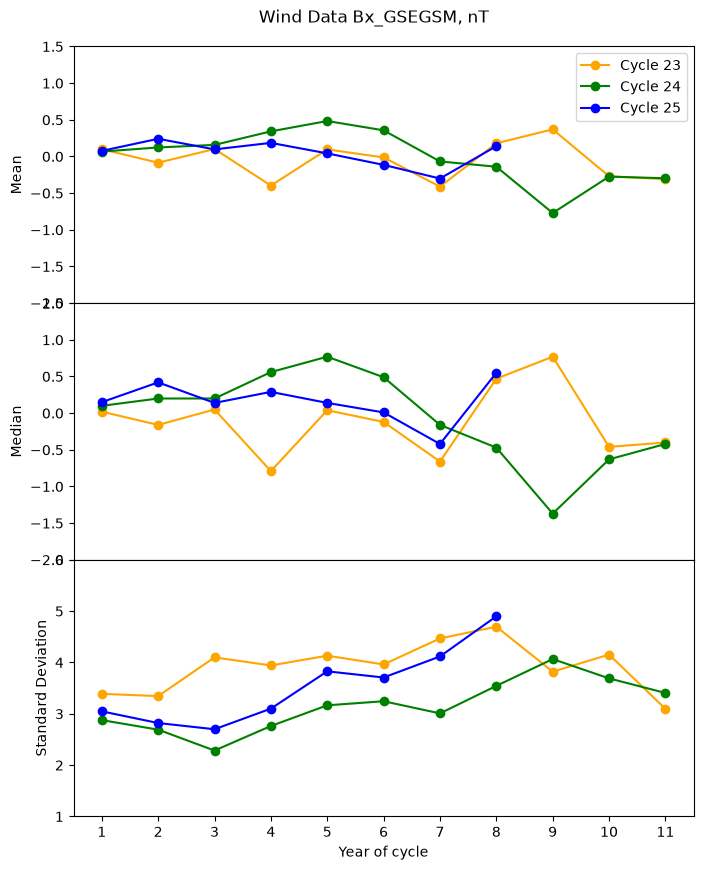

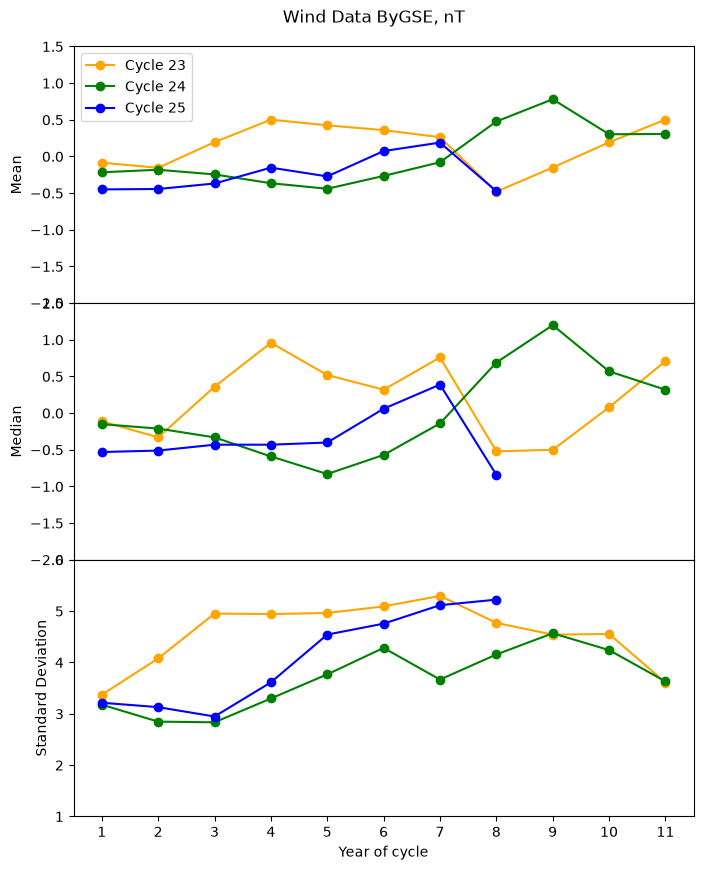

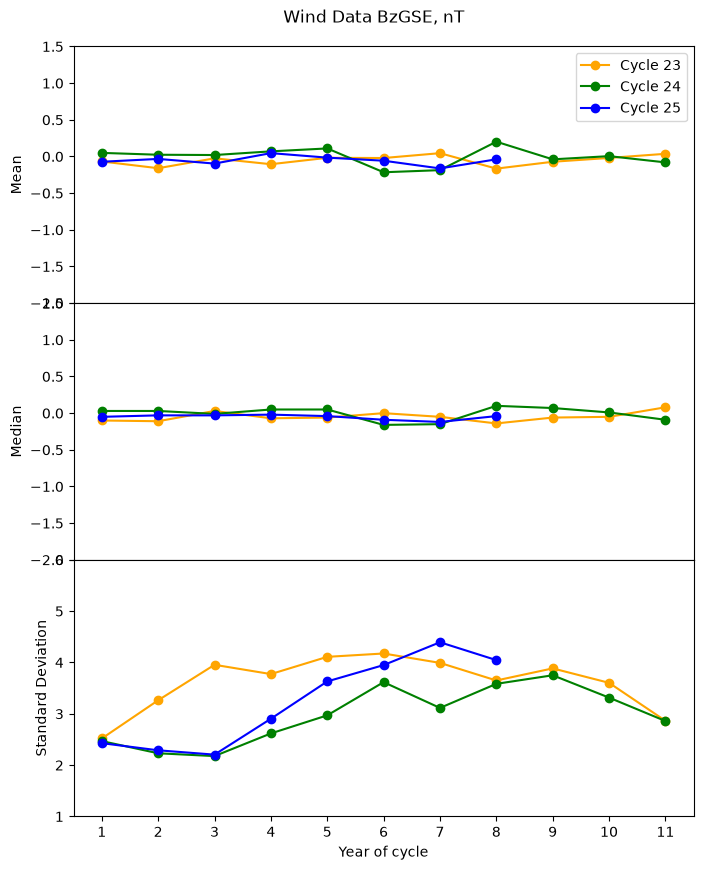

In [52]:
def StatsPlots(YearsArray, MeansTS1, MeansTS2, MeansTS3, MediansTS1, MediansTS2, MediansTS3, StdDevsTS1, StdDevsTS2, StdDevsTS3, FigSize, VarsToPlot, Units, xScaleMinLim, xScaleMaxLim, ManualYLims):
    # plt.suptitle("Solar Wind "+ VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=0.89)
    # subplotLabels = []
    for i in range(len(VarsToPlot)):

        fig, axs = plt.subplots(3,1, figsize=FigSize)#, sharex=True)
        fig.subplots_adjust(hspace=0)
        fig.supxlabel("Wind Data " + VarsToPlot[i] + ", " + Units[i], y=0.9)

        axs[0].plot(YearsArray, MeansTS1[i], label = "Cycle 23", color = "orange", marker = "o")
        axs[0].plot(YearsArray, MeansTS2[i], label = "Cycle 24", color = "green", marker = "o")
        axs[0].plot(YearsArray, MeansTS3[i], label = "Cycle 25", color = "blue", marker = "o")
        axs[0].set_ylabel("Mean")

        axs[1].plot(YearsArray, MediansTS1[i], label = "Cycle 23", color = "orange", marker = "o")
        axs[1].plot(YearsArray, MediansTS2[i], label = "Cycle 24", color = "green", marker = "o")
        axs[1].plot(YearsArray, MediansTS3[i], label = "Cycle 25", color = "blue", marker = "o")
        axs[1].set_ylabel("Median")

        axs[2].plot(YearsArray, StdDevsTS1[i], label = "Cycle 23", color = "orange", marker = "o")
        axs[2].plot(YearsArray, StdDevsTS2[i], label = "Cycle 24", color = "green", marker = "o")
        axs[2].plot(YearsArray, StdDevsTS3[i], label = "Cycle 25", color = "blue", marker = "o")
        axs[2].set_ylabel("Standard Deviation")
        axs[0].legend()
        # plt.title(VarsToPlot[i], Uni, y =3)
        plt.xlabel("Year of cycle")
        plt.xticks(np.arange(0, 11, 1), np.arange(1, 12, 1))

        # axs[0].set_ylim(xScaleMinLim[i], xScaleMaxLim[i]) # using original limits which include v high and low values, not great for seeing mean/median/std which tend to be mid values not extremes
        # axs[1].set_ylim(xScaleMinLim[i], xScaleMaxLim[i])
        # axs[2].set_ylim(xScaleMinLim[i], xScaleMaxLim[i])
        axs[0].set_ylim(ManualYLims[i][0]) # Manually chosen values
        axs[1].set_ylim(ManualYLims[i][1])
        axs[2].set_ylim(ManualYLims[i][2])

        plt.savefig("Plots/WindYearlyPlots/" + VarsToPlot[i] + "StatPlots.png")


# MeansTS1, MeansTS2, MeansTS3, MediansTS1, MediansTS2, MediansTS3, StdDevsTS1, StdDevsTS2, StdDevsTS3

Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
ManualYLims = [[[300,600], [300,600], [50,150]],
               [[2, 9], [2,9], [0,5]],
               [[-2,1.5], [-2,1.5], [1,6]],
               [[-2,1.5], [-2,1.5], [1,6]],
               [[-2,1.5], [-2,1.5], [1,6]]]


figSizeStats = [8,10]
yearsArray = np.arange(0, 11, 1)
StatsPlots(yearsArray, MeansTS1, MeansTS2, MeansTS3, MediansTS1, MediansTS2, MediansTS3, StdDevsTS1, StdDevsTS2, StdDevsTS3, figSizeStats, Plotting, Units, xScaleMinLim, xScaleMaxLim, ManualYLims)

In [53]:
#Plot histograms with a split - sharing y axis that checks across all years
def YearOverlapGlobalYAxisWithFitting(dataTS1, dataTS2, dataTS3, VarsToPlot, FigSize, TitleLoc, startSplit1, endSplit1, startSplit2, endSplit2, XAxisScale, Bins, FittingBool):

    maxYOverall = []
    yScaleLim = []
    XScaleMaxLim = []
    XScaleMinLim = []

    meansTS1 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))
    mediansTS1 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))
    stdDevsTS1 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))

    meansTS2 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))
    mediansTS2 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))
    stdDevsTS2 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))

    meansTS3 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))
    mediansTS3 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))
    stdDevsTS3 = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))

    meansTS1[:] = np.nan
    mediansTS1[:] = np.nan
    stdDevsTS1[:] = np.nan
    meansTS2[:] = np.nan
    mediansTS2[:] = np.nan
    stdDevsTS2[:] = np.nan
    meansTS3[:] = np.nan
    mediansTS3[:] = np.nan
    stdDevsTS3[:] = np.nan

    statsResult = np.empty((len(VarsToPlot),(endSplit2-startSplit1)))
    statsResult[:] = np.nan
    
    for i in range(len(VarsToPlot)):

        fig, axs = plt.subplots( (endSplit1-startSplit1) , 1, figsize=(FigSize[0], FigSize[1]*(endSplit1-startSplit1)/11), sharex=True)
        fig.subplots_adjust(hspace=0)
        plt.suptitle("Wind Data, " + VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=TitleLoc)
        fig.supxlabel(VarsToPlot[i] + ", " + Units[i], y=0.085)
        plt.xscale(XAxisScale[i])
        # subplotLabels = []

        maxYInDf11 = 0
        maxYInDf21 = 0
        maxYInDf31 = 0
        maxYInDf12 = 0
        maxYInDf22 = 0
        maxYInDf32 = 0

        maxXInDf11 = 0
        maxXInDf21 = 0
        maxXInDf31 = 0
        maxXInDf12 = 0
        maxXInDf22 = 0
        maxXInDf32 = 0

        minXInDf11 = 0
        minXInDf21 = 0
        minXInDf31 = 0
        minXInDf12 = 0
        minXInDf22 = 0
        minXInDf32 = 0

        # for j in range(len(dataTS1)):
        for j in range(startSplit1, endSplit1):

            # axs[j].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'orange', label = "Cycle 23", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

            y, x, _ = axs[j].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'orange', label = "Cycle 23", density = True)
            maxInYear = y.max()
            if maxInYear > maxYInDf11:
                maxYInDf11 = maxInYear

            maxXInYear = x.max()
            if maxXInYear > maxXInDf11:
                maxXInDf11 = maxXInYear

            minXInYear = x.min()
            if minXInYear < minXInDf11:
                minXInDf11 = minXInYear

            # C23
            #Mean
            axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "orange", label="mean = " + str(round(dataTS1[j]._data[VarsToPlot[i]].mean(), 2)))
            #Median
            axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "orange", label="median = " + str(round(dataTS1[j]._data[VarsToPlot[i]].median(),2)))
            #Standard deviation
            axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS1[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

            meansTS1[i][j] = dataTS1[j]._data[VarsToPlot[i]].mean()
            print(meansTS1[i][j])
            mediansTS1[i][j] = dataTS1[j]._data[VarsToPlot[i]].median()
            stdDevsTS1[i][j] = dataTS1[j]._data[VarsToPlot[i]].std()

            # Fitting
            # data = dataTS1[j]._data[VarsToPlot[i]]
            import scipy.stats as stats
            # dataFit = dataTS1[j]._data[VarsToPlot[i]]
            # meanFit = dataTS1[j]._data[VarsToPlot[i]].mean()
            # stdDevsFit = dataTS1[j]._data[VarsToPlot[i]].std()
            axs[j].plot(np.sort(dataTS1[j]._data[VarsToPlot[i]]), stats.norm.pdf(np.sort(dataTS1[j]._data[VarsToPlot[i]]), meansTS1[i][j], stdDevsTS1[i][j]), color = "orange")
            # from scipy.stats import anderson
            # statsResult[i][j] = anderson(np.sort(dataTS1[j]._data[VarsToPlot[i]]), dist = 'norm', method = 'interpolate').pvalue


            if j < len(dataTS2):
                # axs[j].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'green', label = "Cycle 24", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

                y, x, _ = axs[j].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'green', label = "Cycle 24", density = True)
                maxInYear = y.max()
                if maxInYear > maxYInDf21:
                    maxYInDf21 = maxInYear

                maxXInYear = x.max()
                if maxXInYear > maxXInDf21:
                    maxXInDf21 = maxXInYear

                minXInYear = x.min()
                if minXInYear < minXInDf21:
                    minXInDf21 = minXInYear

                # C24
                #Mean
                axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "green", label="mean = " + str(round(dataTS2[j]._data[VarsToPlot[i]].mean(), 2)))
                #Median
                axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "green", label="median = " + str(round(dataTS2[j]._data[VarsToPlot[i]].median(), 2)))
                #Standard deviation
                axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS2[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

                meansTS2[i][j] = dataTS2[j]._data[VarsToPlot[i]].mean()
                mediansTS2[i][j] = dataTS2[j]._data[VarsToPlot[i]].median()
                stdDevsTS2[i][j] = dataTS2[j]._data[VarsToPlot[i]].std()

                # Fitting
                # data = dataTS1[j]._data[VarsToPlot[i]]
                import scipy.stats as stats
                # dataFit = dataTS1[j]._data[VarsToPlot[i]]
                # meanFit = dataTS1[j]._data[VarsToPlot[i]].mean()
                # stdDevsFit = dataTS1[j]._data[VarsToPlot[i]].std()
                axs[j].plot(np.sort(dataTS2[j]._data[VarsToPlot[i]]), stats.norm.pdf(np.sort(dataTS2[j]._data[VarsToPlot[i]]), meansTS2[i][j], stdDevsTS2[i][j]), color = "green")
                # from scipy.stats import anderson
                # statsResult[i][j] = anderson(np.sort(dataTS1[j]._data[VarsToPlot[i]]), dist = 'norm', method = 'interpolate').pvalue

            if j < len(dataTS3):
                # axs[j].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'blue', label = "Cycle 25", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

                y, x, _ = axs[j].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'blue', label = "Cycle 25", density = True)
                maxInYear = y.max()
                if maxInYear > maxYInDf31:
                    maxYInDf31 = maxInYear

                maxXInYear = x.max()
                if maxXInYear > maxXInDf31:
                    maxXInDf31 = maxXInYear

                minXInYear = x.min()
                if minXInYear < minXInDf31:
                    minXInDf31 = minXInYear

                # C25
                #Mean
                axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "blue", label="mean = " + str(round(dataTS3[j]._data[VarsToPlot[i]].mean(), 2)))
                #Median
                axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "blue", label="median = " + str(round(dataTS3[j]._data[VarsToPlot[i]].median(), 2)))
                #Standard deviation
                axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS3[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

                meansTS3[i][j] = dataTS3[j]._data[VarsToPlot[i]].mean()
                mediansTS3[i][j] = dataTS3[j]._data[VarsToPlot[i]].median()
                stdDevsTS3[i][j] = dataTS3[j]._data[VarsToPlot[i]].std()

                # Fitting
                # data = dataTS1[j]._data[VarsToPlot[i]]
                import scipy.stats as stats
                # dataFit = dataTS1[j]._data[VarsToPlot[i]]
                # meanFit = dataTS1[j]._data[VarsToPlot[i]].mean()
                # stdDevsFit = dataTS1[j]._data[VarsToPlot[i]].std()
                axs[j].plot(np.sort(dataTS3[j]._data[VarsToPlot[i]]), stats.norm.pdf(np.sort(dataTS3[j]._data[VarsToPlot[i]]), meansTS3[i][j], stdDevsTS3[i][j]), color = "blue")
                # from scipy.stats import anderson
                # statsResult[i][j] = anderson(np.sort(dataTS1[j]._data[VarsToPlot[i]]), dist = 'norm', method = 'interpolate').pvalue

        # for j in range(len(NoOfYears)):
        #     if j < len(dataTS):
            axs[j].legend(loc = LegLoc, fontsize = Legend)
            axs[j].set_ylabel("Normalised frequency")

            # subplotLabels.append("Year" + str(j))
            axs[j].annotate("Year " + str(j + 1), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))
            # axs[j].annotate(str(StartAndEnd[j][0][0:4]), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))

            # fig, axs = plt.subplot_mosaic([['a)', 'c)'], ['b)', 'c)'], ['d)', 'd)']], layout='constrained')
            # for label, ax in axs.items():
            #     ax.annotate(label, xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))

        # maxYInDf1 = 0
        # for k in range(len(dataTS1)): # For each daterange
        #     maxInYear = max(dataTS1[k]._data[VarsToPlot[i]])

        #     if maxInYear > maxYInDf1:
        #         maxYInDf1 = maxInYear

        # maxYInDf2 = 0
        # for l in range(len(dataTS2)): # For each daterange
        #     maxInYear = max(dataTS2[l]._data[VarsToPlot[i]])
            
        #     if maxInYear > maxYInDf2:
        #         maxYInDf2 = maxInYear

        # maxYInDf3 = 0
        # for m in range(len(dataTS3)): # For each daterange
        #     maxInYear = max(dataTS3[m]._data[VarsToPlot[i]])
            
        #     if maxInYear > maxYInDf3:
        #         maxYInDf3 = maxInYear
            
        
        fig2, axs2 = plt.subplots( (endSplit2-startSplit2) , 1, figsize=(FigSize[0], FigSize[1]*(endSplit2-startSplit2)/11), sharex=True)
        fig2.subplots_adjust(hspace=0)
        plt.suptitle("Wind Data, " + VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=0.9)
        fig2.supxlabel(VarsToPlot[i] + ", " + Units[i], y=0.085)
        plt.xscale(XAxisScale[i])
        # subplotLabels = []

        for j in range(startSplit2, endSplit2):

            # fig, axs = plt.subplots( (endSplit2-startSplit2) , 1, figsize=FigSize, sharex=True)
            # fig.subplots_adjust(hspace=0)
            # # plt.suptitle("Solar Wind "+ VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=0.89)
            # fig.supxlabel("Wind Data" + VarsToPlot[i] + ", " + Units[i], y=TitleLoc)
            # # subplotLabels = []

            axNo = j-startSplit2

            # axs[j].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'orange', label = "Cycle 23", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

            y, x, _ = axs2[axNo].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'orange', label = "Cycle 23", density = True)
            maxInYear = y.max()
            if maxInYear > maxYInDf12:
                maxYInDf12 = maxInYear

            maxXInYear = x.max()
            if maxXInYear > maxXInDf12:
                maxXInDf12 = maxXInYear

            minXInYear = x.min()
            if minXInYear < minXInDf12:
                minXInDf12 = minXInYear

            # C23
            #Mean
            axs2[axNo].axvline(dataTS1[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "orange", label="mean = " + str(round(dataTS1[j]._data[VarsToPlot[i]].mean(), 2)))
            #Median
            axs2[axNo].axvline(dataTS1[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "orange", label="median = " + str(round(dataTS1[j]._data[VarsToPlot[i]].median(),2)))
            #Standard deviation
            axs2[axNo].axvline(dataTS1[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS1[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

            meansTS1[i][j] = dataTS1[j]._data[VarsToPlot[i]].mean()
            mediansTS1[i][j] = dataTS1[j]._data[VarsToPlot[i]].median()
            stdDevsTS1[i][j] = dataTS1[j]._data[VarsToPlot[i]].std()

            # Fitting
            # data = dataTS1[j]._data[VarsToPlot[i]]
            import scipy.stats as stats
            # dataFit = dataTS1[j]._data[VarsToPlot[i]]
            # meanFit = dataTS1[j]._data[VarsToPlot[i]].mean()
            # stdDevsFit = dataTS1[j]._data[VarsToPlot[i]].std()
            axs2[axNo].plot(np.sort(dataTS1[j]._data[VarsToPlot[i]]), stats.norm.pdf(np.sort(dataTS1[j]._data[VarsToPlot[i]]), meansTS1[i][j], stdDevsTS1[i][j]), color = "orange")
            from scipy.stats import anderson
            results = anderson(np.sort(dataTS1[j]._data[VarsToPlot[i]]), dist = 'norm', method = 'interpolate')
            statsResult[i][j] = results.statistic

            
            if j < len(dataTS2):
                # axs[axNo].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'green', label = "Cycle 24", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

                y, x, _ = axs2[axNo].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'green', label = "Cycle 24", density = True)
                maxInYear = y.max()
                if maxInYear > maxYInDf22:
                    maxYInDf22 = maxInYear

                maxXInYear = x.max()
                if maxXInYear > maxXInDf22:
                    maxXInDf22 = maxXInYear

                minXInYear = x.min()
                if minXInYear < minXInDf22:
                    minXInDf22 = minXInYear

                # C24
                #Mean
                axs2[axNo].axvline(dataTS2[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "green", label="mean = " + str(round(dataTS2[j]._data[VarsToPlot[i]].mean(), 2)))
                #Median
                axs2[axNo].axvline(dataTS2[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "green", label="median = " + str(round(dataTS2[j]._data[VarsToPlot[i]].median(), 2)))
                #Standard deviation
                axs2[axNo].axvline(dataTS2[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS2[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

                meansTS2[i][j] = dataTS2[j]._data[VarsToPlot[i]].mean()
                mediansTS2[i][j] = dataTS2[j]._data[VarsToPlot[i]].median()
                stdDevsTS2[i][j] = dataTS2[j]._data[VarsToPlot[i]].std()

                # Fitting
                # data = dataTS1[j]._data[VarsToPlot[i]]
                import scipy.stats as stats
                # dataFit = dataTS1[j]._data[VarsToPlot[i]]
                # meanFit = dataTS1[j]._data[VarsToPlot[i]].mean()
                # stdDevsFit = dataTS1[j]._data[VarsToPlot[i]].std()
                axs2[axNo].plot(np.sort(dataTS2[j]._data[VarsToPlot[i]]), stats.norm.pdf(np.sort(dataTS2[j]._data[VarsToPlot[i]]), meansTS2[i][j], stdDevsTS2[i][j]), color = "green")
                # from scipy.stats import anderson
                # statsResult[i][j] = anderson(np.sort(dataTS1[j]._data[VarsToPlot[i]]), dist = 'norm', method = 'interpolate').pvalue

            if j < len(dataTS3):
                # axs[axNo].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'blue', label = "Cycle 25", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

                y, x, _ = axs2[axNo].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bins[i], histtype='step', color = 'blue', label = "Cycle 25", density = True)
                maxInYear = y.max()
                if maxInYear > maxYInDf32:
                    maxYInDf32 = maxInYear

                maxXInYear = x.max()
                if maxXInYear > maxXInDf32:
                    maxXInDf32 = maxXInYear

                minXInYear = x.min()
                if minXInYear < minXInDf32:
                    minXInDf32 = minXInYear

                # C25
                #Mean
                axs2[axNo].axvline(dataTS3[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "blue", label="mean = " + str(round(dataTS3[j]._data[VarsToPlot[i]].mean(), 2)))
                #Median
                axs2[axNo].axvline(dataTS3[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "blue", label="median = " + str(round(dataTS3[j]._data[VarsToPlot[i]].median(), 2)))
                #Standard deviation
                axs2[axNo].axvline(dataTS3[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS3[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

                meansTS3[i][j] = dataTS3[j]._data[VarsToPlot[i]].mean()
                mediansTS3[i][j] = dataTS3[j]._data[VarsToPlot[i]].median()
                stdDevsTS3[i][j] = dataTS3[j]._data[VarsToPlot[i]].std()

                # Fitting
                # data = dataTS1[j]._data[VarsToPlot[i]]
                import scipy.stats as stats
                # dataFit = dataTS1[j]._data[VarsToPlot[i]]
                # meanFit = dataTS1[j]._data[VarsToPlot[i]].mean()
                # stdDevsFit = dataTS1[j]._data[VarsToPlot[i]].std()
                axs2[axNo].plot(np.sort(dataTS3[j]._data[VarsToPlot[i]]), stats.norm.pdf(np.sort(dataTS3[j]._data[VarsToPlot[i]]), meansTS3[i][j], stdDevsTS3[i][j]), color = "blue")
                # from scipy.stats import anderson
                # statsResult[i][j] = anderson(np.sort(dataTS1[j]._data[VarsToPlot[i]]), dist = 'norm', method = 'interpolate').pvalue
                
        # for j in range(len(NoOfYears)):
        #     if j < len(dataTS):
            axs2[axNo].legend(loc = LegLoc, fontsize = Legend)
            axs2[axNo].set_ylabel("Normalised frequency")

            # subplotLabels.append("Year" + str(j))
            axs2[axNo].annotate("Year " + str(j+1), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))
            # axs2[axNo].annotate(str(StartAndEnd[j][0][0:4]), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))

        maxYsInDfs = [maxYInDf11, maxYInDf21, maxYInDf31, maxYInDf12, maxYInDf22, maxYInDf32]
        maxYOverall = max(maxYsInDfs)
        yScaleLim.append(maxYOverall)

        for j in range(startSplit1, endSplit1):
            # axs[j].set_ylim(0, maxYOverall)
            axs[j].set_ylim(0, maxYOverall*1.1) # adding 10% to y axis lim


        for j in range(startSplit2, endSplit2):
            axNo = j-startSplit2
            # axs2[axNo].set_ylim(0, maxYOverall)
            axs2[axNo].set_ylim(0, maxYOverall*1.1) # adding 10% to y axis lim




        maxXsInDfs = [maxXInDf11, maxXInDf21, maxXInDf31, maxXInDf12, maxXInDf22, maxXInDf32]
        maxXOverall = max(maxXsInDfs)
        XScaleMaxLim.append(maxXOverall)

        minXsInDfs = [minXInDf11, minXInDf21, minXInDf31, minXInDf12, minXInDf22, minXInDf32]
        minXOverall = min(minXsInDfs)
        XScaleMinLim.append(minXOverall)

        # # plt.xlim(min(LowerBounds) - SpaceLR[i], max(UpperBounds) + SpaceLR[i])
        # # plt.xlim(np.nanmin(LowerBounds) - SpaceLR[i], np.nanmax(UpperBounds) + SpaceLR[i])

        
        

        # # for m in range(len(dataTimeSerieses)):
        # #     if maxY == np.nan or maxY == np.inf:
        # #             print("Max is nan or inf.")
        #     # else:
        # for m in range(len(dataTimeSerieses)):
        #     # axs[m].set_ylim(0, maxY)
        #     axs[m].set_ylim(0, maxY+ 0.1*maxY)
        # # plt.tight_layout()
        # plt.yscale(YAxisScale[i])
        # fig.xscale(XAxisScale[i])
        # fig2.xscale(XAxisScale[i])
        
        # fig.savefig(PlotDirectory + StartAndEnd[startSplit1][0][0:10] + "->" + StartAndEnd[endSplit1][1][0:10] + VarsToPlot[i] + "FirstHalf_WindFittings.png")
        # fig2.savefig(PlotDirectory + StartAndEnd[startSplit2][0][0:10] + "->" + StartAndEnd[endSplit2][1][0:10] + VarsToPlot[i] + "SecondHalf_WindFittings.png")

        plt.show()
    return yScaleLim, XScaleMaxLim, XScaleMinLim, meansTS1, meansTS2, meansTS3, mediansTS1, mediansTS2, mediansTS3, stdDevsTS1, stdDevsTS2, stdDevsTS3, statsResult

421.6753224371191
380.6802365370147
411.936835806003
440.73826578541974
446.033996855481
430.980534067374


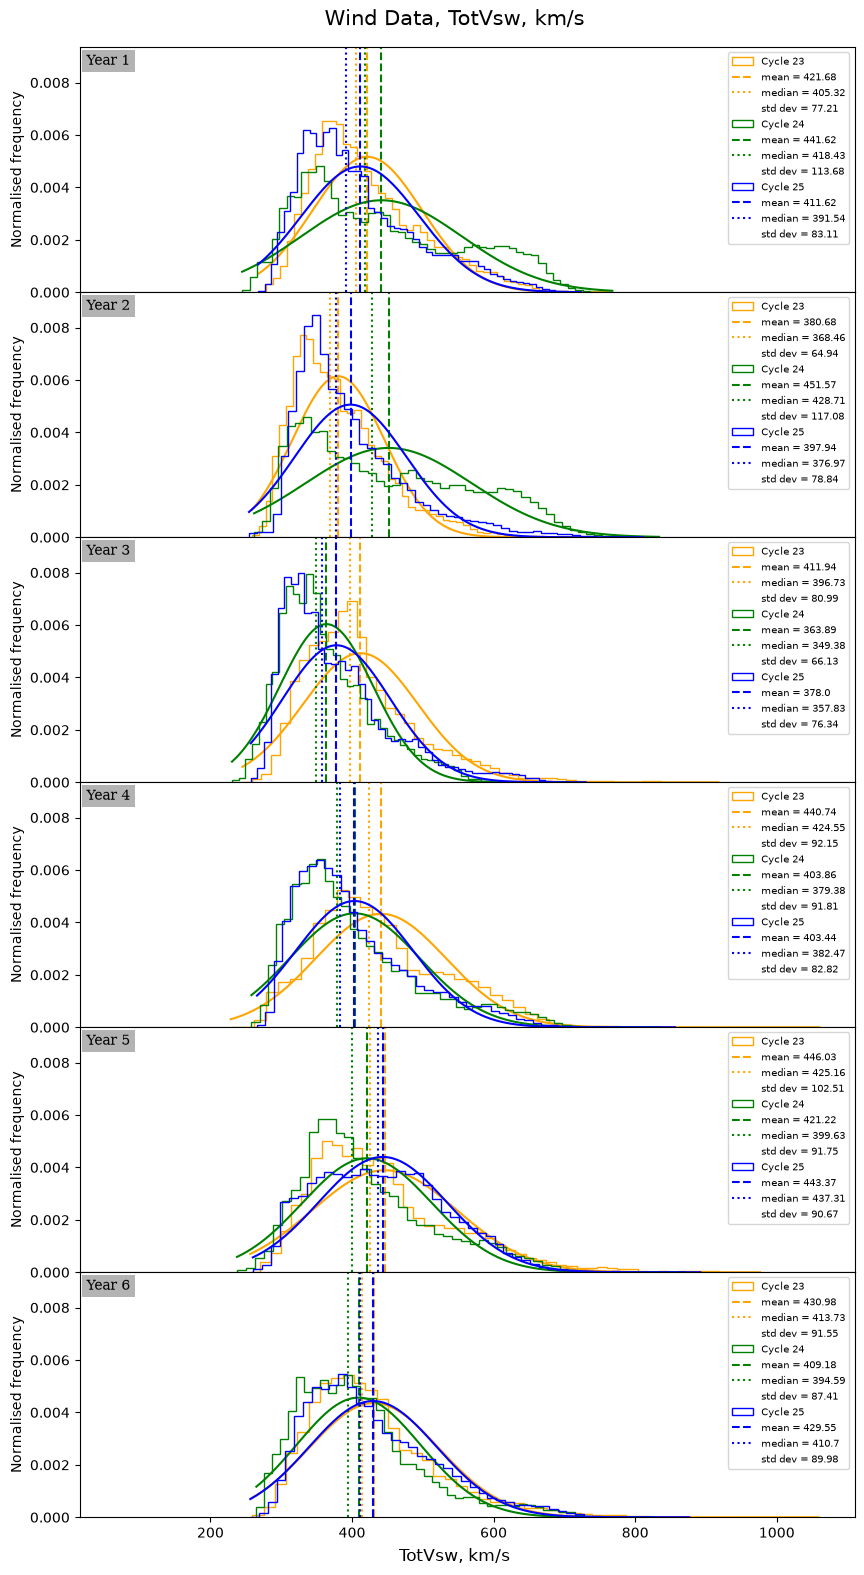

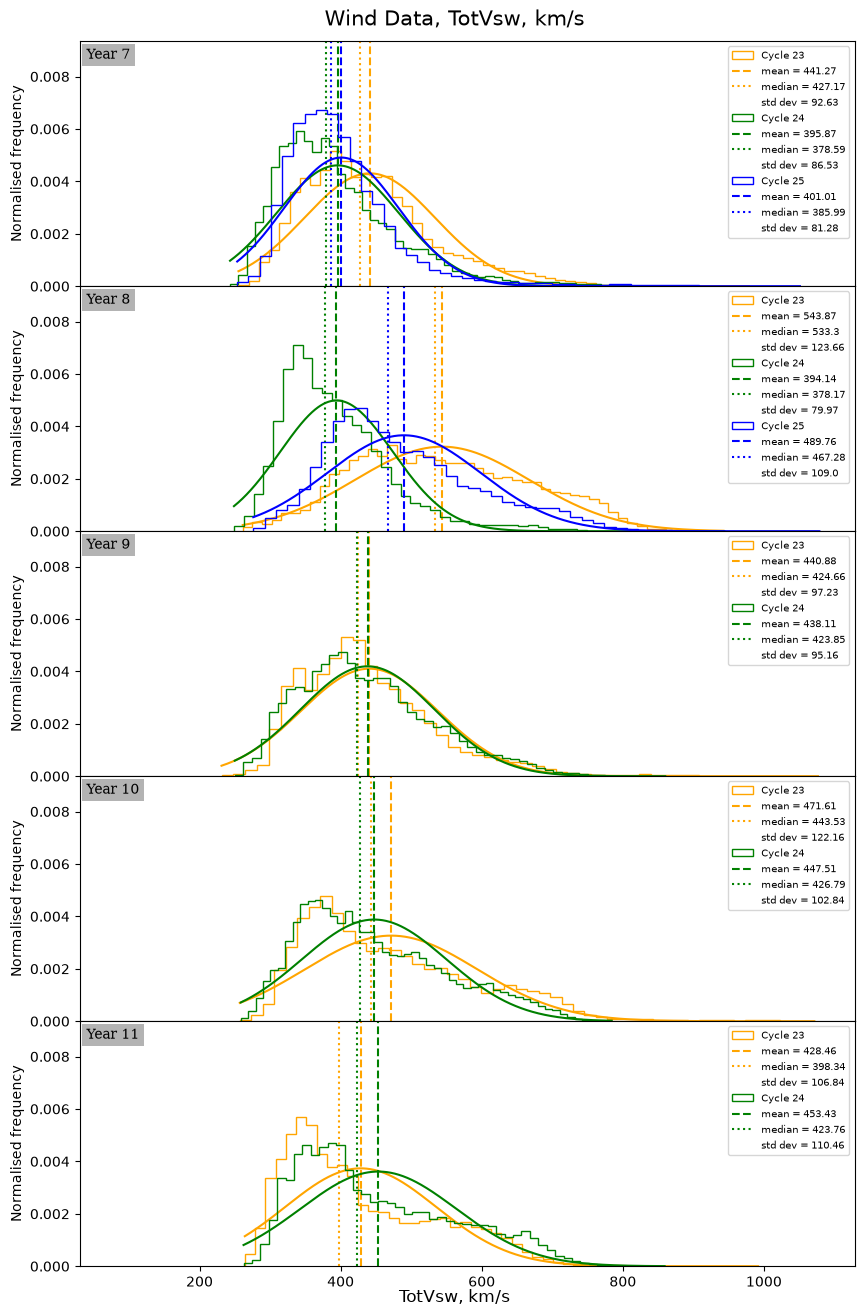

5.022550243749856
5.497109184845195
6.778503838611311
6.682471838770796
6.815984823275994
6.625368840620387


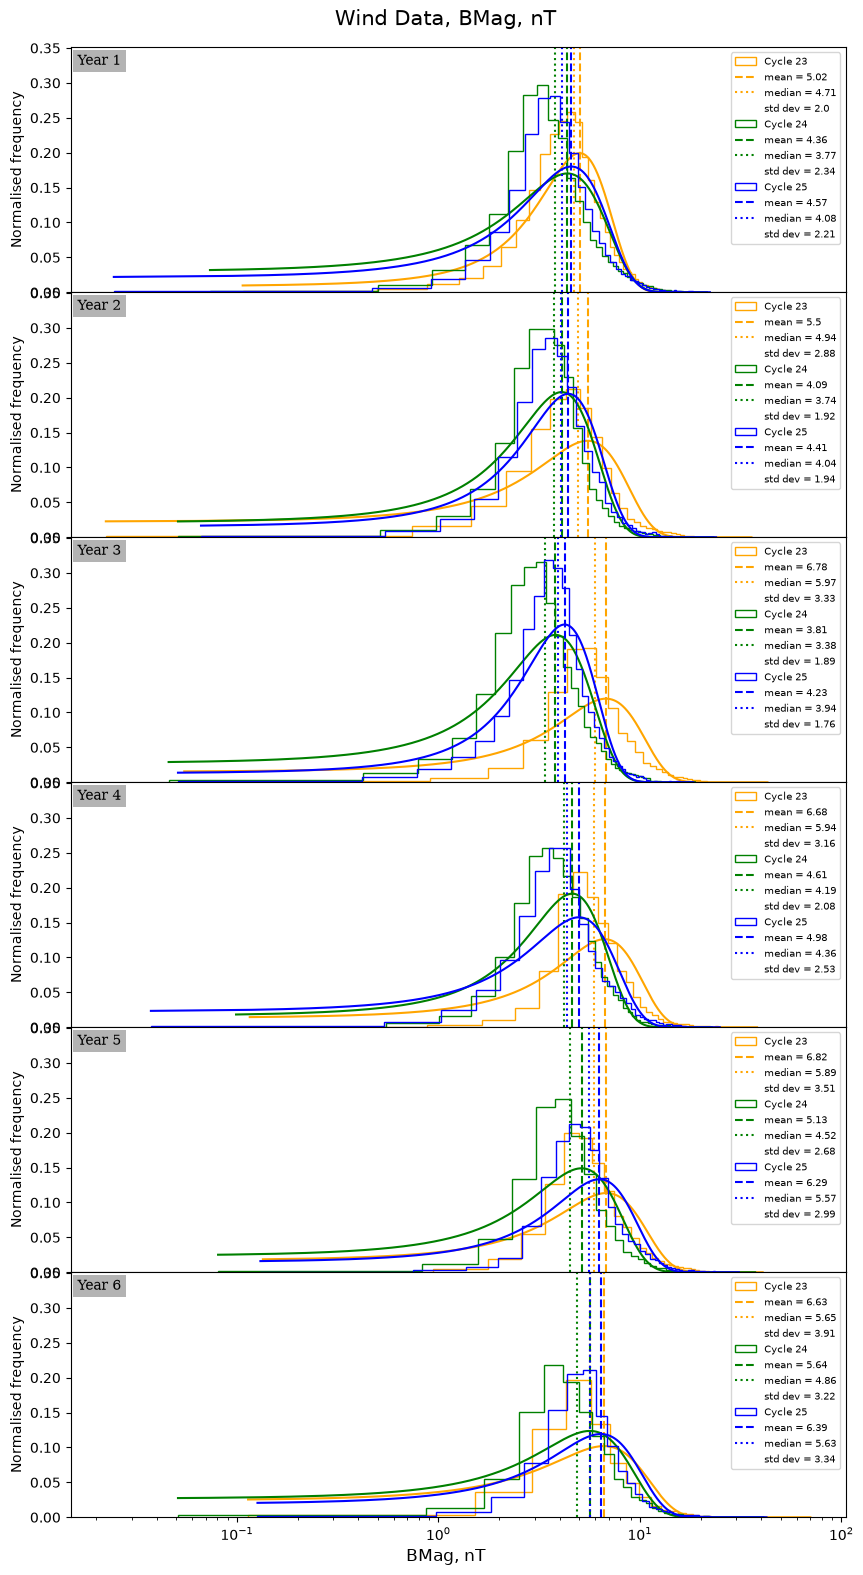

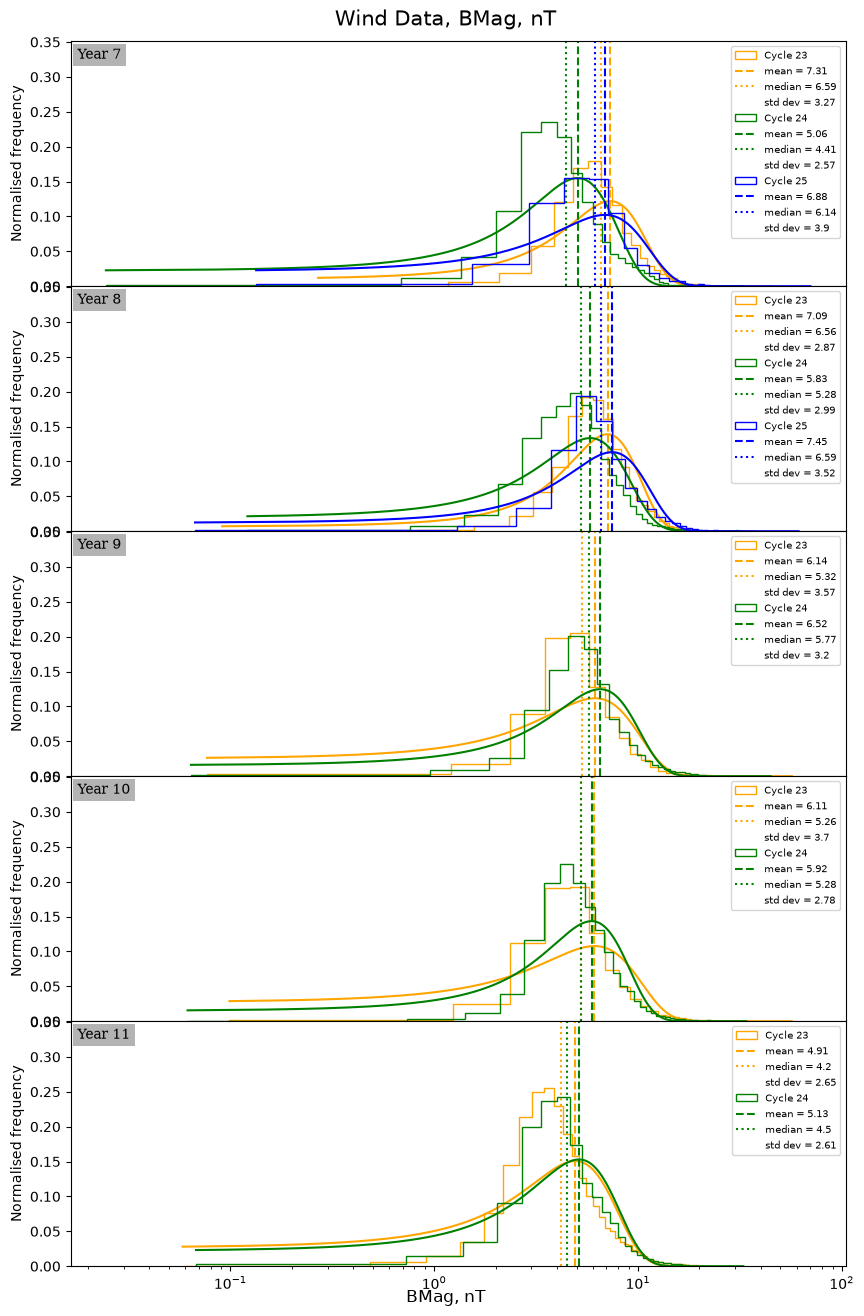

0.09907719449613343
-0.08461295898201547
0.10184051777387396
-0.39653507592977766
0.09673643999430553
-0.012816833073147717


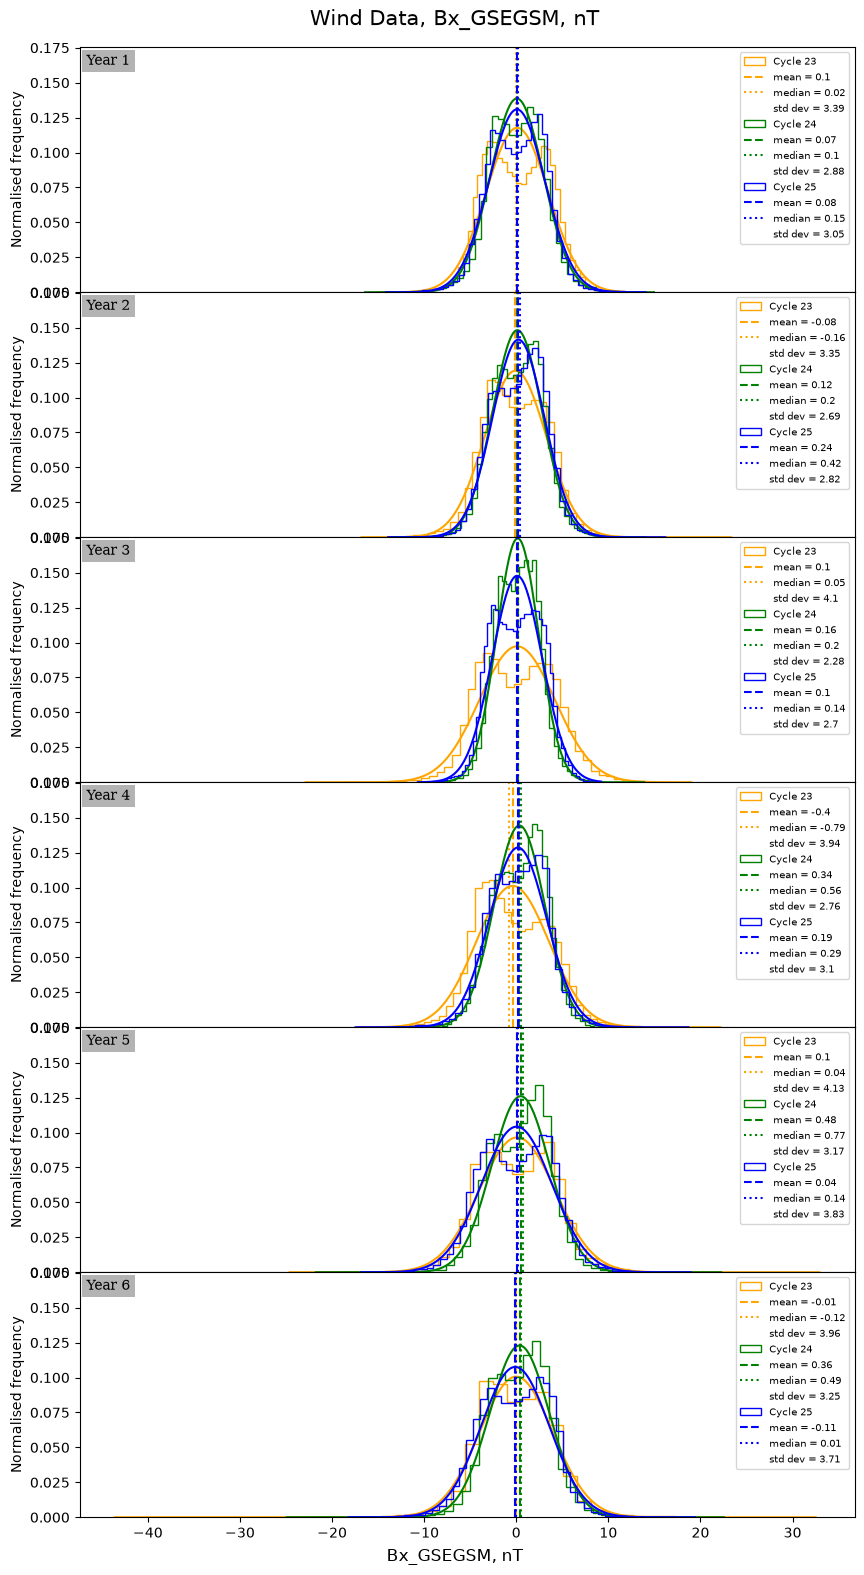

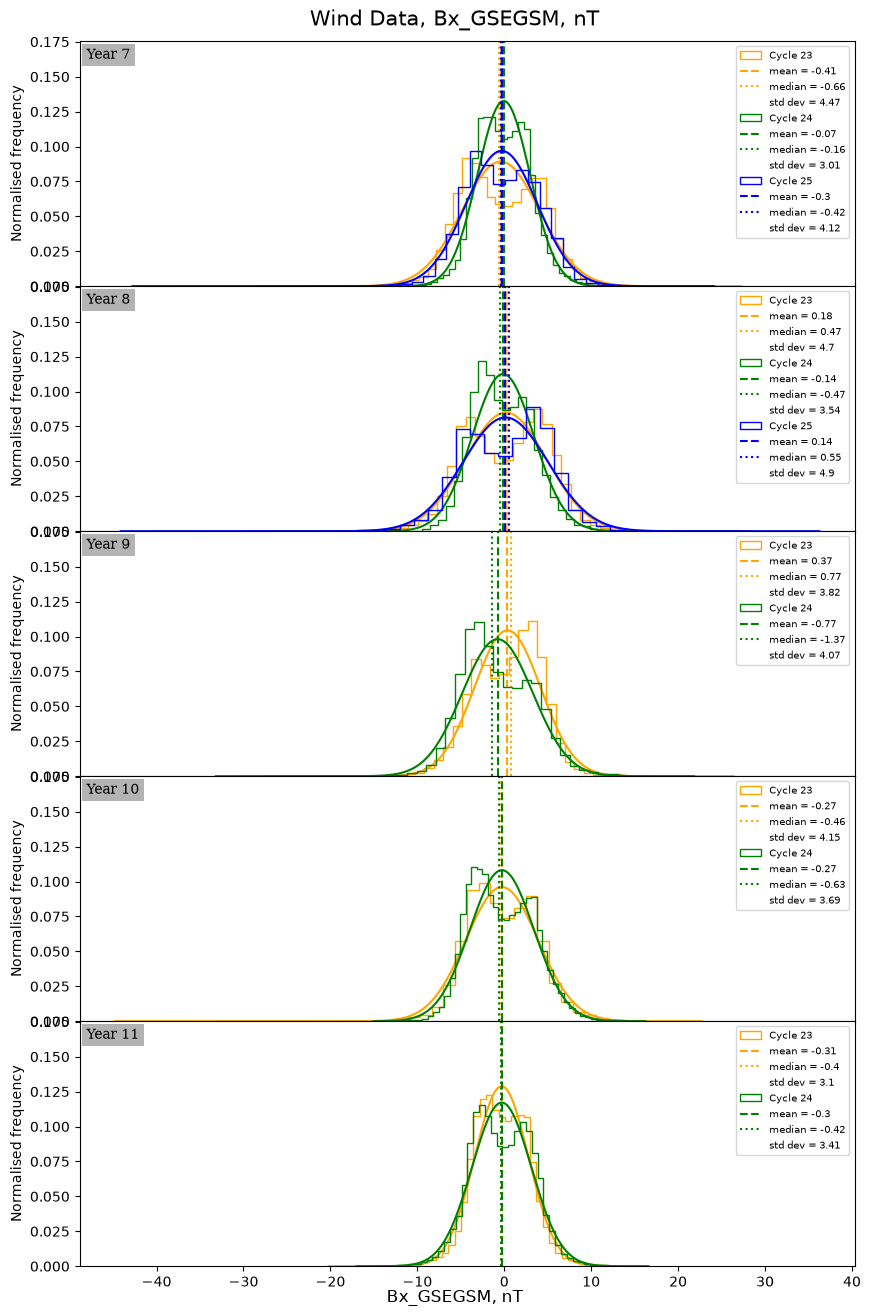

-0.08353413861488146
-0.15459596647957016
0.19598023285032248
0.5025131209792126
0.4245464316984105
0.359685914917132


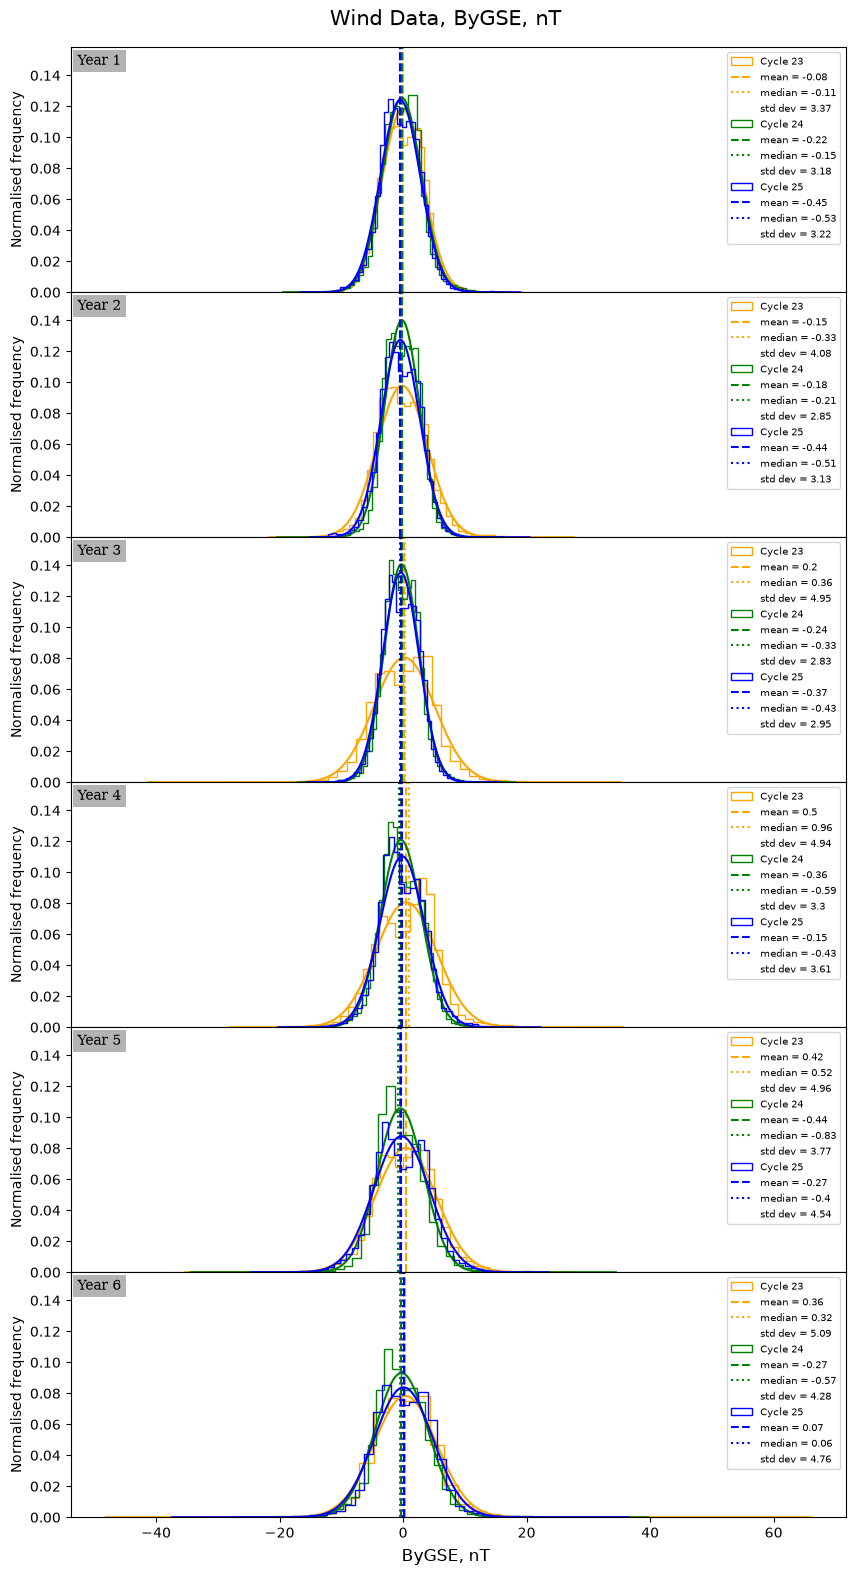

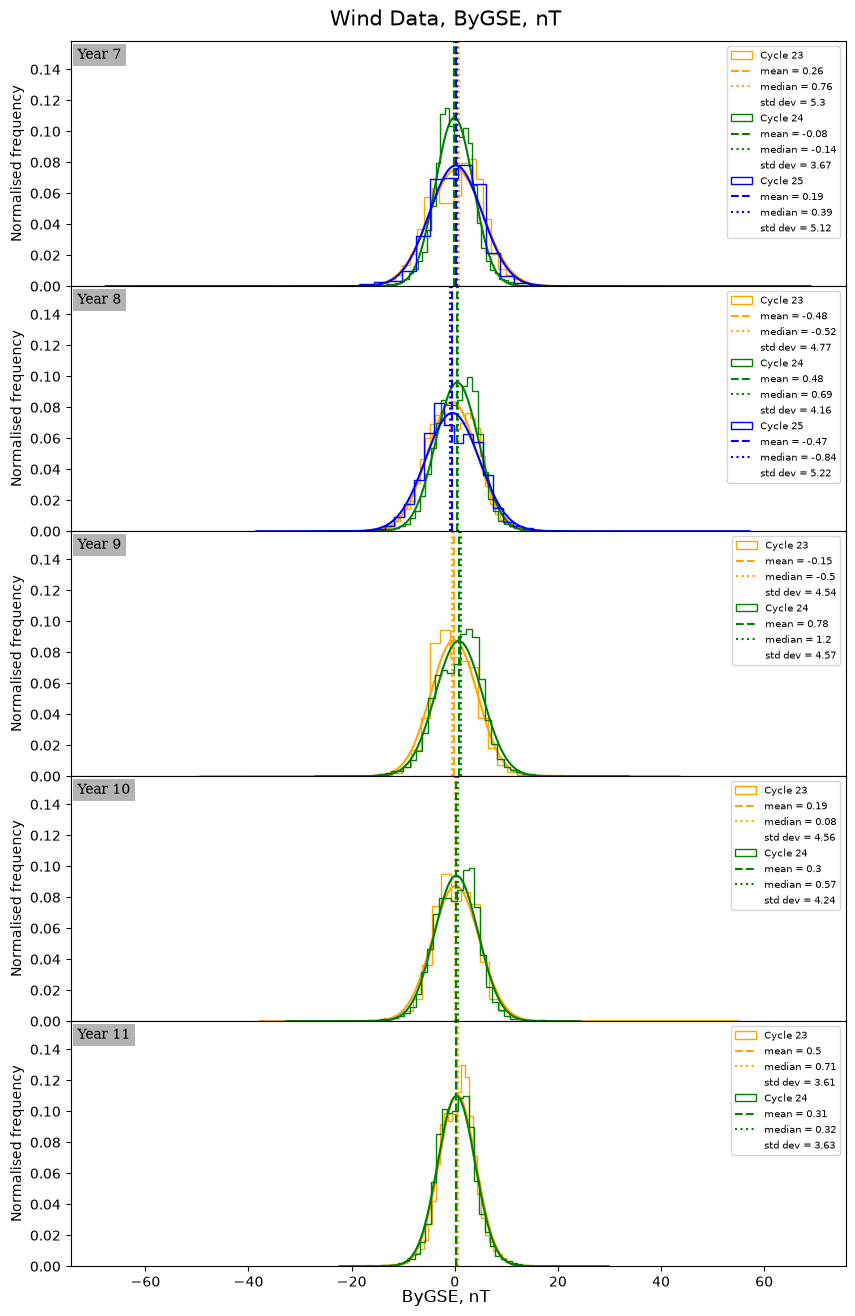

-0.06772686103312986
-0.1597668737248164
-0.024936429764940902
-0.10510530134190706
-0.01802914581687294
-0.020789887463779536


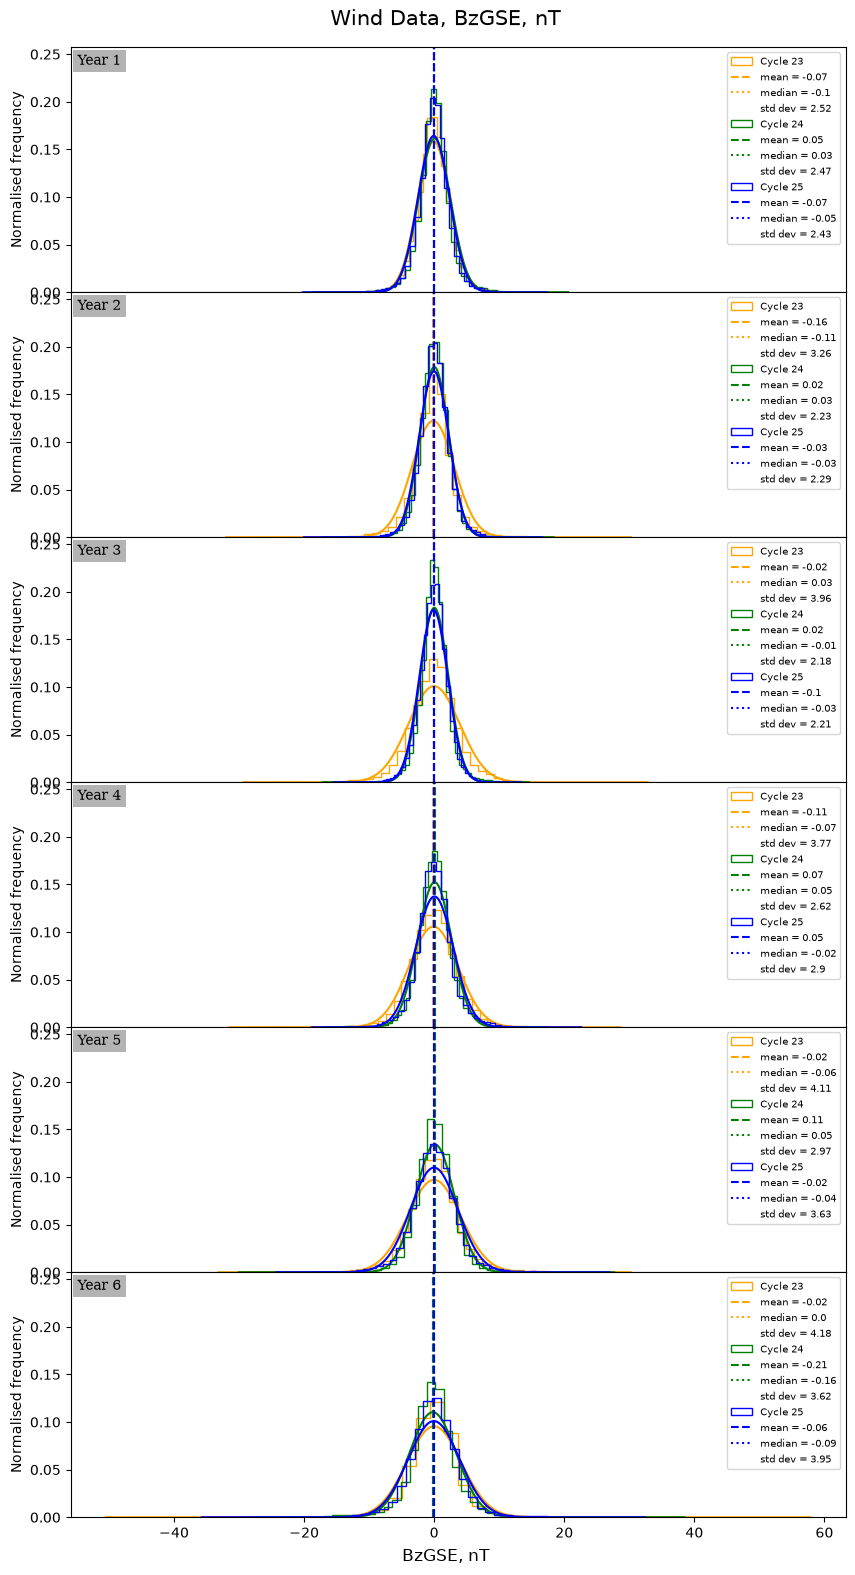

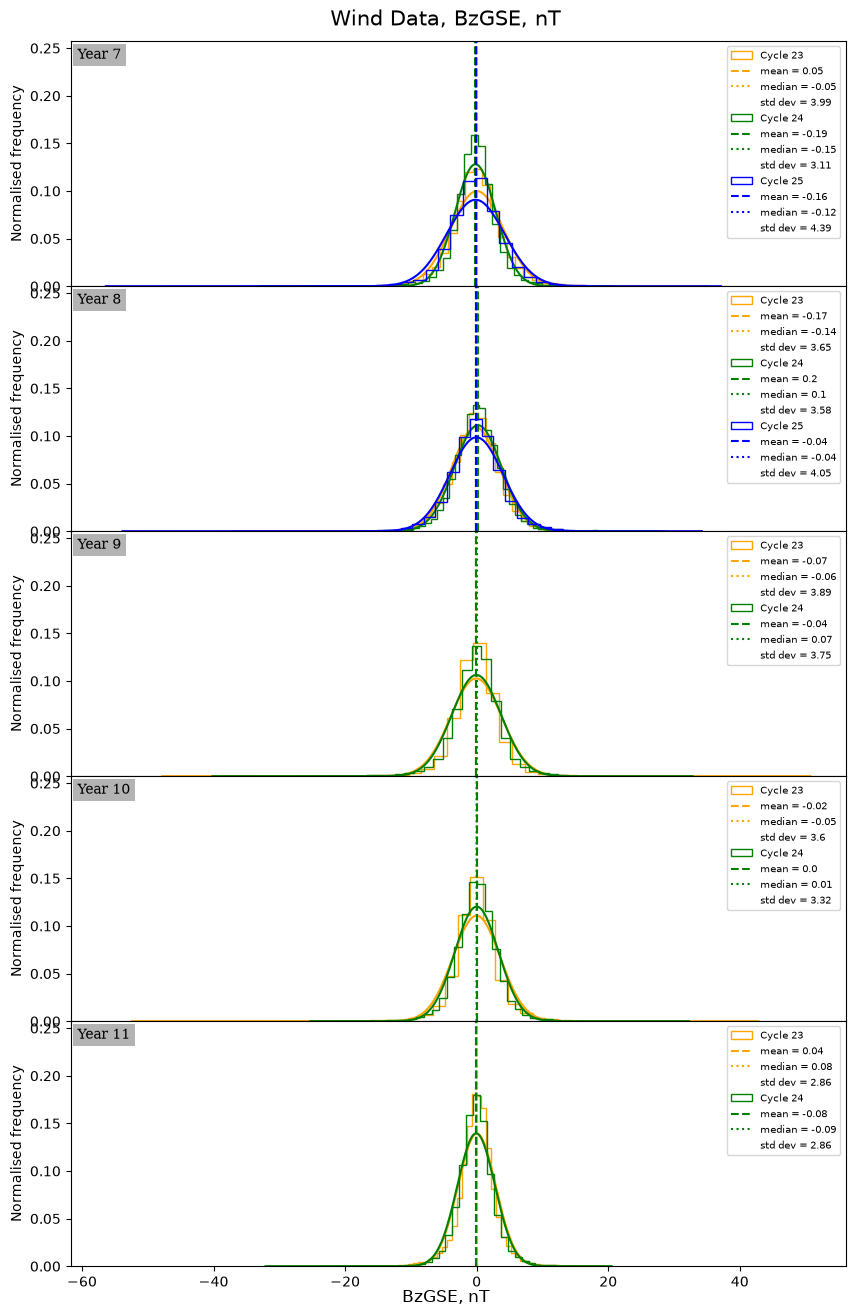

[[nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan]]


In [54]:
bins = [50, 50, 50, 50, 50]
# bins = [50, 50, 25, 25, 25]

Alpha = 1
SupTitle = 15
Legend = 7.5
figSize = (10, 35) # for 11 plots
# figSize6 = (10, 35 *(6/11)) # for 6 plots
# figSize5 = (10, 35 *(5/11)) # for 5 plots

LegLoc = 'upper right'
titleLoc = 0.9
SpaceLR = [100, 5, 5, 5, 5]
# Colours = ["red", "orange", "green", "blue"]
# Colours = ['pink','brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet','gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink']

    # "Bx_GSEGSM", "ByGSE", "BzGSE"
# dataTimeSerieses = [dataTSFirstDatesC23Min, dataTSFirstDatesC23Max, dataTSFirstDatesC24Min, dataTSFirstDatesC24Max]
Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
XAxisScale = ["linear", "log", "linear", "linear", "linear"]#, "nT"]
YAxisScale = ["linear", "linear", "linear", "linear", "linear"]#, "nT"]
# YAxisScale = ["linear", "log", "log", "log", "log"]
# YAxisScale = ["linear", "linear", "linear", "linear", "linear"]
# XAxisScale = ["linear", "log", "log", "log", "log"]#, "nT"]
# Plotting = ["TotVsw", "LogB", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
# Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
# StartAndEnd = [[startDateC23Min, endDateC23Min], [startDateC23Max, endDateC23Max], [startDateC24Min, endDateC24Min], [startDateC23Max, endDateC23Max]]
noOfYears = 11

# Cycle23 = dfToSeries(Cycle23)
# Cycle24 = dfToSeries(Cycle24)
# Cycle25 = dfToSeries(Cycle25)

yScaleLim, xScaleMaxLim, xScaleMinLim, MeansTS1, MeansTS2, MeansTS3, MediansTS1, MediansTS2, MediansTS3, StdDevsTS1, StdDevsTS2, StdDevsTS3, statsResult = YearOverlapGlobalYAxisWithFitting(Cycle23, Cycle24, Cycle25, Plotting, figSize, titleLoc, 0, 6, 6, 11, XAxisScale, bins, 1)
print(statsResult)
# YearOverlap(Cycle23[0:6], Cycle24[0:6], Cycle25[0:6], Plotting, 6, figSize6, titleLoc, 1) #, 0, 6)
# YearOverlap(Cycle23[6:11], Cycle24[6:11], Cycle25[6:8], Plotting, 5, figSize5, titleLoc, 7) #, 6, 11)

In [55]:
print(statsResult)

[[nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan]]


In [23]:
# dataTSC23Min.columns


## CDFs

In [24]:
# # CDF Formatting
# yLim = [-0.05,1.05]
# Legend = 7.5
# Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]
# # Plotting = ["FlowSpeed", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE"]
# Unit = ["km/s", "nT", "nT", "nT", "nT"] #, "nT"]

# # PlotCDF(dataTimeSerieses, Plotting)
# PlotCDF(dataTimeSerieses, Plotting)

## Plotting DQQ and finding q values

### Plotting

In [25]:
# Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]
# # Plotting = ["FlowSpeed", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE"]
# Lims = [[250, 910], [0, 40], [-15, 30], [-15, 30], [-15, 30]]
# Unit = ["km/s", "nT", "nT", "nT", "nT"] #, "nT"]

# # Plotting = ["TotVsw", "BMag", "BX_GSE"]#, "BY_GSM", "BZ_GSM"]
# # Lims = [[250, 910], [0, 40], [-15, 30]]#, [-15, 30], [-15, 30]]
# Breakpoints = [ [[ 0.9960, 0.9995], [ 0.8660, 0.9980]], [[ 0.9990, 0.9750], [ 0.9990, 0.9970]], [[ 0.9980, 0.1100], [ 0.9980, 0.1100]]]
# dataTimeSeriesToCompare = [ [dataTSC23Min, dataTSC23Max], [dataTSC24Min, dataTSC24Max]]
# PlotLabels = ["C23", "C24"]
# Color = ["red", "blue"]

# PlotDQQ(dataTimeSeriesToCompare, Plotting, Breakpoints)

# Separated Fast and Slow Wind

In [26]:
# # print(dataTimeSeriesToCompare)

# #Plot DQQ graphs with qs
# def PlotDQQSplittingFastAndSlow(dataTimeSeriesToCompare, VarsToPlot, QuantilesSpecific, SplitValue):
#     for i in range(len(VarsToPlot)): # do each parameter
#         fig, ax  = plt.subplots(1,2, figsize=(5, 5))
#         for j in range(len(dataTimeSeriesToCompare)): # do each comparison
#             dataTimeSeriesPS1 = pl.Series(dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]])
#             dataTimeSeriesPS2 = pl.Series(dataTimeSeriesToCompare[j][1]._data[VarsToPlot[i]])

#             print(dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]])

#             # s = pl.Series("a", [1, 2, 3])
#             MaskingBelow = []
#             MaskingAbove = []
#             for m in range(len(dataTimeSeriesPS1)):
#                 if dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]][m] < SplitValue:
#                     MaskingBelow.append(True)
#                     MaskingAbove.append(False)
#                 else:
#                     MaskingBelow.append(False)
#                     MaskingAbove.append(True)

#             maskBelow = pl.Series("", MaskingBelow)
#             maskAbove = pl.Series("", MaskingAbove)

#             dataTimeSeriesPS1Below = dataTimeSeriesPS1.filter(maskBelow)
#             dataTimeSeriesPS1Above = dataTimeSeriesPS1.filter(maskAbove)  

#             xQuantBelow, yQuantBelow = get_quantiles(dataTimeSeriesPS1Below, dataTimeSeriesPS2Below, size = 5000, p_range=(0.0001, 0.9999))
#             axs[0].scatter(xQuantBelow, yQuantBelow, color=Color[j], s=2, label = PlotLabels[j])
#             xQuantAbove, yQuantAbove = get_quantiles(dataTimeSeriesPS1Above, dataTimeSeriesPS2Above, size = 5000, p_range=(0.0001, 0.9999))
#             axs[1].scatter(xQuantAbove, yQuantAbove, color=Color[j], s=2, label = PlotLabels[j])

#             xOfKneeBelow, yOfKneeBelow, quantOfKneeBelow = FindQuantOfKnee(xQuantBelow, yQuantBelow)
#             xOfKneeAbove, yOfKneeAbove, quantOfKneeAbove = FindQuantOfKnee(xQuantAbove, yQuantAbove)

#             if np.isnan(quantOfKneeBelow):
#                 print("---------------------------")
#                 print("Error finding breakpoints q")
#                 print("---------------------------")
#             else:
#                 plt.plot(xOfKneeBelow, yOfKneeBelow, "o", color="black", label = "q = " + str(quantOfKneeBelow))
#                 # plt.plot(xOfKneeBelow, yOfKneeBelow, "o", color="black")

#             if np.isnan(quantOfKneeAbove):
#                 print("---------------------------")
#                 print("Error finding breakpoints q")
#                 print("---------------------------")
#             else:
#                 plt.plot(xOfKneeAbove, yOfKneeAbove, "o", color="black", label = "q = " + str(quantOfKneeAbove))
#                 # plt.plot(xOfKneeAbove, yOfKneeAbove, "o", color="black")


#             # xQuantBelow, yQuantBelow = get_quantiles(dataTimeSeriesPS1Below, dataTimeSeriesPS2Below, size = 5000, p_range=(0.0001, 0.9999))
#             # plt.scatter(xQuantBelow, yQuantBelow, color=Color[j], s=2, label = PlotLabels[j])
#             # xQuantAbove, yQuantAbove = get_quantiles(dataTimeSeriesPS1Above, dataTimeSeriesPS2Above, size = 5000, p_range=(0.0001, 0.9999))
#             # plt.scatter(xQuantAbove, yQuantAbove, color=Color[j], s=2, label = PlotLabels[j])
            
#             # xOfKneeBelow, yOfKneeBelow, quantOfKneeBelow = FindQuantOfKnee(xQuantBelow, yQuantBelow)
#             # xOfKneeAbove, yOfKneeAbove, quantOfKneeAbove = FindQuantOfKnee(xQuantAbove, yQuantAbove)
            
#             # if np.isnan(quantOfKnee):
#             #     print("---------------------------")
#             #     print("Error finding breakpoints q")
#             #     print("---------------------------")
#             # else:
#             #     plt.plot(xOfKnee, yOfKnee, "o", color="black", label = "q = " + str(quantOfKnee))
#             #     # plt.plot(xOfKnee, yOfKnee, "o", color="black")
        
#         x = np.linspace(-100, 900, 2)
#         y = x

#         for aa in ax:
#             aa.plot(x, y, color="grey")
#             aa.legend(loc="lower right", fontsize = Legend)
#             aa.xlabel(VarsToPlot[i] + r", $km/s$, solar min.")
#             aa.ylabel(VarsToPlot[i] + r", $km/s$, solar max.")
#             aa.set_xlim(Lims[i])
#             aa.set_ylim(Lims[i])
        
#         ax[0].savefig("DQQBelow_Wind.png")
#         ax[1].savefig("DQQAbove_Wind.png")

#         plt.show()

#         # C23
#         # data_sortedPLSeriesXC23 = pl.Series(dataTimeSerieses[j]._data[VarsToPlot[i]]) # make data into a polar series
#         # data_sortedPLSeriesYC23 = pl.Series(dataTimeSerieses[j]._data[VarsToPlot[i]])

# PlotDQQSplittingFastAndSlow(dataTimeSeriesToCompare, Plotting, Breakpoints, 450)

# Archived code

In [27]:
# def PlotVswFiltered(dataTimeSeries, filter):
#     Filtered = dataTimeSeries._data[dataTimeSeries._data['TotVsw'] < filter]
#     FilteredTS = dfToSeries(Filtered)
#     # print(FilteredTS)
#     fig, ax = plt.subplots()
#     FilteredTS.plot(columns=["TotVsw", "FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE"], alpha = 0.5)
#     plt.legend(loc="upper right")
#     # plt.ylim(-450,900)

# PlotVswFiltered(dataTSC23Min, 10000)
# PlotVswFiltered(dataTSC23Max, 10000)
# PlotVswFiltered(dataTSC24Min, 10000)
# PlotVswFiltered(dataTSC24Max, 10000)

In [28]:
# def PlotVswRemoveFiller(dataTimeSeries):
#     cols = ["FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE"]
#     fig, ax = plt.subplots()
#     for i in range(len(cols)):
#         Filtered = dataTimeSeries._data[dataTimeSeries._data[cols[i]] != 99999.9]
#         FilteredTS = dfToSeries(Filtered)
#         # print(FilteredTS)
#         FilteredTS.plot(columns=[cols[i]], alpha = 0.5)

#     plt.legend(loc="upper right")
#     plt.title(dataTimeSeries.time_range)
#     # plt.ylim(-450,900)

# def PlotBRemoveFiller(dataTimeSeries):
#     cols = ["ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE"]
#     fig, ax = plt.subplots()
#     for i in range(len(cols)):
#         Filtered = dataTimeSeries._data[dataTimeSeries._data[cols[i]] != 9999.99]
#         FilteredTS = dfToSeries(Filtered)
#         # print(FilteredTS)
#         FilteredTS.plot(columns=[cols[i]], alpha = 0.5)

#     plt.legend(loc="upper right")
#     plt.title(dataTimeSeries.time_range)
#     # plt.ylim(-40,90)

# # Plot histograms all together
# def PlotHistTogetherRemoveFiller(dataTimeSerieses, VarsToPlot, Fillers):
#     for i in range(len(VarsToPlot)):
#         for j in range(len(dataTimeSerieses)):
#             Filtered = dataTimeSerieses[j]._data[dataTimeSerieses[j]._data[VarsToPlot[i]] != Fillers[i]]
#             FilteredTS = dfToSeries(Filtered)
#             plt.hist(FilteredTS._data[VarsToPlot[i]], bins = Bin, label = "Wind " + str(StartAndEnd[j][0] + " - " + str(StartAndEnd[j][1])), alpha = Alpha, density = True)
#         plt.title("Solar Wind " + VarsToPlot[i])
#         plt.xlabel(VarsToPlot[i] + r", GSE, $km/s$")
#         plt.legend(fontsize=Legend)
#         plt.show()

# #Plot histograms separately
# def PlotHistSeparateRemoveFillers(dataTimeSerieses, VarsToPlot, Fillers):
#     for i in range(len(VarsToPlot)): # For each variable
#         LowerBounds = [] # set lower bounds array to 0
#         UpperBounds = [] # set upper bounds array to 0
#         fig, axs = plt.subplots(4,1, figsize=FigSize, sharex=True)
#         fig.subplots_adjust(hspace=0)
#         for j in range(len(dataTimeSerieses)): # For each daterange
#             Filtered = dataTimeSerieses[j]._data[dataTimeSerieses[j]._data[VarsToPlot[i]] != Fillers[i]]
#             FilteredTS = dfToSeries(Filtered)
#             axs[j].hist(FilteredTS._data[VarsToPlot[i]], bins = Bin, label = "Wind " + str(StartAndEnd[j][0]) + " - " + str(StartAndEnd[j][1]), color=Colours[j], alpha = Alpha, density = True)
#             #Mean
#             axs[j].axvline(FilteredTS._data[VarsToPlot[i]].mean(), linestyle = '--', color = "grey", label="mean = " + str(FilteredTS._data[VarsToPlot[i]].mean()))
#             #Median
#             axs[j].axvline(FilteredTS._data[VarsToPlot[i]].median(), linestyle = '--', color = "black", label="median = " + str(FilteredTS._data[VarsToPlot[i]].median()))
#             #Standard deviation
#             axs[j].axvline(FilteredTS._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(FilteredTS._data[VarsToPlot[i]].std()), alpha = 0)

#             axs[j].legend(loc = LegLoc, fontsize = Legend)
#                 # axs[1].legend(loc = LegLoc, fontsize = Legend)
#                 # axs[2].legend(loc = LegLoc, fontsize = Legend)
#                 # axs[3].legend(loc = LegLoc, fontsize = Legend)
            
#             LowerBounds.append(min(FilteredTS._data[VarsToPlot[i]].values))
#             UpperBounds.append(max(FilteredTS._data[VarsToPlot[i]].values))
#             # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
        
#         plt.suptitle("Solar Wind "+ VarsToPlot[i] + ", ", fontsize = SupTitle)
#         fig.supxlabel(VarsToPlot[i] + ", " + str(Units[i]))

#         plt.xlim(min(LowerBounds) - SpaceLR[i], max(UpperBounds) + SpaceLR[i])
#         plt.savefig("Plots/Wind/" + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + "_Wind.png")
#         # plt.show()

# Plot CDF
# def PlotCDFRemoveFillers(dataTimeSerieses, VarsToPlot, Fillers):
#     # fig, axs = plt.subplots()#4,1, figsize=FigSize, sharex=True)
#     # fig.subplots_adjust(hspace=0)
#     for i in range(len(VarsToPlot)):
#         for j in range(len(dataTimeSerieses)):
#             Filtered = dataTimeSerieses[j]._data[dataTimeSerieses[j]._data[VarsToPlot[i]] != Fillers[i]]
#             FilteredTS = dfToSeries(Filtered)
#             sns.ecdfplot(FilteredTS._data[VarsToPlot[i]], label="Wind " + str(StartAndEnd[j][0]) + " - " + str(StartAndEnd[j][1]), color=Colours[j])
#         plt.xlabel(VarsToPlot[i] + ", " + Units[i])
#         plt.ylabel('Cumulative probability')
#         plt.ylim(yLim)
#         plt.legend(fontsize=Legend)
#         plt.grid(True)
#         plt.savefig("Plots/Wind/" + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + "_CDF_Wind.png") #  + dataTimeSerieses[0] + " - " + dataTimeSerieses[-1] 
#         plt.show()

# def PlotDQQRemoveFillers(dataTimeSeriesToCompare, VarsToPlot, QuantilesSpecific, Fillers):
#     for i in range(len(VarsToPlot)): # do each parameter
#         fig, ax  = plt.subplots(figsize=(5, 5))
#         for j in range(len(dataTimeSeriesToCompare)): # do each comparison
#             Filtered1 = dataTimeSeriesToCompare[j][0]._data[dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]] != Fillers[i]]
#             FilteredTS1 = dfToSeries(Filtered1)
#             Filtered2 = dataTimeSeriesToCompare[j][1]._data[dataTimeSeriesToCompare[j][1]._data[VarsToPlot[i]] != Fillers[i]]
#             FilteredTS2 = dfToSeries(Filtered2)
#             dataTimeSeriesPS1 = pl.Series(FilteredTS1._data[VarsToPlot[i]])
#             dataTimeSeriesPS2 = pl.Series(FilteredTS2._data[VarsToPlot[i]])
#             xQuant, yQuant = get_quantiles(dataTimeSeriesPS1, dataTimeSeriesPS2, size = 5000, p_range=(0.0001, 0.9999))
#             plt.scatter(xQuant, yQuant, color=Color[j], s=2, label = PlotLabels[j])

#             xOfKnee, yOfKnee, quantOfKnee = FindQuantOfKnee(xQuant, yQuant)

#             if np.isnan(quantOfKnee):
#                 print("---------------------------")
#                 print("Error finding breakpoints q")
#                 print("---------------------------")
#             else:
#                 plt.plot(xOfKnee, yOfKnee, "o", color="black", label = "q = " + str(quantOfKnee))
#             # plt.plot(xOfKnee, yOfKnee, "o", color="black")
        
#         x = np.linspace(-100, 900, 2)
#         y = x
#         plt.plot(x, y, color="grey")
#         plt.title("T&C 2017 Fig 4aiii)")
#         plt.legend(loc="lower right", fontsize = Legend)
#         plt.xlabel(VarsToPlot[i] + r", $km/s$, solar min.")
#         plt.ylabel(VarsToPlot[i] + r", $km/s$, solar max.")
#         plt.xlim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2) , max(xQuantC23)+np.absolute(max(xQuantC23)/2))
#         plt.ylim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2), max(xQuantC23)+np.absolute(max(xQuantC23)/2))
#         plt.savefig("/Plots/Wind/DQQ_Wind" + VarsToPlot[i] + ".png")

#         plt.show()

# def PlotBFiltered(dataTimeSeries, filter):
#     Filtered = dataTimeSeries._data[dataTimeSeries._data['BMag'] < filter]
#     FilteredTS = dfToSeries(Filtered)
#     # print(FilteredTS)
#     fig, ax = plt.subplots()
#     FilteredTS.plot(columns=["BMag", "ScalarB"], alpha = 0.5) #, "Bx_GSEGSM", "ByGSE", "BzGSE"], alpha = 0.5)
#     plt.legend(loc="upper right")
#     # plt.ylim(-450,900)

# PlotBFiltered(dataTSC23Min, 1000)
# PlotBFiltered(dataTSC23Max, 1000)
# PlotBFiltered(dataTSC24Min, 1000)
# PlotBFiltered(dataTSC24Max, 1000)

# Testing BMag vs ScalarB